In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo
import pickle
from constants import FEATURES


# use tex
plt.rcParams["text.usetex"] = True
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

import pandas as pd
from signal_region import get_SR_CR_cut, compute_sr_stats
from correct_systematic_error import get_histograms, get_quantiles_with_weights

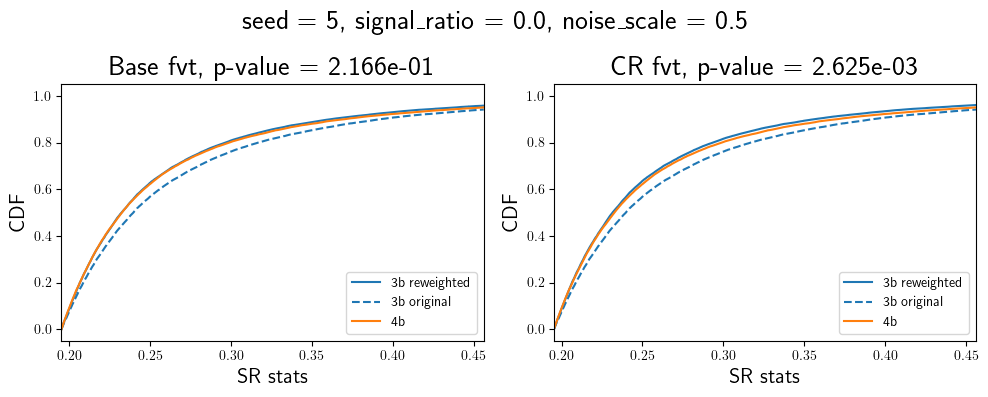

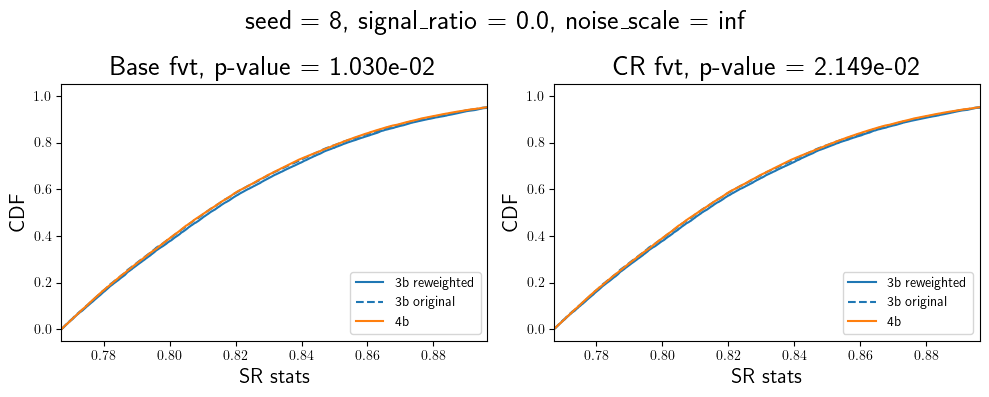

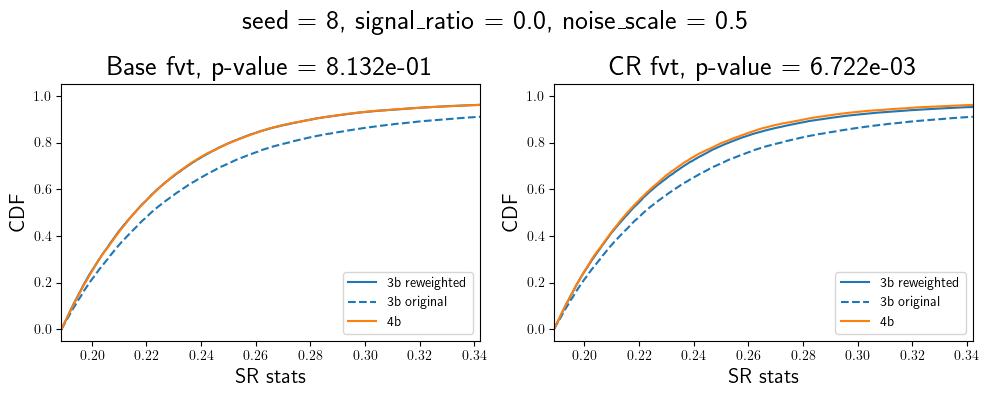

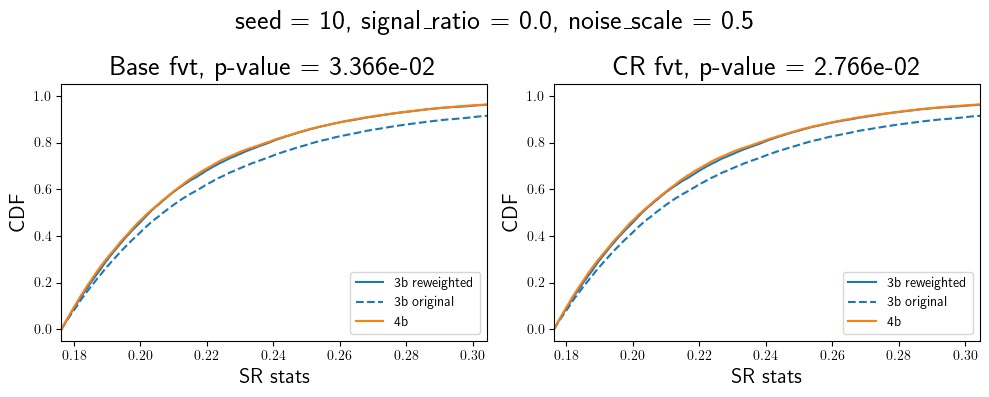

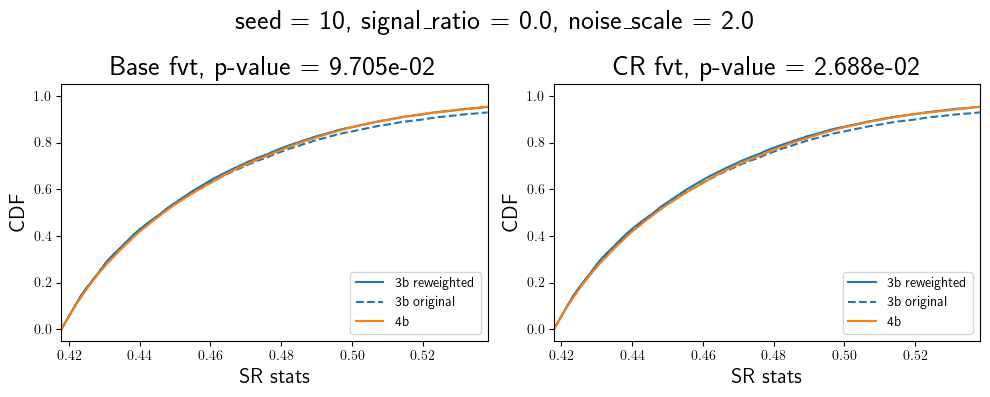

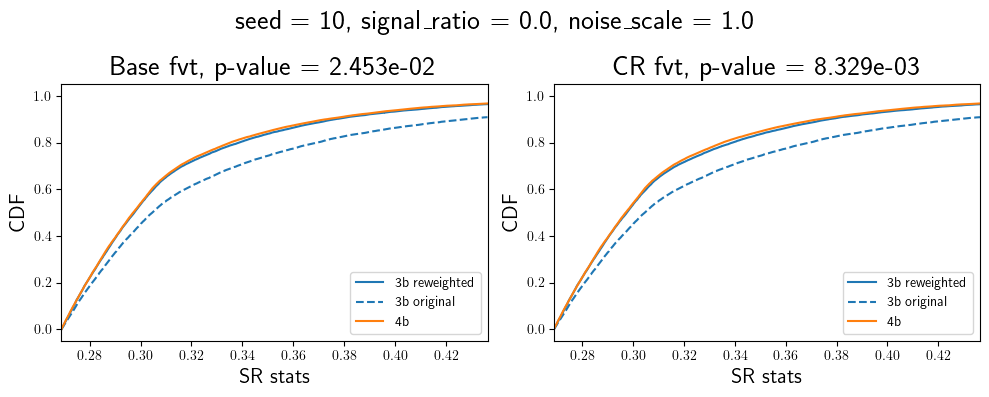

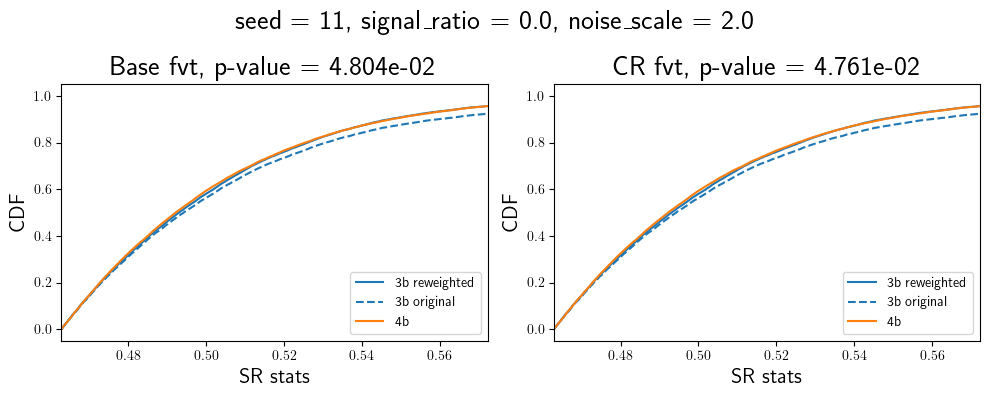

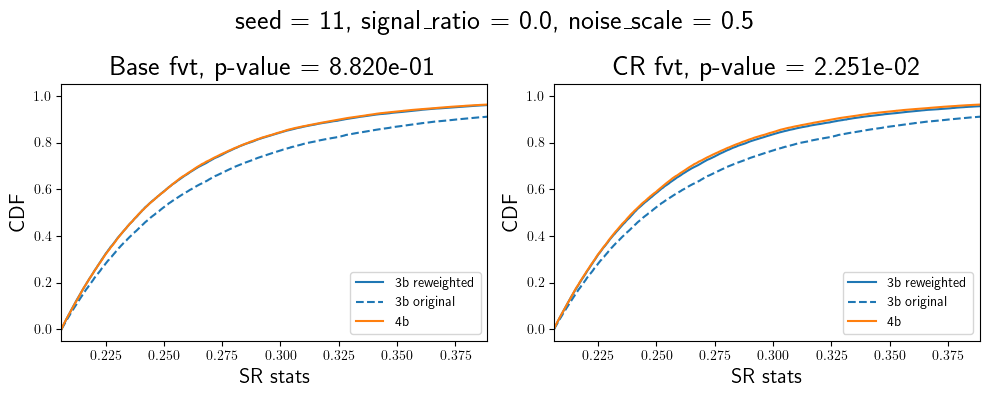

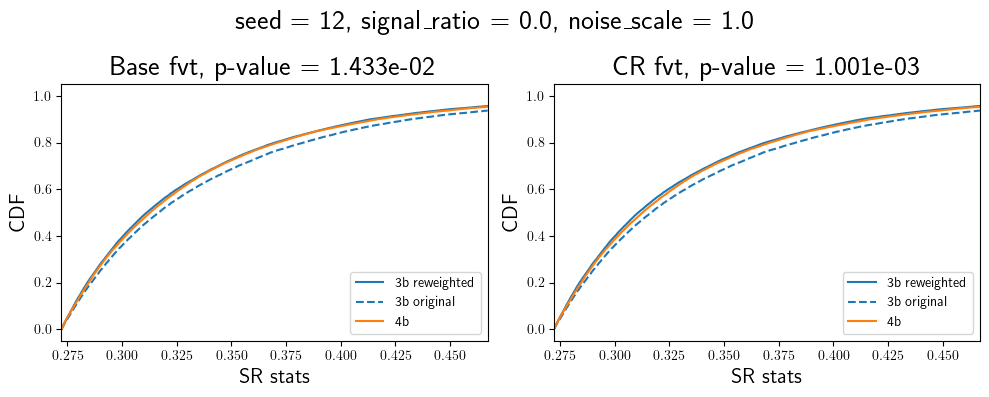

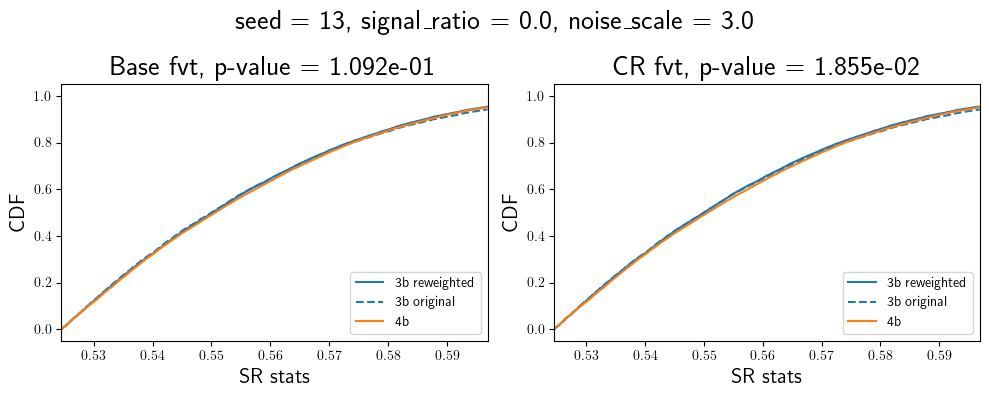

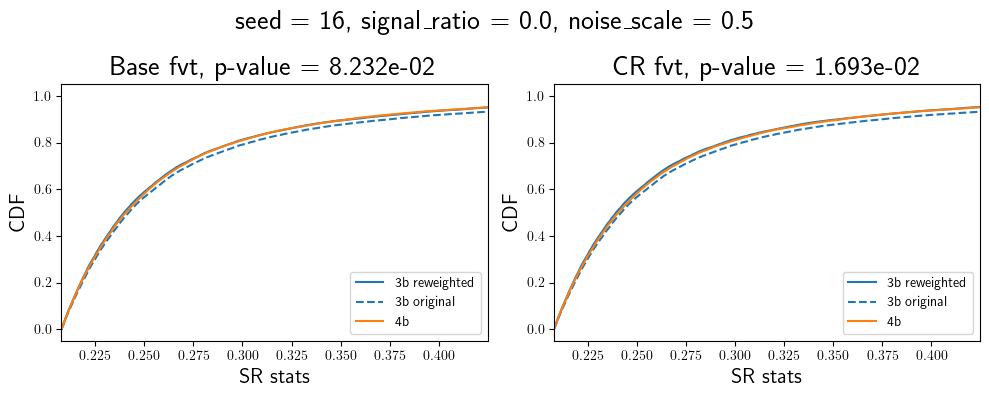

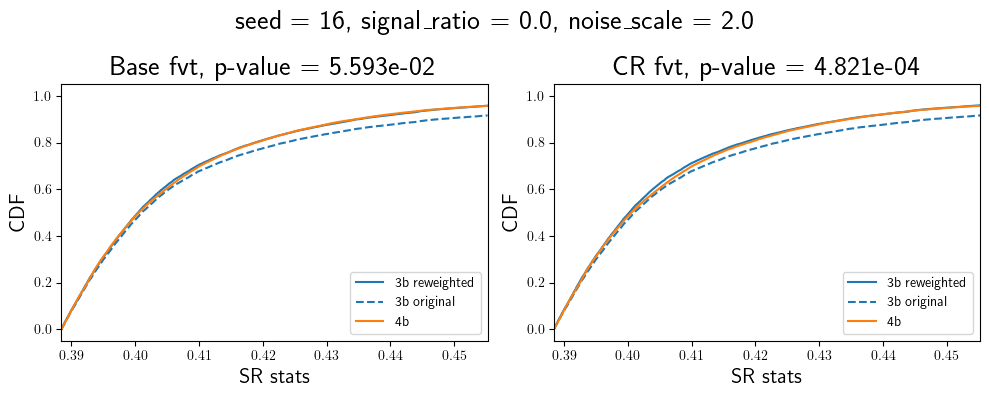

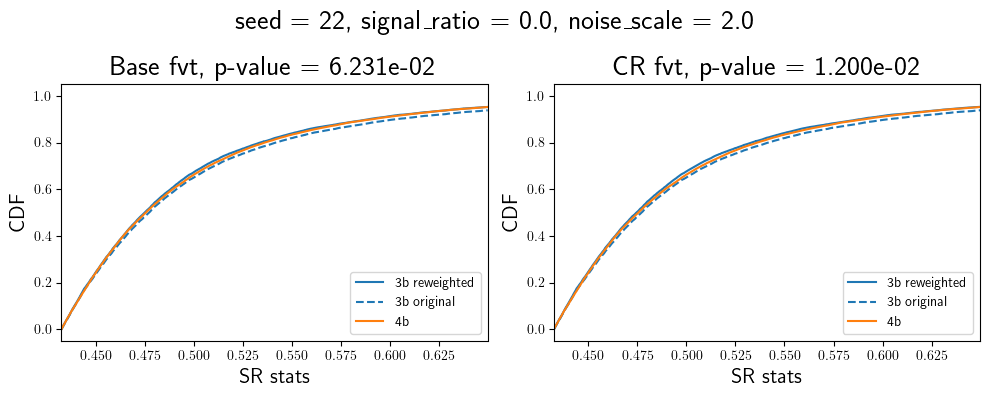

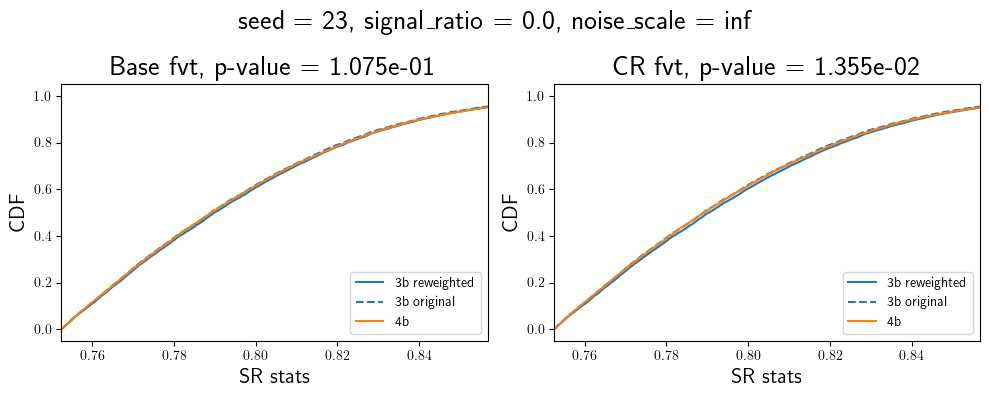

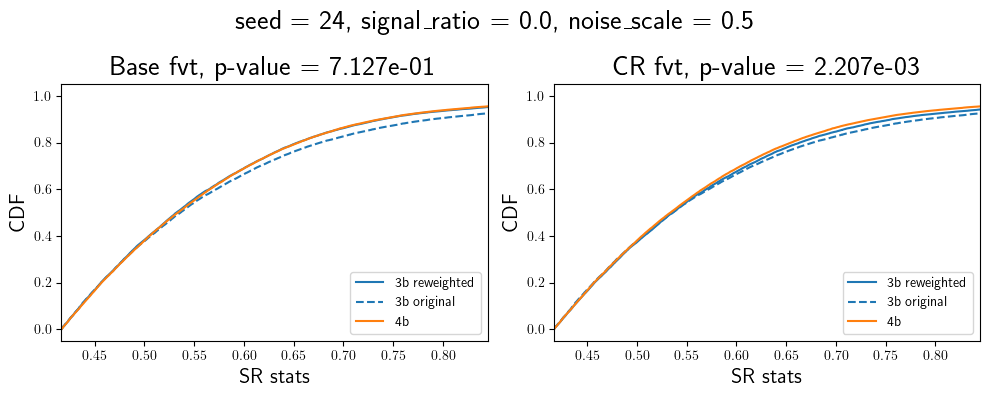

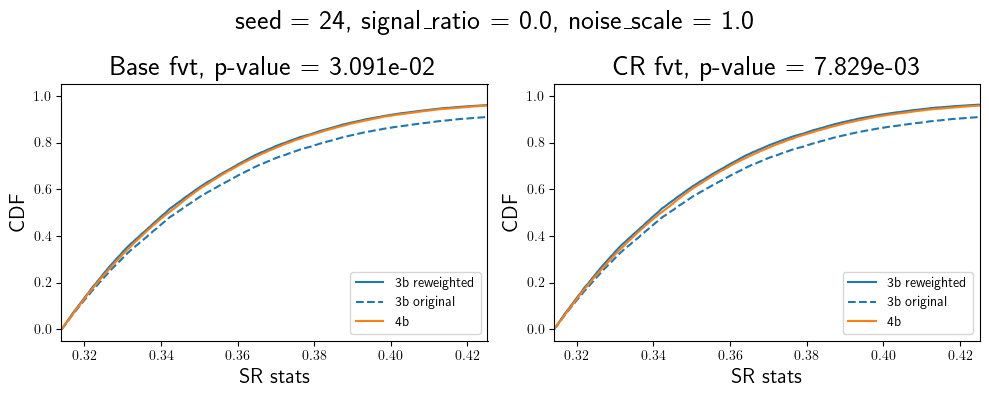

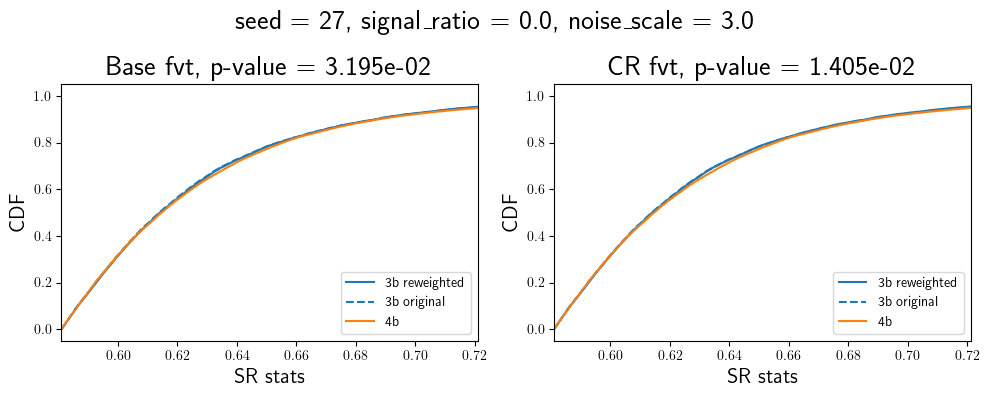

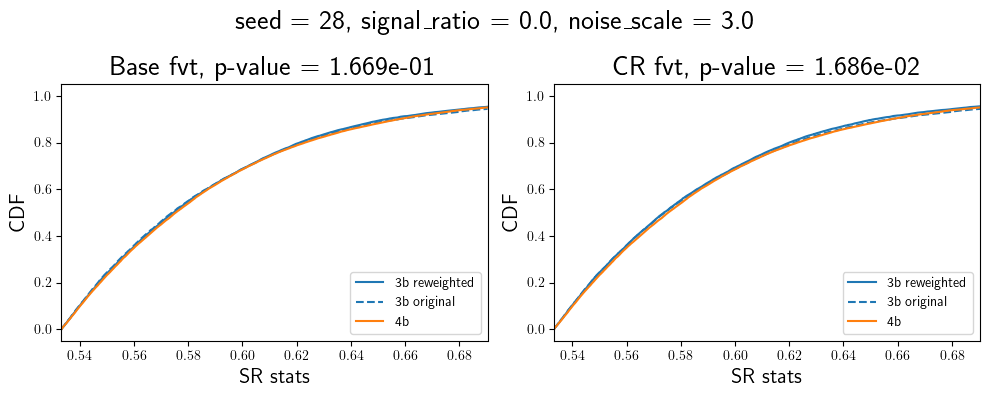

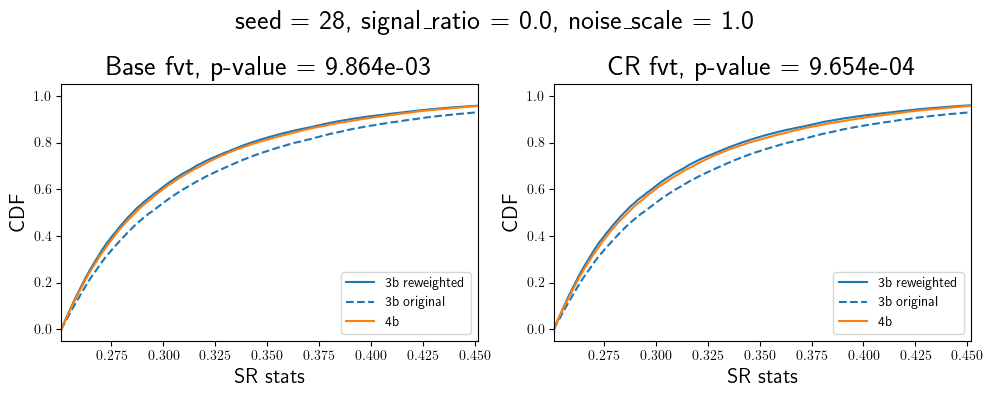

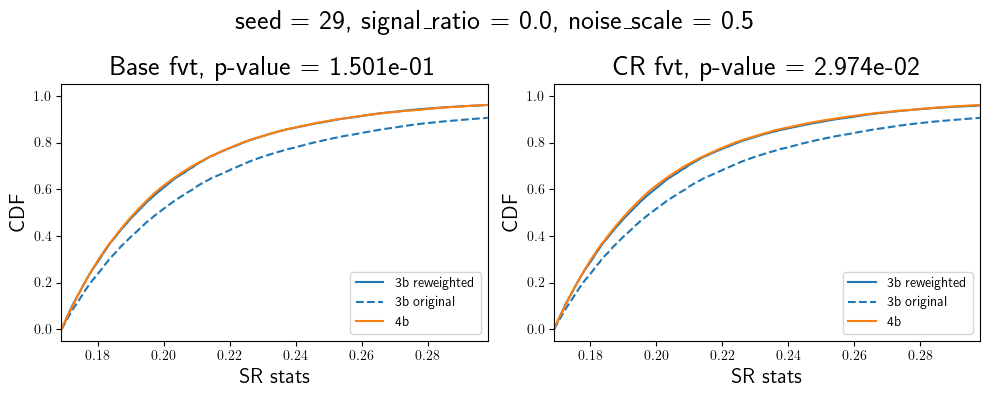

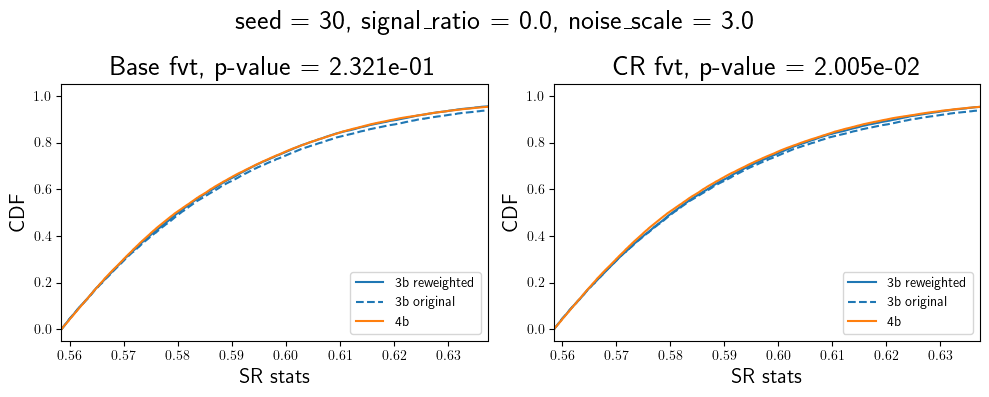

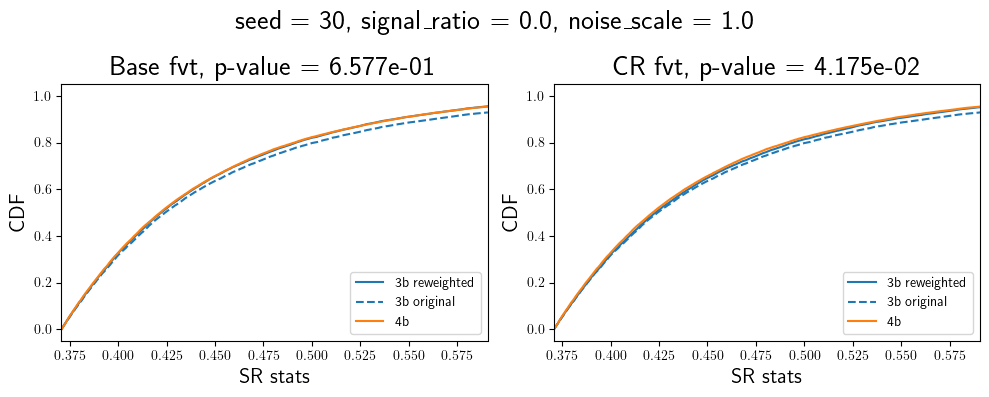

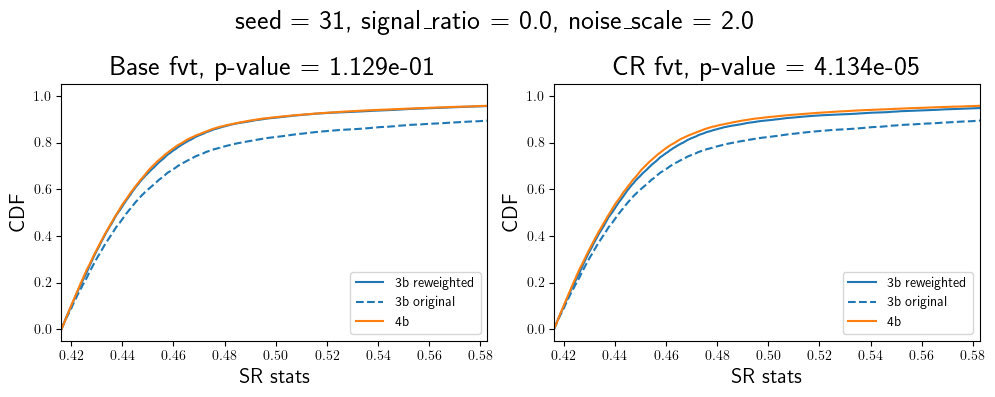

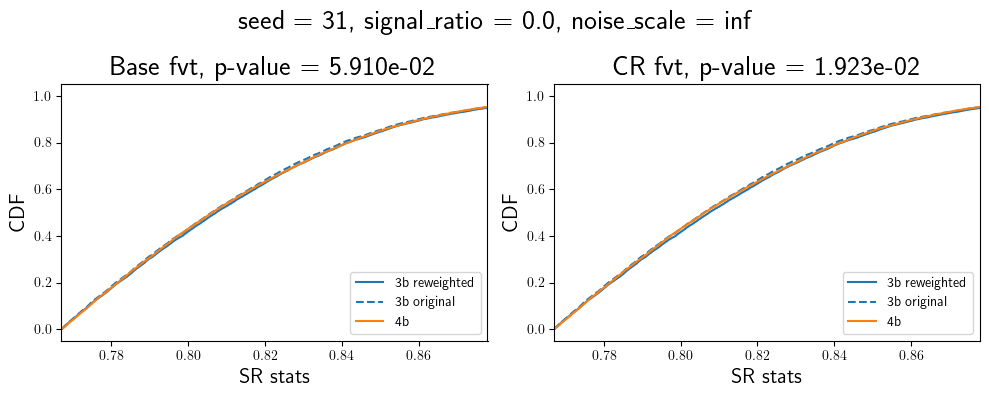

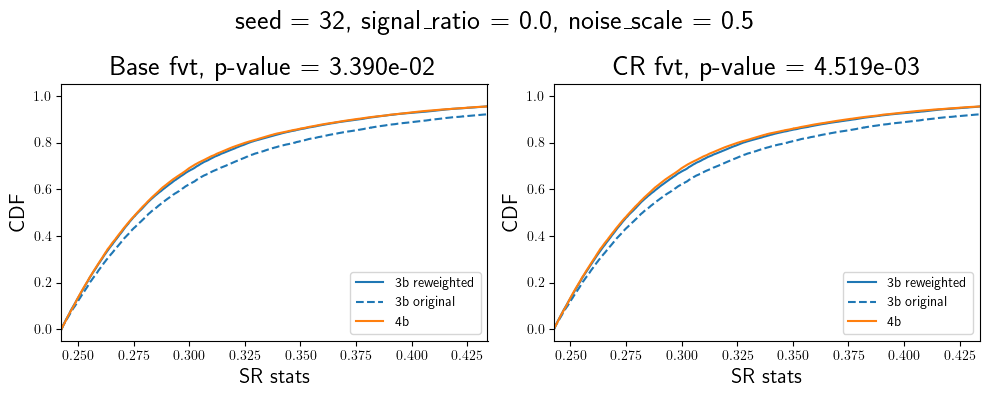

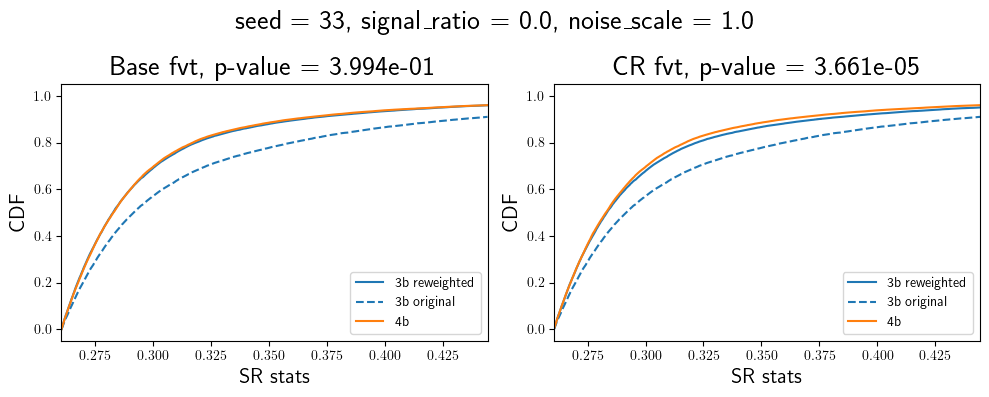

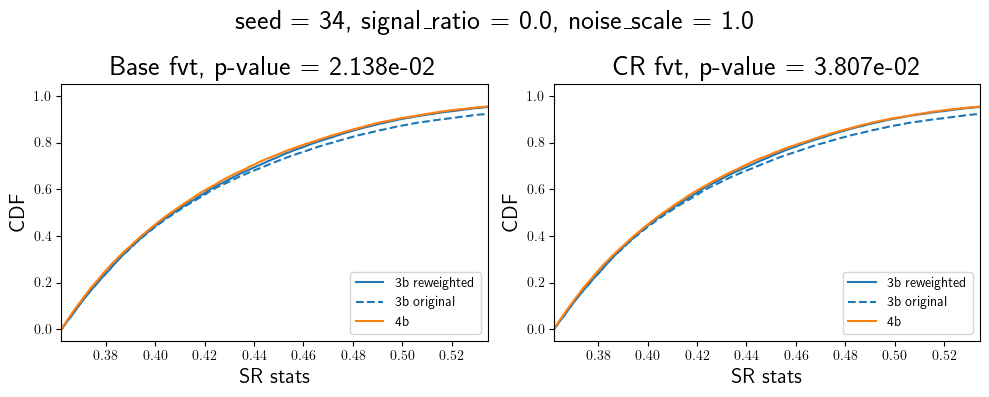

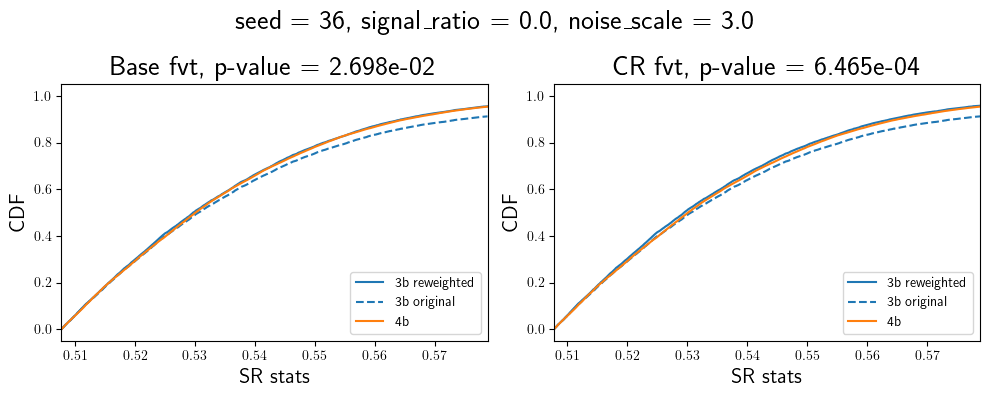

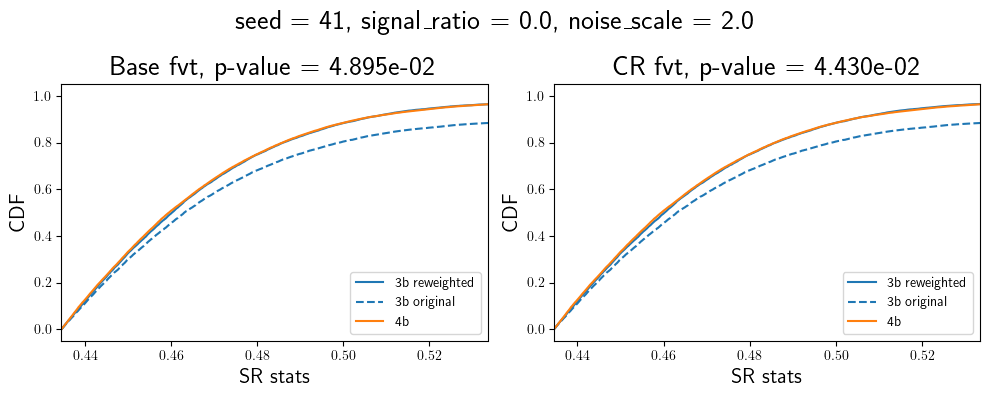

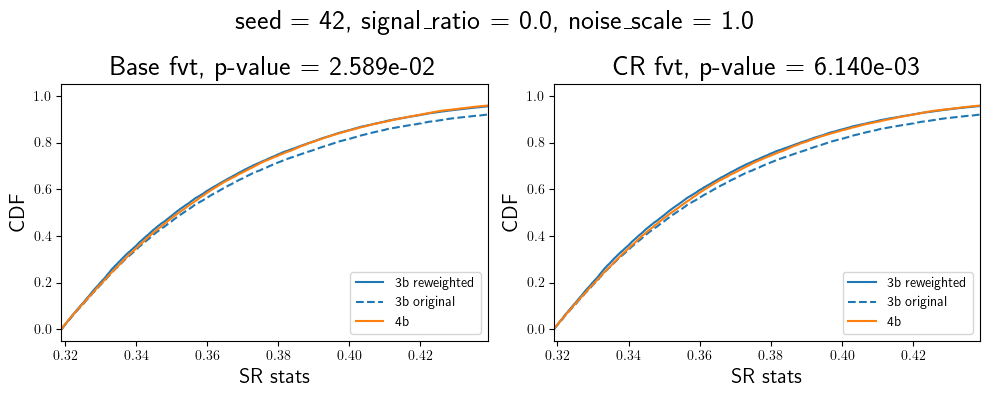

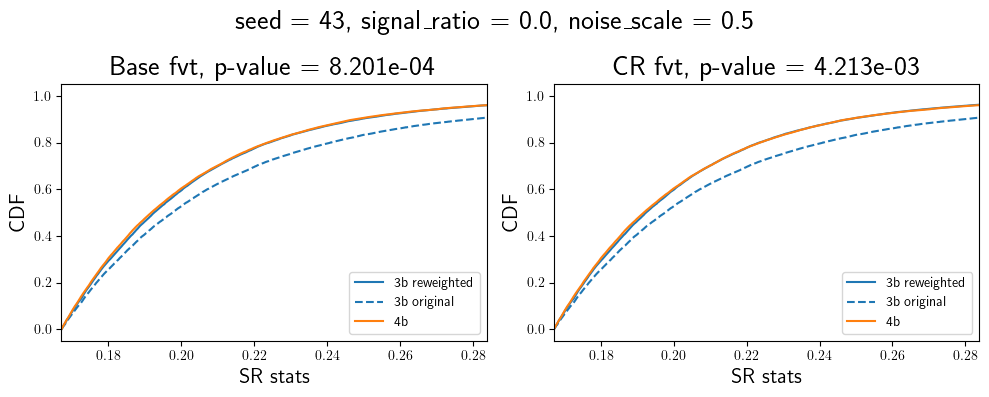

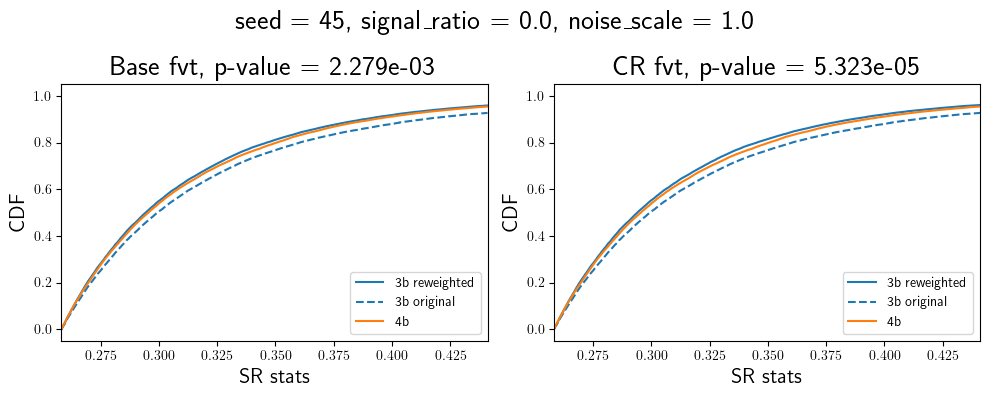

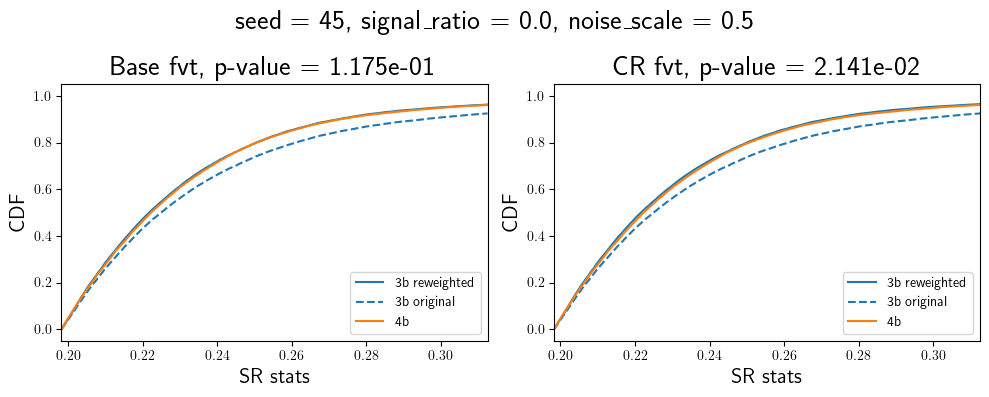

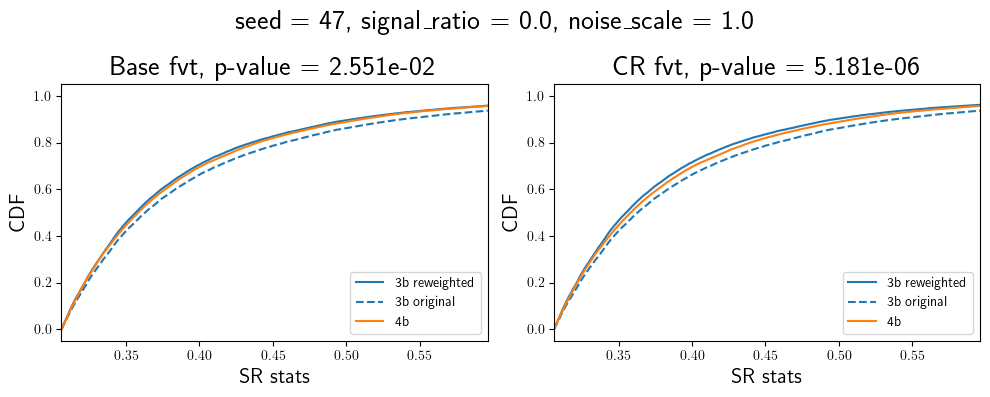

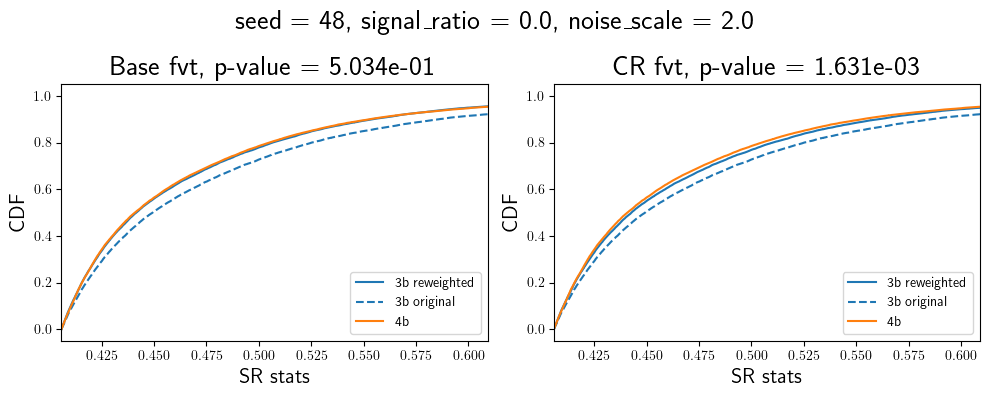

In [4]:
from plots import plot_cdf
from ks_test import max_cdf_diff
from ancillary_features import get_m4j

def c_alpha(alpha: float):
    return np.sqrt(np.log(2 / alpha) / 2)

signal_ratio = 0.0
signal_filename = "HH4b_picoAOD.h5"
SR_size = 0.05
sig_level = 0.05
noise_scales = [0.5, 1.0, 2.0, 3.0, np.inf]

hashes, hparams = TrainingInfo.find({"experiment_name": "CR_fvt_training_ensemble_max", 
                                "dataset": lambda x: x["signal_ratio"] == signal_ratio, 
                                "signal_region": lambda x: x["4b_in_SR"] == SR_size}, 
                                    return_hparams=True)
metadata = TrainingInfo.load_metadata()
seeds = [metadata[hash_]["dataset"]["seed"] for hash_ in hashes]
hashes = [hashes[i] for i in np.argsort(seeds)]

max_diff_list = {noise_scale_: {"base": [], "CR": []} for noise_scale_ in noise_scales}
tmp_list = {noise_scale_: {"base": [], "CR": []} for noise_scale_ in noise_scales}
p_value_list = {noise_scale_: {"base": [], "CR": []} for noise_scale_ in noise_scales}

for hash_ in hashes:
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    ensemble_mode = CR_fvt_tinfo.hparams["signal_region"]["ensemble_mode"]
    stats_type = CR_fvt_tinfo.hparams["signal_region"]["stats_type"]
    seed = CR_fvt_tinfo.hparams["dataset"]["seed"]
    signal_ratio = CR_fvt_tinfo.hparams["dataset"]["signal_ratio"]
    
    SR_stats_train, SR_stats_tst = compute_sr_stats(
        SR_stats_hashes,
        signal_filename,
        ensemble_mode,
        stats_type,
    )
    
    base_fvt_score_tst_mean = compute_sr_stats(
        SR_stats_hashes,
        signal_filename,
        "mean",
        "fvt",
    )[1]
    base_fvt_score_tst_mean = 1 - 1 / (1 + np.exp(base_fvt_score_tst_mean))
    
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
        noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
    else:
        noise_scale = np.inf
        
    msamples = MotherSamples.load(smeared_tinfo.ms_hash)
    events_train = events_from_scdinfo(
        msamples.scdinfo[smeared_tinfo.ms_idx], FEATURES, signal_filename
    )
    events_tst = events_from_scdinfo(
        msamples.scdinfo[~smeared_tinfo.ms_idx], FEATURES, signal_filename
    )
    SR_cut, CR_cut = get_SR_CR_cut(
            SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"]
        )
    SR_idx = SR_stats_tst >= SR_cut
    
    SR_stats_tst_SR = SR_stats_tst[SR_idx]
    events_tst_SR = events_tst[SR_idx]
    base_fvt_score_tst_SR = base_fvt_score_tst_mean[SR_idx]
    reweights_tst_SR_base = base_fvt_score_tst_SR / (1 - base_fvt_score_tst_SR)
    rw_tst_SR_base = np.where(events_tst_SR.is_4b, events_tst_SR.weights, reweights_tst_SR_base * events_tst_SR.weights)
    
    fvt_scores_tst_SR = CR_fvt_tinfo.aux_info["fvt_scores_tst_SR"]
    reweights_tst_SR = fvt_scores_tst_SR / (1 - fvt_scores_tst_SR)
    rw_tst_SR = np.where(events_tst_SR.is_4b, events_tst_SR.weights, reweights_tst_SR * events_tst_SR.weights)
    is_4b_tst_SR = events_tst_SR.is_4b
    
    # x_stats_SR = get_m4j(events_tst_SR.X_torch)
    x_stats_SR = SR_stats_tst_SR
    
    max_diff_base = max_cdf_diff(x_stats_SR[is_4b_tst_SR], x_stats_SR[~is_4b_tst_SR], 
                            rw_tst_SR_base[is_4b_tst_SR], rw_tst_SR_base[~is_4b_tst_SR])
    max_diff = max_cdf_diff(x_stats_SR[is_4b_tst_SR], x_stats_SR[~is_4b_tst_SR], 
                            rw_tst_SR[is_4b_tst_SR], rw_tst_SR[~is_4b_tst_SR])
    
    
    n_SR_4b = np.sum(is_4b_tst_SR)
    n_SR_3b = np.sum(~is_4b_tst_SR)
    tmp = np.sqrt((n_SR_4b + n_SR_3b) / (n_SR_4b * n_SR_3b))
    p_value_base = min(1.0, 2 * np.exp(-2 * (max_diff_base / tmp)**2))
    
    # print("max CDF diff with base fvt (mean of 15 ensemble): ", max_diff_base)
    # print("Threshold: ", c_alpha(sig_level) * tmp)
    # print("p-value: ", p_value_base)
    
    p_value = min(1.0, 2 * np.exp(-2 * (max_diff / tmp)**2))
    
    # print("max CDF diff with CR fvt (1 ensemble): ", max_diff)
    # print("Threshold: ", c_alpha(sig_level) * tmp)
    # print("p-value: ", p_value) 
    
    if p_value < sig_level:
        fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
        fig.suptitle(f"seed = {seed}, signal_ratio = {signal_ratio}, noise_scale = {noise_scale}")
        ax[0].set_title(f"Base fvt, p-value = {p_value_base:.3e}")
        plot_cdf(ax[0], x_stats_SR[~is_4b_tst_SR], rw_tst_SR_base[~is_4b_tst_SR], label="3b reweighted", 
                color=plt.cm.tab10(0))
        plot_cdf(ax[0], x_stats_SR[~is_4b_tst_SR], events_tst_SR.weights[~is_4b_tst_SR], label="3b original", 
                linestyle="--", color=plt.cm.tab10(0))
        plot_cdf(ax[0], x_stats_SR[is_4b_tst_SR], rw_tst_SR_base[is_4b_tst_SR], label="4b", 
                color=plt.cm.tab10(1))
        
        ax[1].set_title(f"CR fvt, p-value = {p_value:.3e}")
        plot_cdf(ax[1], x_stats_SR[~is_4b_tst_SR], rw_tst_SR[~is_4b_tst_SR], label="3b reweighted", 
                color=plt.cm.tab10(0))
        plot_cdf(ax[1], x_stats_SR[~is_4b_tst_SR], events_tst_SR.weights[~is_4b_tst_SR], label="3b original", 
                linestyle="--", color=plt.cm.tab10(0))
        plot_cdf(ax[1], x_stats_SR[is_4b_tst_SR], rw_tst_SR[is_4b_tst_SR], label="4b", 
                color=plt.cm.tab10(1))
        for a in ax:
            a.legend(loc="lower right")
            a.set_xlabel("SR stats")
            a.set_ylabel("CDF")
            xmin = np.min(x_stats_SR)
            xmax = np.quantile(x_stats_SR, 0.95)
            a.set_xlim(xmin, xmax)
        
        plt.tight_layout()
        plt.show()
    
    max_diff_list[noise_scale]["base"].append(max_diff_base)
    max_diff_list[noise_scale]["CR"].append(max_diff)
    tmp_list[noise_scale]["base"].append(tmp)
    tmp_list[noise_scale]["CR"].append(tmp)
    p_value_list[noise_scale]["base"].append(p_value_base)
    p_value_list[noise_scale]["CR"].append(p_value)
    
tmp_data = {"max_cdf_diff": max_diff_list, "tmp": tmp_list, "p_value": p_value_list}
pickle.dump(tmp_data, open("./data/tmp/max_cdf_data.pkl", "wb"))

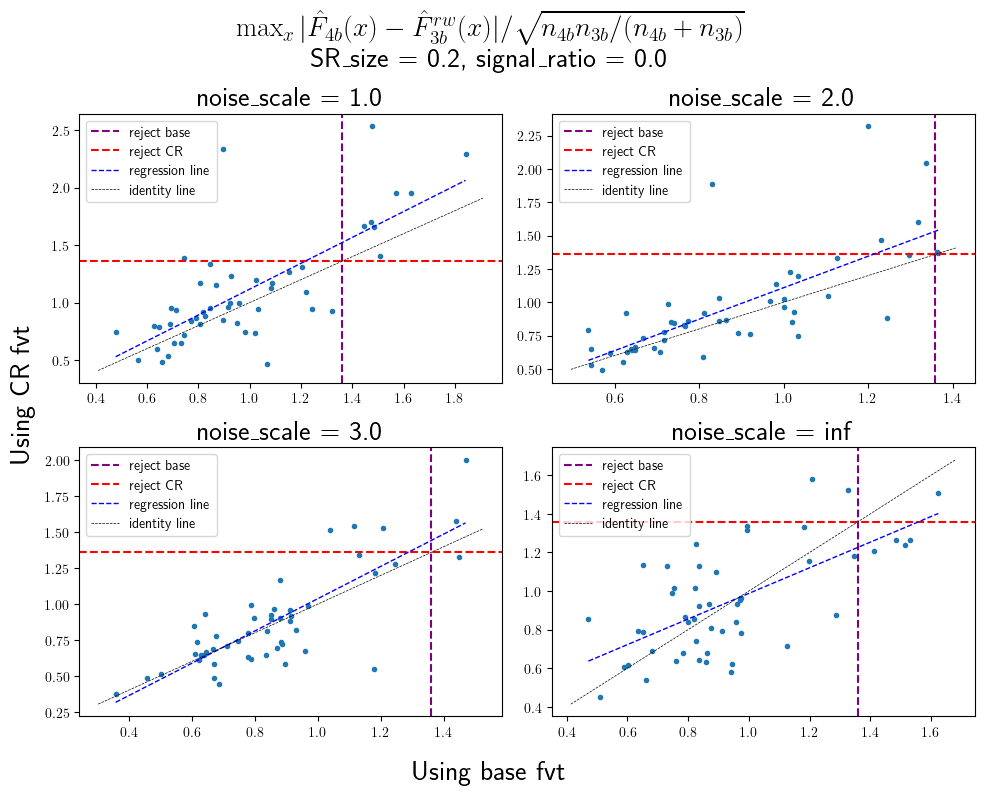

In [ ]:
from scipy import stats

signal_ratio = 0.0
tmp_data = pickle.load(open("./data/tmp/max_cdf_data_null.pkl", "rb"))

SR_size = 0.05

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
fig.suptitle(r"$\max_x |\hat{F}_{4b}(x) - \hat{F}_{3b}^{rw}(x)| / \sqrt{n_{4b} n_{3b} / (n_{4b} + n_{3b})}$" + 
             f"\nSR_size = {SR_size}, signal_ratio = {signal_ratio}")
fig.supxlabel("Using base fvt")
fig.supylabel("Using CR fvt")

for i, noise_scale in enumerate([1.0, 2.0, 3.0, np.inf]):
    ax = axs.flatten()[i]
    ax.set_title(f"noise_scale = {noise_scale}")
    plot_x = np.array(tmp_data["max_cdf_diff"][noise_scale]["base"]) / np.array(tmp_data["tmp"][noise_scale]["base"])
    plot_y = np.array(tmp_data["max_cdf_diff"][noise_scale]["CR"]) / np.array(tmp_data["tmp"][noise_scale]["CR"])
    ax.plot(plot_x, plot_y, "o")

    ax.axvline(x=c_alpha(sig_level), color="purple", linestyle="--", label="reject base")
    ax.axhline(y=c_alpha(sig_level), color="red", linestyle="--", label="reject CR")
    # plot regression line
    slope, intercept, r_value, p_value, std_err = stats.linregress(plot_x, plot_y)
    ax.plot([np.min(plot_x), np.max(plot_x)], 
            [slope * np.min(plot_x) + intercept, slope * np.max(plot_x) + intercept], 
            "b--", linewidth=1, label="regression line")
    xmin = ax.get_xlim()[0]
    xmax = ax.get_xlim()[1]
    ymin = ax.get_ylim()[0]
    ymax = ax.get_ylim()[1]
    ax.plot([xmin, xmax], [xmin, xmax], "--", color="black", linewidth=0.5, label="identity line")
    ax.legend()
plt.tight_layout()
plt.show()

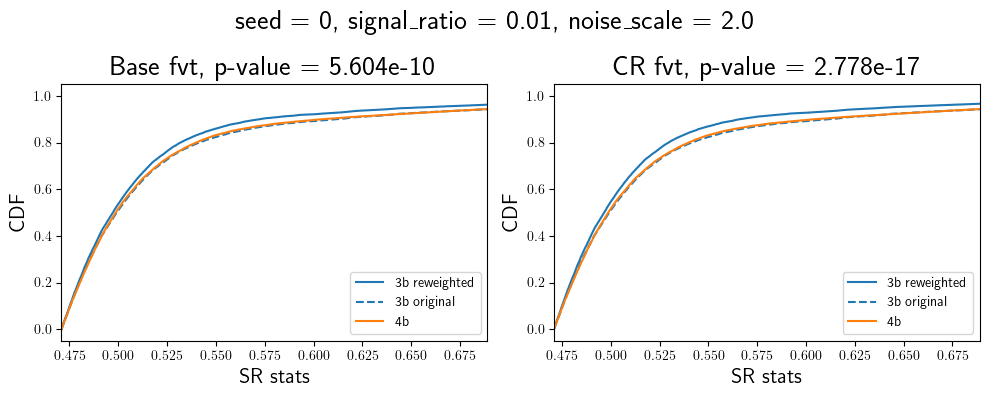

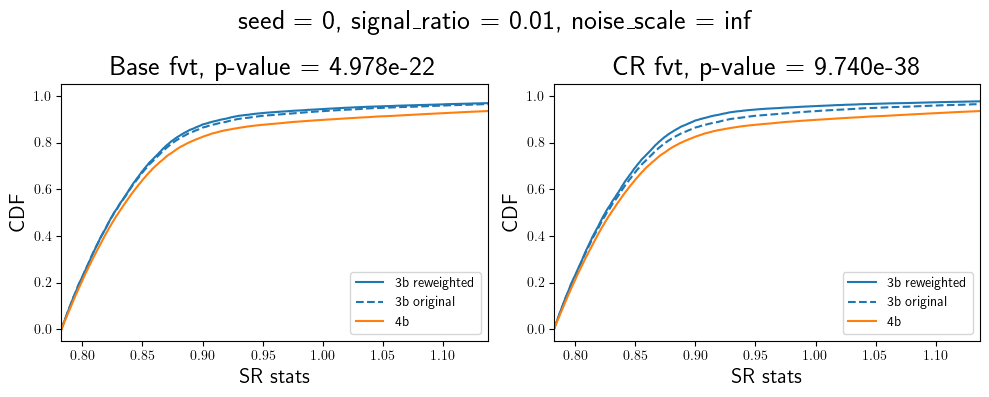

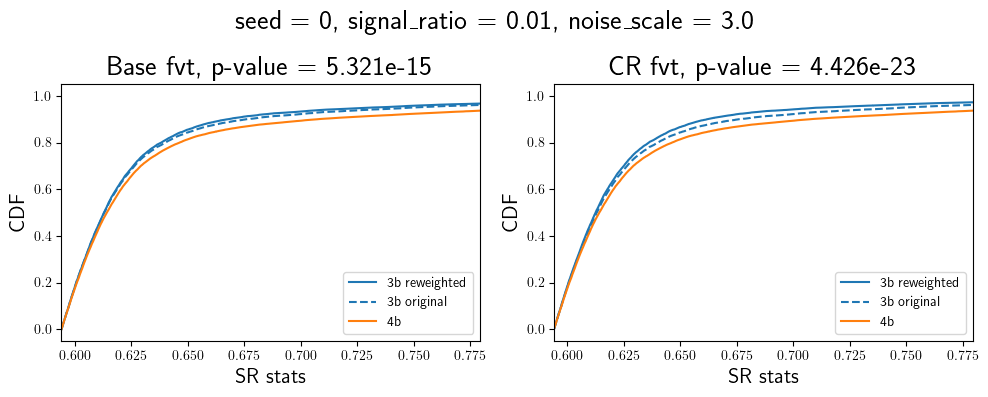

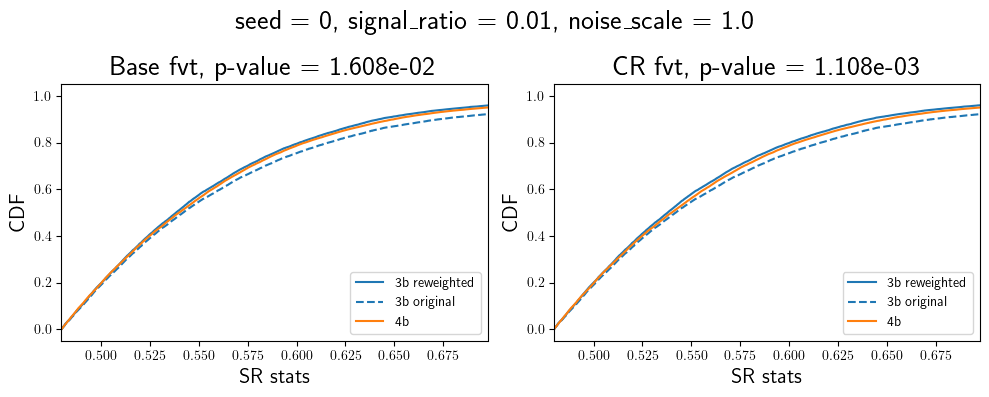

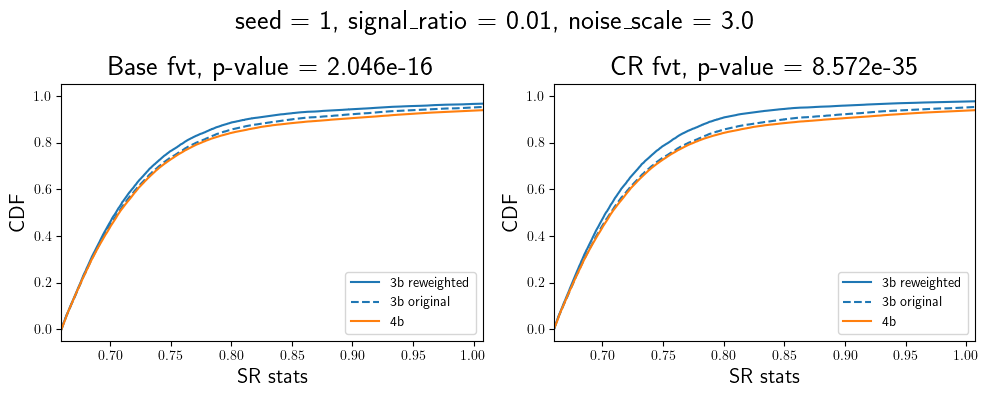

KeyboardInterrupt: 

In [20]:
from plots import plot_cdf
from ks_test import max_cdf_diff
from ancillary_features import get_m4j

signal_ratio = 0.01
signal_filename = "HH4b_picoAOD.h5"
SR_size = 0.05
sig_level = 0.05
noise_scales = [0.5, 1.0, 2.0, 3.0, np.inf]

hashes, hparams = TrainingInfo.find({"experiment_name": "CR_fvt_training_ensemble_max", 
                                "dataset": lambda x: x["signal_ratio"] == signal_ratio, 
                                "signal_region": lambda x: x["4b_in_SR"] == SR_size}, 
                                    return_hparams=True)
metadata = TrainingInfo.load_metadata()
seeds = [metadata[hash_]["dataset"]["seed"] for hash_ in hashes]
hashes = [hashes[i] for i in np.argsort(seeds)]

max_diff_list = {noise_scale_: {"base": [], "CR": []} for noise_scale_ in noise_scales}
tmp_list = {noise_scale_: {"base": [], "CR": []} for noise_scale_ in noise_scales}
p_value_list = {noise_scale_: {"base": [], "CR": []} for noise_scale_ in noise_scales}

for hash_ in hashes:
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    ensemble_mode = CR_fvt_tinfo.hparams["signal_region"]["ensemble_mode"]
    stats_type = CR_fvt_tinfo.hparams["signal_region"]["stats_type"]
    seed = CR_fvt_tinfo.hparams["dataset"]["seed"]
    signal_ratio = CR_fvt_tinfo.hparams["dataset"]["signal_ratio"]
    
    SR_stats_train, SR_stats_tst = compute_sr_stats(
        SR_stats_hashes,
        signal_filename,
        ensemble_mode,
        stats_type,
    )
    
    base_fvt_score_tst_mean = compute_sr_stats(
        SR_stats_hashes,
        signal_filename,
        "mean",
        "fvt",
    )[1]
    base_fvt_score_tst_mean = 1 - 1 / (1 + np.exp(base_fvt_score_tst_mean))
    
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
        noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
    else:
        noise_scale = np.inf
        
    msamples = MotherSamples.load(smeared_tinfo.ms_hash)
    events_train = events_from_scdinfo(
        msamples.scdinfo[smeared_tinfo.ms_idx], FEATURES, signal_filename
    )
    events_tst = events_from_scdinfo(
        msamples.scdinfo[~smeared_tinfo.ms_idx], FEATURES, signal_filename
    )
    SR_cut, CR_cut = get_SR_CR_cut(
            SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"]
        )
    SR_idx = SR_stats_tst >= SR_cut
    
    SR_stats_tst_SR = SR_stats_tst[SR_idx]
    events_tst_SR = events_tst[SR_idx]
    base_fvt_score_tst_SR = base_fvt_score_tst_mean[SR_idx]
    reweights_tst_SR_base = base_fvt_score_tst_SR / (1 - base_fvt_score_tst_SR)
    rw_tst_SR_base = np.where(events_tst_SR.is_4b, events_tst_SR.weights, reweights_tst_SR_base * events_tst_SR.weights)
    
    fvt_scores_tst_SR = CR_fvt_tinfo.aux_info["fvt_scores_tst_SR"]
    reweights_tst_SR = fvt_scores_tst_SR / (1 - fvt_scores_tst_SR)
    rw_tst_SR = np.where(events_tst_SR.is_4b, events_tst_SR.weights, reweights_tst_SR * events_tst_SR.weights)
    is_4b_tst_SR = events_tst_SR.is_4b
    
    # x_stats_SR = get_m4j(events_tst_SR.X_torch)
    x_stats_SR = SR_stats_tst_SR
    
    max_diff_base = max_cdf_diff(x_stats_SR[is_4b_tst_SR], x_stats_SR[~is_4b_tst_SR], 
                            rw_tst_SR_base[is_4b_tst_SR], rw_tst_SR_base[~is_4b_tst_SR])
    max_diff = max_cdf_diff(x_stats_SR[is_4b_tst_SR], x_stats_SR[~is_4b_tst_SR], 
                            rw_tst_SR[is_4b_tst_SR], rw_tst_SR[~is_4b_tst_SR])
    
    
    n_SR_4b = np.sum(is_4b_tst_SR)
    n_SR_3b = np.sum(~is_4b_tst_SR)
    tmp = np.sqrt((n_SR_4b + n_SR_3b) / (n_SR_4b * n_SR_3b))
    p_value_base = min(1.0, 2 * np.exp(-2 * (max_diff_base / tmp)**2))
    
    # print("max CDF diff with base fvt (mean of 15 ensemble): ", max_diff_base)
    # print("Threshold: ", c_alpha(sig_level) * tmp)
    # print("p-value: ", p_value_base)
    
    p_value = min(1.0, 2 * np.exp(-2 * (max_diff / tmp)**2))
    
    # print("max CDF diff with CR fvt (1 ensemble): ", max_diff)
    # print("Threshold: ", c_alpha(sig_level) * tmp)
    # print("p-value: ", p_value) 
    
    if p_value < sig_level:
        fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
        fig.suptitle(f"seed = {seed}, signal_ratio = {signal_ratio}, noise_scale = {noise_scale}")
        ax[0].set_title(f"Base fvt, p-value = {p_value_base:.3e}")
        plot_cdf(ax[0], x_stats_SR[~is_4b_tst_SR], rw_tst_SR_base[~is_4b_tst_SR], label="3b reweighted", 
                color=plt.cm.tab10(0))
        plot_cdf(ax[0], x_stats_SR[~is_4b_tst_SR], events_tst_SR.weights[~is_4b_tst_SR], label="3b original", 
                linestyle="--", color=plt.cm.tab10(0))
        plot_cdf(ax[0], x_stats_SR[is_4b_tst_SR], rw_tst_SR_base[is_4b_tst_SR], label="4b", 
                color=plt.cm.tab10(1))
        
        ax[1].set_title(f"CR fvt, p-value = {p_value:.3e}")
        plot_cdf(ax[1], x_stats_SR[~is_4b_tst_SR], rw_tst_SR[~is_4b_tst_SR], label="3b reweighted", 
                color=plt.cm.tab10(0))
        plot_cdf(ax[1], x_stats_SR[~is_4b_tst_SR], events_tst_SR.weights[~is_4b_tst_SR], label="3b original", 
                linestyle="--", color=plt.cm.tab10(0))
        plot_cdf(ax[1], x_stats_SR[is_4b_tst_SR], rw_tst_SR[is_4b_tst_SR], label="4b", 
                color=plt.cm.tab10(1))
        for a in ax:
            a.legend(loc="lower right")
            a.set_xlabel("SR stats")
            a.set_ylabel("CDF")
            xmin = np.min(x_stats_SR)
            xmax = np.quantile(x_stats_SR, 0.95)
            a.set_xlim(xmin, xmax)
        
        plt.tight_layout()
        plt.show()
    
    max_diff_list[noise_scale]["base"].append(max_diff_base)
    max_diff_list[noise_scale]["CR"].append(max_diff)
    tmp_list[noise_scale]["base"].append(tmp)
    tmp_list[noise_scale]["CR"].append(tmp)
    p_value_list[noise_scale]["base"].append(p_value_base)
    p_value_list[noise_scale]["CR"].append(p_value)
    
tmp_data = {"max_cdf_diff": max_diff_list, "tmp": tmp_list, "p_value": p_value_list}
pickle.dump(tmp_data, open(f"./data/tmp/max_cdf_data_{signal_ratio}.pkl", "wb"))

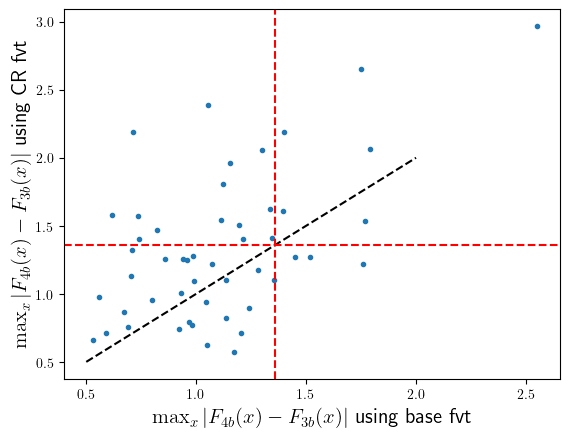

In [19]:
plt.plot(np.array(max_diff_list["base"]) / np.array(tmp_list["base"]), 
         np.array(max_diff_list["CR"]) / np.array(tmp_list["CR"]), "o")
plt.plot([0.5, 2.0], [0.5, 2.0], "--", color="black")
plt.xlabel(r"$\max_x |F_{4b}(x) - F_{3b}(x)|$ using base fvt")
plt.ylabel(r"$\max_x |F_{4b}(x) - F_{3b}(x)|$ using CR fvt")
plt.axvline(x=c_alpha(sig_level), color="red", linestyle="--")
plt.axhline(y=c_alpha(sig_level), color="red", linestyle="--")
plt.show()

theta_max = 1.2007e+00
theta_min = -1.2007e+00
t = -0.5009053945541382, active_i = 17930, slopes[active_i] = 0.00841684639453888, i_left = 0, i_right = 26671
t = -0.5009053945541382, i_left = 0, i_right = 17930, slopes[i_left] = -0.014053165912628174, slopes[i_right] = 0.00841684639453888, intercepts[i_left] = -0.007039306219667196, intercepts[i_right] = 0.010540300980210304
t = -0.7823585867881775, active_i = 6109, slopes[active_i] = -0.011333286762237549, i_left = 0, i_right = 17930
t = -0.7823585867881775, i_left = 6109, i_right = 17930, slopes[i_left] = -0.011333286762237549, slopes[i_right] = 0.00841684639453888, intercepts[i_left] = -0.0016205768333747983, intercepts[i_right] = 0.010540300980210304
t = -0.6157364845275879, active_i = 14608, slopes[active_i] = 0.0029211528599262238, i_left = 6109, i_right = 17930
t = -0.6157364845275879, i_left = 6109, i_right = 14608, slopes[i_left] = -0.011333286762237549, slopes[i_right] = 0.0029211528599262238, intercepts[i_left] = -0.00162057

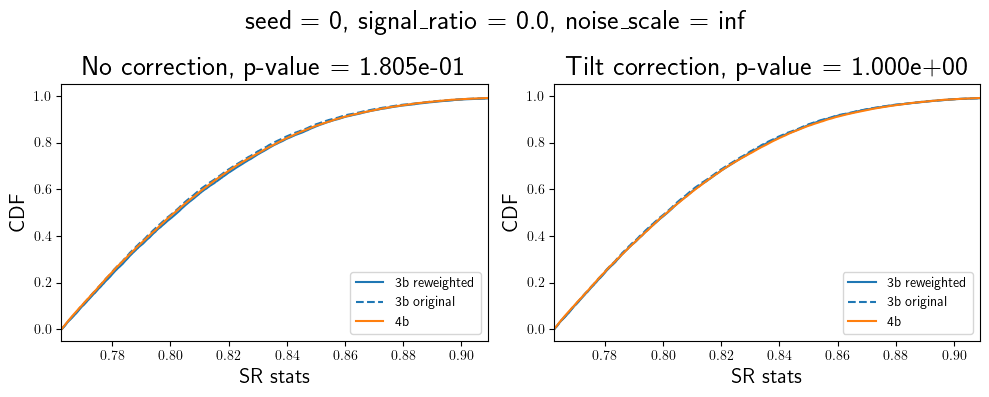

theta_max = 1.7603e+00
theta_min = -1.7603e+00
t = 0.3626162111759186, active_i = 18939, slopes[active_i] = 0.010209143161773682, i_left = 0, i_right = 27133
t = 0.3626162111759186, i_left = 0, i_right = 18939, slopes[i_left] = -0.015491575002670288, slopes[i_right] = 0.010209143161773682, intercepts[i_left] = 0.005620052106678486, intercepts[i_right] = 0.0032972125336527824
t = 0.09038034081459045, active_i = 792, slopes[active_i] = -0.015441834926605225, i_left = 0, i_right = 18939
t = 0.09038034081459045, i_left = 792, i_right = 18939, slopes[i_left] = -0.015441834926605225, slopes[i_right] = 0.010209143161773682, intercepts[i_left] = 0.008235990069806576, intercepts[i_right] = 0.0032972125336527824
t = 0.1925375908613205, active_i = 10213, slopes[active_i] = -0.0071499645709991455, i_left = 792, i_right = 18939
t = 0.1925375908613205, i_left = 10213, i_right = 18939, slopes[i_left] = -0.0071499645709991455, slopes[i_right] = 0.010209143161773682, intercepts[i_left] = 0.007127116434

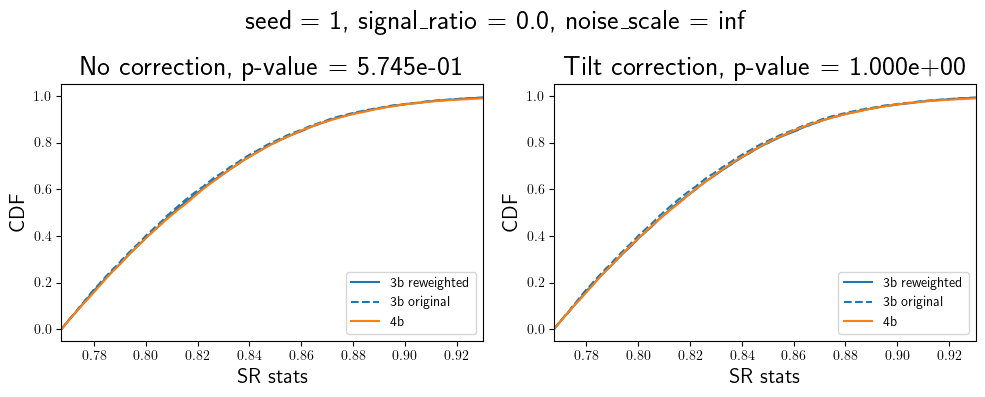

theta_max = 1.4097e+00
theta_min = -1.4097e+00
t = -0.3029775619506836, active_i = 6258, slopes[active_i] = -0.011734843254089355, i_left = 0, i_right = 26635
t = -0.3029775619506836, i_left = 6258, i_right = 26635, slopes[i_left] = -0.011734843254089355, slopes[i_right] = 0.01471748948097229, intercepts[i_left] = 0.003256560768932104, intercepts[i_right] = 0.004459069110453129
t = -0.04545944556593895, active_i = 24839, slopes[active_i] = 0.014474719762802124, i_left = 6258, i_right = 26635
t = -0.04545944556593895, i_left = 6258, i_right = 24839, slopes[i_left] = -0.011734843254089355, slopes[i_right] = 0.014474719762802124, intercepts[i_left] = 0.003256560768932104, intercepts[i_right] = 0.007070504128932953
t = -0.1455172449350357, active_i = 6258, slopes[active_i] = -0.011734843254089355, i_left = 6258, i_right = 24839
Found minimum at t = -0.1455172449350357, iteration 2
Threshold: 1.4286e-02
Correction mode: exponential
theta = -1.4552e-01
max_diff_tilted = 5.0361e-03
p-value_ti

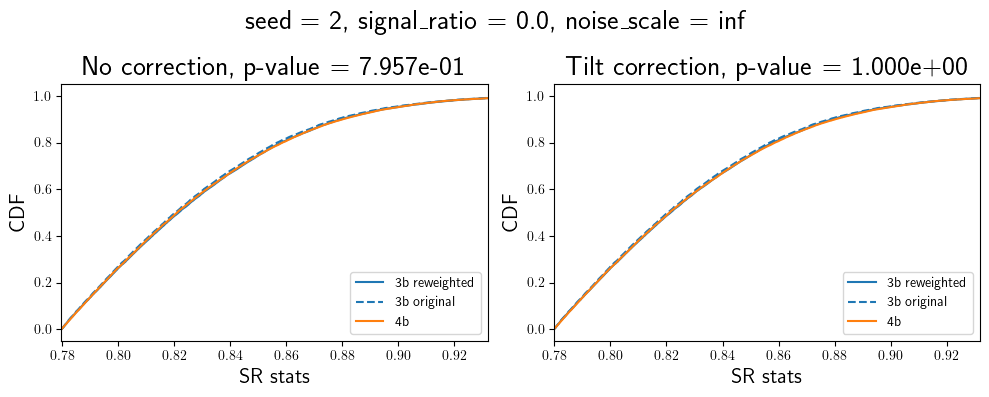

theta_max = 1.6082e+00
theta_min = -1.6082e+00
t = 0.02751350961625576, active_i = 7884, slopes[active_i] = -0.01017734408378601, i_left = 0, i_right = 27229
t = 0.02751350961625576, i_left = 7884, i_right = 27229, slopes[i_left] = -0.01017734408378601, slopes[i_right] = 0.014812946319580078, intercepts[i_left] = 0.012281716801226139, intercepts[i_right] = -0.000419764342950657
t = 0.5082566738128662, active_i = 20213, slopes[active_i] = 0.011158943176269531, i_left = 7884, i_right = 27229
t = 0.5082566738128662, i_left = 7884, i_right = 20213, slopes[i_left] = -0.01017734408378601, slopes[i_right] = 0.011158943176269531, intercepts[i_left] = 0.012281716801226139, intercepts[i_right] = 0.006061871070414782
t = 0.29151490330696106, active_i = 7884, slopes[active_i] = -0.01017734408378601, i_left = 7884, i_right = 20213
Found minimum at t = 0.29151490330696106, iteration 2
Threshold: 1.4151e-02
Correction mode: exponential
theta = 2.9151e-01
max_diff_tilted = 9.4201e-03
p-value_tilted = 

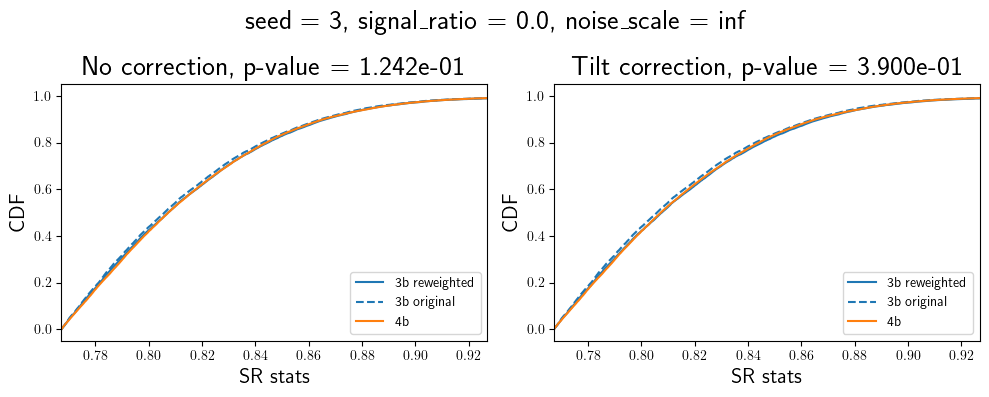

theta_max = 1.2724e+00
theta_min = -1.2724e+00
t = -0.3941381871700287, active_i = 5844, slopes[active_i] = -0.012877583503723145, i_left = 0, i_right = 27747
t = -0.3941381871700287, i_left = 5844, i_right = 27747, slopes[i_left] = -0.012877583503723145, slopes[i_right] = 0.015338867902755737, intercepts[i_left] = 0.0031664296984672546, intercepts[i_right] = 0.006045633461326361
t = -0.1020398959517479, active_i = 20614, slopes[active_i] = 0.011639326810836792, i_left = 5844, i_right = 27747
t = -0.1020398959517479, i_left = 5844, i_right = 20614, slopes[i_left] = -0.012877583503723145, slopes[i_right] = 0.011639326810836792, intercepts[i_left] = 0.0031664296984672546, intercepts[i_right] = 0.010140571743249893
t = -0.28446251153945923, active_i = 8587, slopes[active_i] = -0.009927630424499512, i_left = 5844, i_right = 20614
t = -0.28446251153945923, i_left = 8587, i_right = 20614, slopes[i_left] = -0.009927630424499512, slopes[i_right] = 0.011639326810836792, intercepts[i_left] = 0.0

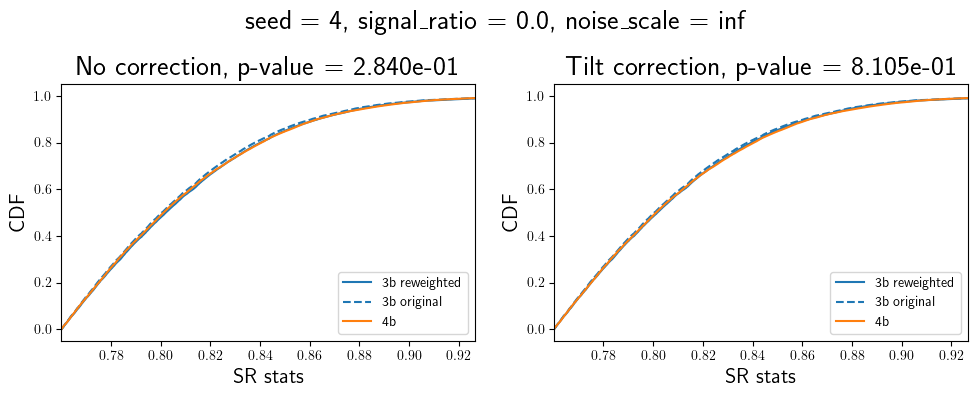

theta_max = 1.2884e+00
theta_min = -1.2884e+00
t = -0.26031503081321716, active_i = 5897, slopes[active_i] = -0.01378101110458374, i_left = 0, i_right = 27315
t = -0.26031503081321716, i_left = 5897, i_right = 27315, slopes[i_left] = -0.01378101110458374, slopes[i_right] = 0.016728907823562622, intercepts[i_left] = 0.0041650328785181046, intercepts[i_right] = 0.004395107738673687
t = -0.0075409854762256145, active_i = 22676, slopes[active_i] = 0.014906346797943115, i_left = 5897, i_right = 27315
t = -0.0075409854762256145, i_left = 5897, i_right = 22676, slopes[i_left] = -0.01378101110458374, slopes[i_right] = 0.014906346797943115, intercepts[i_left] = 0.0041650328785181046, intercepts[i_right] = 0.007627747021615505
t = -0.12070523202419281, active_i = 16752, slopes[active_i] = 0.007114112377166748, i_left = 5897, i_right = 22676
t = -0.12070523202419281, i_left = 5897, i_right = 16752, slopes[i_left] = -0.01378101110458374, slopes[i_right] = 0.007114112377166748, intercepts[i_left] =

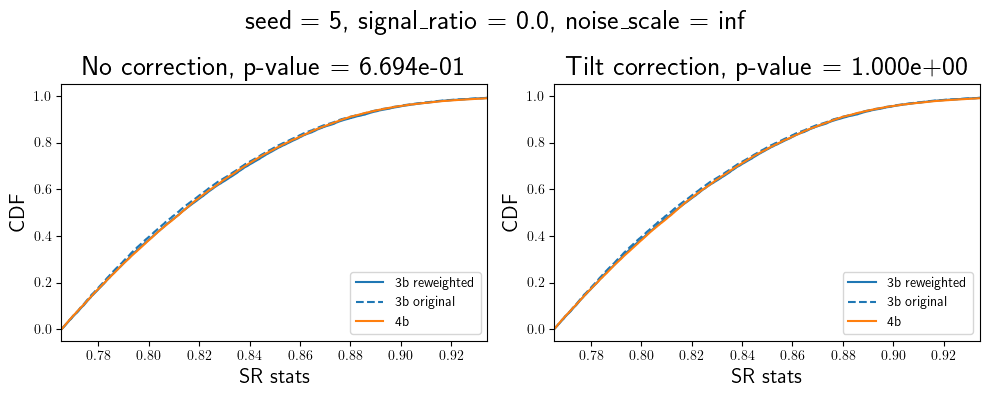

theta_max = 1.4761e+00
theta_min = -1.4761e+00
t = 0.09330842643976212, active_i = 23904, slopes[active_i] = 0.014825522899627686, i_left = 0, i_right = 27173
t = 0.09330842643976212, i_left = 0, i_right = 23904, slopes[i_left] = -0.015666157007217407, slopes[i_right] = 0.014825522899627686, intercepts[i_left] = 0.00146178447175771, intercepts[i_right] = 0.0040372139774262905
t = -0.08446335792541504, active_i = 4362, slopes[active_i] = -0.014158129692077637, i_left = 0, i_right = 23904
t = -0.08446335792541504, i_left = 4362, i_right = 23904, slopes[i_left] = -0.014158129692077637, slopes[i_right] = 0.014825522899627686, intercepts[i_left] = 0.0065954322926700115, intercepts[i_right] = 0.0040372139774262905
t = 0.08826418220996857, active_i = 4362, slopes[active_i] = -0.014158129692077637, i_left = 4362, i_right = 23904
Found minimum at t = 0.08826418220996857, iteration 2
Threshold: 1.4172e-02
Correction mode: exponential
theta = 8.8264e-02
max_diff_tilted = 5.4182e-03
p-value_tilted

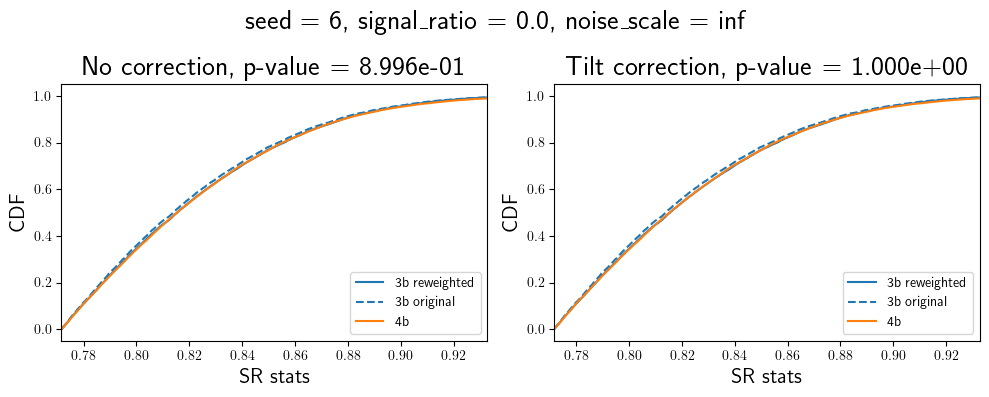

theta_max = 1.0016e+00
theta_min = -1.0016e+00
t = 0.15605387091636658, active_i = 17328, slopes[active_i] = 0.007062867283821106, i_left = 0, i_right = 27095
t = 0.15605387091636658, i_left = 0, i_right = 17328, slopes[i_left] = -0.013856261968612671, slopes[i_right] = 0.007062867283821106, intercepts[i_left] = 0.002175513654947281, intercepts[i_right] = 0.004338760860264301
t = -0.10341000556945801, active_i = 4333, slopes[active_i] = -0.012566804885864258, i_left = 0, i_right = 17328
t = -0.10341000556945801, i_left = 4333, i_right = 17328, slopes[i_left] = -0.012566804885864258, slopes[i_right] = 0.007062867283821106, intercepts[i_left] = 0.004711160436272621, intercepts[i_right] = 0.004338760860264301
t = 0.018971258774399757, active_i = 17328, slopes[active_i] = 0.007062867283821106, i_left = 4333, i_right = 17328
Found minimum at t = 0.018971258774399757, iteration 2
Threshold: 1.4175e-02
Correction mode: exponential
theta = 1.8971e-02
max_diff_tilted = 4.5446e-03
p-value_tilted

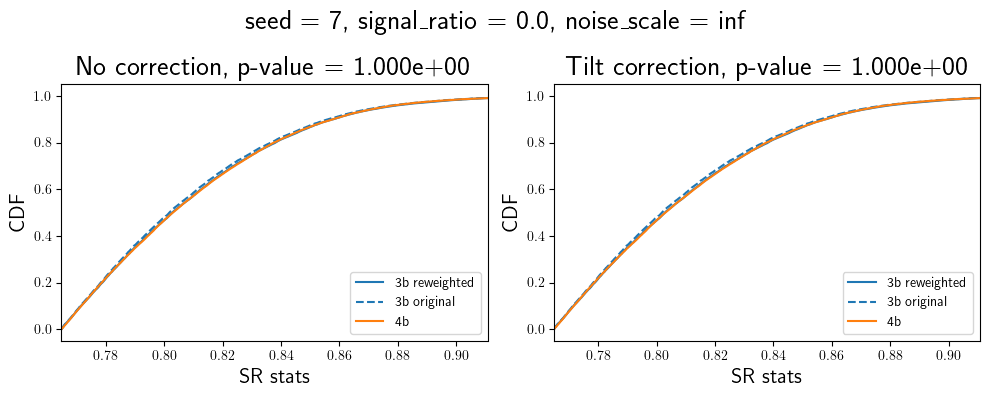

theta_max = 1.3715e+00
theta_min = -1.3715e+00
t = -0.8722990155220032, active_i = 5860, slopes[active_i] = -0.013337463140487671, i_left = 0, i_right = 26549
t = -0.8722990155220032, i_left = 5860, i_right = 26549, slopes[i_left] = -0.013337463140487671, slopes[i_right] = 0.016279160976409912, intercepts[i_left] = -0.006247072946280241, intercepts[i_right] = 0.014299864880740643
t = -0.6937636733055115, active_i = 22827, slopes[active_i] = 0.015095114707946777, i_left = 5860, i_right = 26549
t = -0.6937636733055115, i_left = 5860, i_right = 22827, slopes[i_left] = -0.013337463140487671, slopes[i_right] = 0.015095114707946777, intercepts[i_left] = -0.006247072946280241, intercepts[i_right] = 0.015790218487381935
t = -0.775071918964386, active_i = 5860, slopes[active_i] = -0.013337463140487671, i_left = 5860, i_right = 22827
Found minimum at t = -0.775071918964386, iteration 2
Threshold: 1.4309e-02
Correction mode: exponential
theta = -7.7507e-01
max_diff_tilted = 4.3237e-03
p-value_til

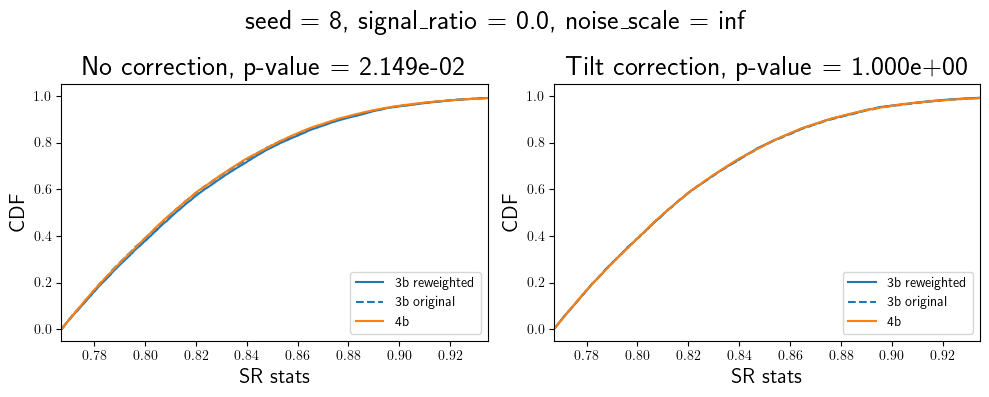

theta_max = 1.5388e+00
theta_min = -1.5388e+00
t = -0.14682620763778687, active_i = 6043, slopes[active_i] = -0.011792093515396118, i_left = 0, i_right = 27141
t = -0.14682620763778687, i_left = 6043, i_right = 27141, slopes[i_left] = -0.011792093515396118, slopes[i_right] = 0.0144406259059906, intercepts[i_left] = 0.008265633136034012, intercepts[i_right] = 0.0021202622447162867
t = 0.2342635989189148, active_i = 24626, slopes[active_i] = 0.01398557424545288, i_left = 6043, i_right = 27141
t = 0.2342635989189148, i_left = 6043, i_right = 24626, slopes[i_left] = -0.011792093515396118, slopes[i_right] = 0.01398557424545288, intercepts[i_left] = 0.008265633136034012, intercepts[i_right] = 0.0056348745711147785
t = 0.10205572843551636, active_i = 24626, slopes[active_i] = 0.01398557424545288, i_left = 6043, i_right = 24626
Found minimum at t = 0.10205572843551636, iteration 2
Threshold: 1.4166e-02
Correction mode: exponential
theta = 1.0206e-01
max_diff_tilted = 7.1404e-03
p-value_tilted 

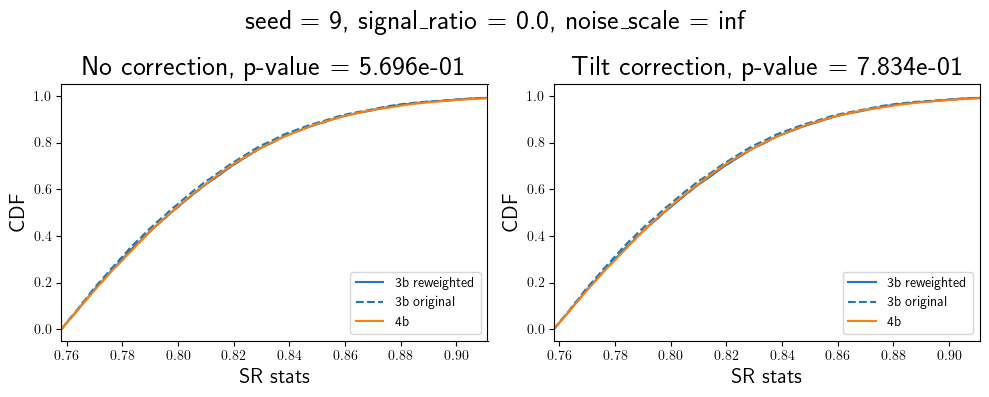

theta_max = 1.5357e+00
theta_min = -1.5357e+00
t = 0.12062384933233261, active_i = 17198, slopes[active_i] = 0.007443904876708984, i_left = 0, i_right = 26857
t = 0.12062384933233261, i_left = 0, i_right = 17198, slopes[i_left] = -0.014528900384902954, slopes[i_right] = 0.007443904876708984, intercepts[i_left] = 0.0017525318544358015, intercepts[i_right] = 0.005556041374802589
t = -0.1731007695198059, active_i = 8602, slopes[active_i] = -0.00894993543624878, i_left = 0, i_right = 17198
t = -0.1731007695198059, i_left = 8602, i_right = 17198, slopes[i_left] = -0.00894993543624878, slopes[i_right] = 0.007443904876708984, intercepts[i_left] = 0.0072310734540224075, intercepts[i_right] = 0.005556041374802589
t = 0.10217447578907013, active_i = 8602, slopes[active_i] = -0.00894993543624878, i_left = 8602, i_right = 17198
Found minimum at t = 0.10217447578907013, iteration 2
Threshold: 1.4236e-02
Correction mode: exponential
theta = 1.0217e-01
max_diff_tilted = 6.3895e-03
p-value_tilted = 9.

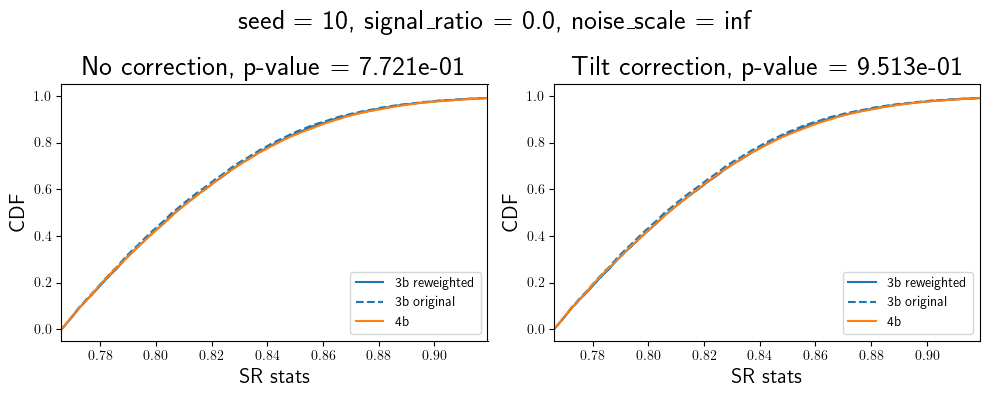

theta_max = 1.7486e+00
theta_min = -1.7486e+00
t = -0.35546088218688965, active_i = 10319, slopes[active_i] = -0.005821585655212402, i_left = 0, i_right = 26517
t = -0.35546088218688965, i_left = 10319, i_right = 26517, slopes[i_left] = -0.005821585655212402, slopes[i_right] = 0.013823270797729492, intercepts[i_left] = 0.005301410332322121, intercepts[i_right] = 0.004913631826639175
t = 0.019739441573619843, active_i = 26171, slopes[active_i] = 0.013815581798553467, i_left = 10319, i_right = 26517
t = 0.019739441573619843, i_left = 10319, i_right = 26171, slopes[i_left] = -0.005821585655212402, slopes[i_right] = 0.013815581798553467, intercepts[i_left] = 0.005301410332322121, intercepts[i_right] = 0.007081621326506138
t = -0.09065518528223038, active_i = 19852, slopes[active_i] = 0.010575279593467712, i_left = 10319, i_right = 26171
t = -0.09065518528223038, i_left = 10319, i_right = 19852, slopes[i_left] = -0.005821585655212402, slopes[i_right] = 0.010575279593467712, intercepts[i_lef

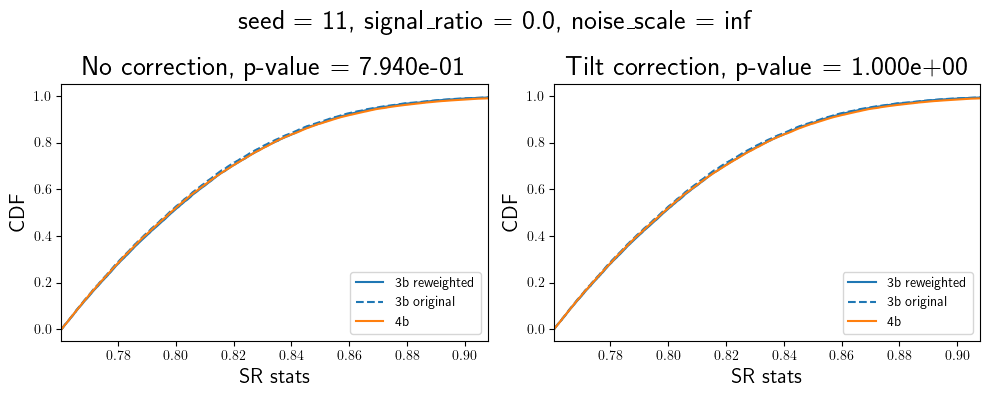

theta_max = 1.4150e+00
theta_min = -1.4150e+00
t = -0.3037714958190918, active_i = 10734, slopes[active_i] = -0.006935589015483856, i_left = 0, i_right = 27497
t = -0.3037714958190918, i_left = 10734, i_right = 27497, slopes[i_left] = -0.006935589015483856, slopes[i_right] = 0.0163460373878479, intercepts[i_left] = 0.006291357334703207, intercepts[i_right] = 0.004965460393577814
t = 0.05695035681128502, active_i = 22278, slopes[active_i] = 0.014214396476745605, i_left = 10734, i_right = 27497
t = 0.05695035681128502, i_left = 10734, i_right = 22278, slopes[i_left] = -0.006935589015483856, slopes[i_right] = 0.014214396476745605, intercepts[i_left] = 0.006291357334703207, intercepts[i_right] = 0.009952577762305737
t = -0.17310746014118195, active_i = 22278, slopes[active_i] = 0.014214396476745605, i_left = 10734, i_right = 22278
Found minimum at t = -0.17310746014118195, iteration 2
Threshold: 1.4145e-02
Correction mode: exponential
theta = -1.7311e-01
max_diff_tilted = 7.5608e-03
p-valu

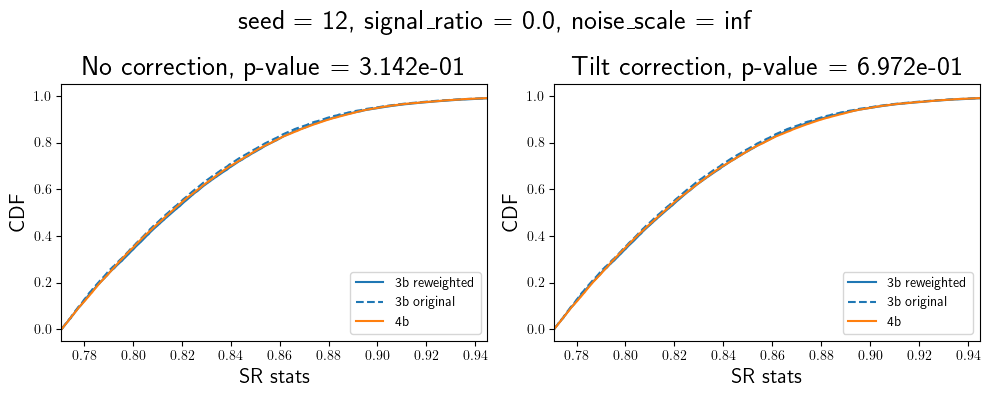

theta_max = 1.7536e+00
theta_min = -1.7536e+00
t = 0.5631630420684814, active_i = 23430, slopes[active_i] = 0.014288246631622314, i_left = 0, i_right = 27125
t = 0.5631630420684814, i_left = 0, i_right = 23430, slopes[i_left] = -0.015369623899459839, slopes[i_right] = 0.014288246631622314, intercepts[i_left] = 0.008654081262648106, intercepts[i_right] = -0.0019903872162103653
t = 0.3589087128639221, active_i = 3401, slopes[active_i] = -0.01445239782333374, i_left = 0, i_right = 23430
t = 0.3589087128639221, i_left = 3401, i_right = 23430, slopes[i_left] = -0.01445239782333374, slopes[i_right] = 0.014288246631622314, intercepts[i_left] = 0.013769187964498997, intercepts[i_right] = -0.0019903872162103653
t = 0.5483375787734985, active_i = 23430, slopes[active_i] = 0.014288246631622314, i_left = 3401, i_right = 23430
Found minimum at t = 0.5483375787734985, iteration 2
Threshold: 1.4189e-02
Correction mode: exponential
theta = 5.4834e-01
max_diff_tilted = 5.9977e-03
p-value_tilted = 1.000

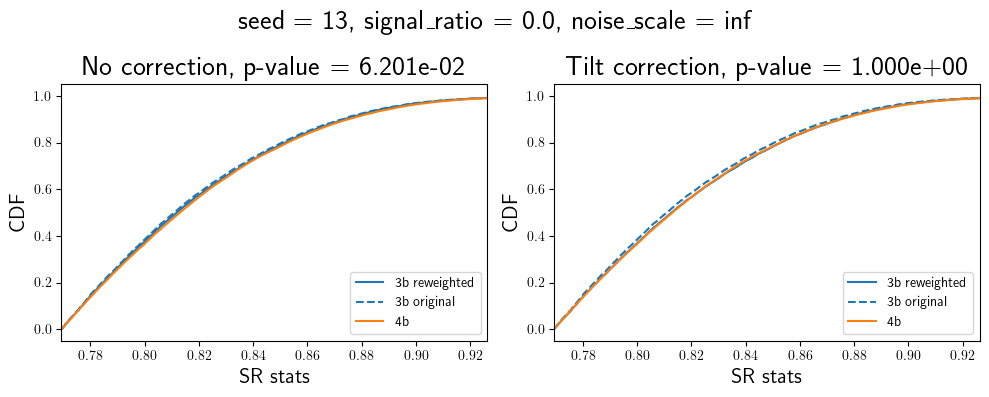

theta_max = 1.2289e+00
theta_min = -1.2289e+00
t = 0.36504697799682617, active_i = 20606, slopes[active_i] = 0.012247800827026367, i_left = 0, i_right = 26707
t = 0.36504697799682617, i_left = 0, i_right = 20606, slopes[i_left] = -0.015246778726577759, slopes[i_right] = 0.012247800827026367, intercepts[i_left] = 0.0056150127202272415, intercepts[i_right] = 0.0007854407303966582
t = 0.17565542459487915, active_i = 1221, slopes[active_i] = -0.015127390623092651, i_left = 0, i_right = 20606
t = 0.17565542459487915, i_left = 1221, i_right = 20606, slopes[i_left] = -0.015127390623092651, slopes[i_right] = 0.012247800827026367, intercepts[i_left] = 0.008961117826402187, intercepts[i_right] = 0.0007854407303966582
t = 0.2986527681350708, active_i = 1221, slopes[active_i] = -0.015127390623092651, i_left = 1221, i_right = 20606
Found minimum at t = 0.2986527681350708, iteration 2
Threshold: 1.4231e-02
Correction mode: exponential
theta = 2.9865e-01
max_diff_tilted = 4.5392e-03
p-value_tilted = 

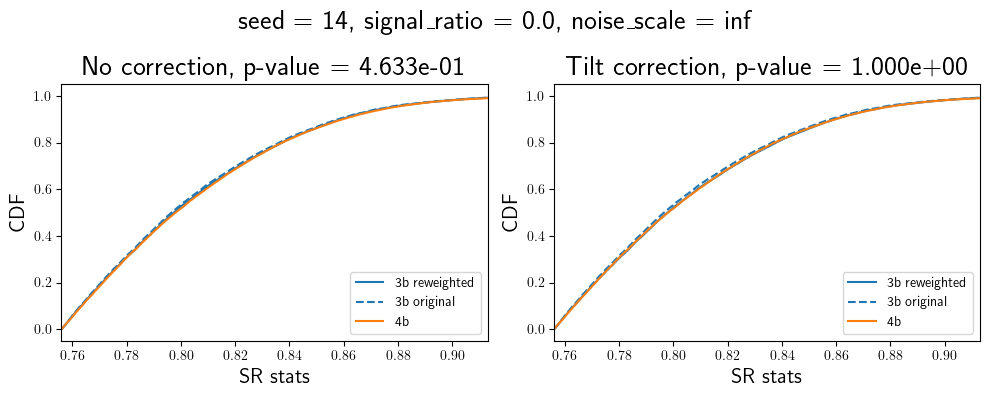

theta_max = 2.1177e+00
theta_min = -2.1177e+00
t = 0.005128582939505577, active_i = 20085, slopes[active_i] = 0.00970315933227539, i_left = 0, i_right = 26877
t = 0.005128582939505577, i_left = 0, i_right = 20085, slopes[i_left] = -0.012703806161880493, slopes[i_right] = 0.00970315933227539, intercepts[i_left] = 0.0002690516412258148, intercepts[i_right] = 0.008371385745704174
t = -0.3615989089012146, active_i = 11299, slopes[active_i] = -0.004071071743965149, i_left = 0, i_right = 20085
t = -0.3615989089012146, i_left = 11299, i_right = 20085, slopes[i_left] = -0.004071071743965149, slopes[i_right] = 0.00970315933227539, intercepts[i_left] = 0.008200416341423988, intercepts[i_right] = 0.008371385745704174
t = -0.012412264943122864, active_i = 11299, slopes[active_i] = -0.004071071743965149, i_left = 11299, i_right = 20085
Found minimum at t = -0.012412264943122864, iteration 2
Threshold: 1.4216e-02
Correction mode: exponential
theta = -1.2412e-02
max_diff_tilted = 8.3338e-03
p-value_t

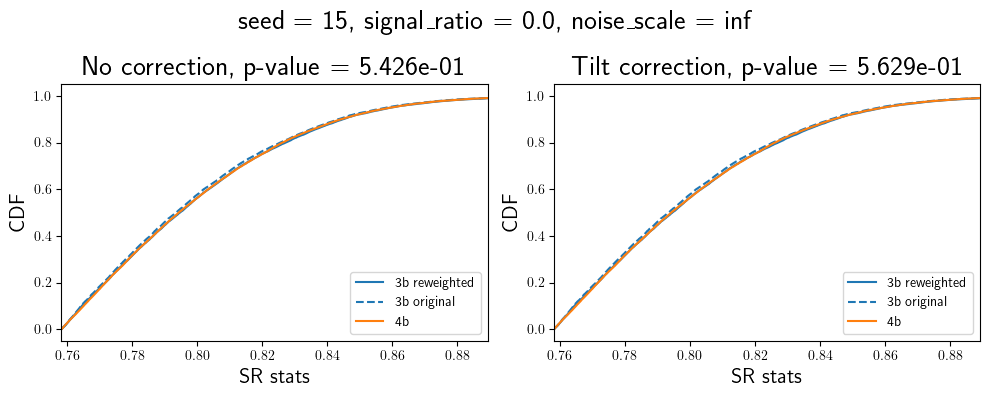

theta_max = 2.0990e+00
theta_min = -2.0990e+00
t = -0.4602554738521576, active_i = 7358, slopes[active_i] = -0.010170698165893555, i_left = 0, i_right = 27255
t = -0.4602554738521576, i_left = 7358, i_right = 27255, slopes[i_left] = -0.010170698165893555, slopes[i_right] = 0.014031141996383667, intercepts[i_left] = 0.002595923375338316, intercepts[i_right] = 0.006421869620680809
t = -0.1580849289894104, active_i = 26280, slopes[active_i] = 0.01396167278289795, i_left = 7358, i_right = 27255
t = -0.1580849289894104, i_left = 7358, i_right = 26280, slopes[i_left] = -0.010170698165893555, slopes[i_right] = 0.01396167278289795, intercepts[i_left] = 0.002595923375338316, intercepts[i_right] = 0.00821083877235651
t = -0.23267151415348053, active_i = 9290, slopes[active_i] = -0.007834449410438538, i_left = 7358, i_right = 26280
t = -0.23267151415348053, i_left = 9290, i_right = 26280, slopes[i_left] = -0.007834449410438538, slopes[i_right] = 0.01396167278289795, intercepts[i_left] = 0.0036003

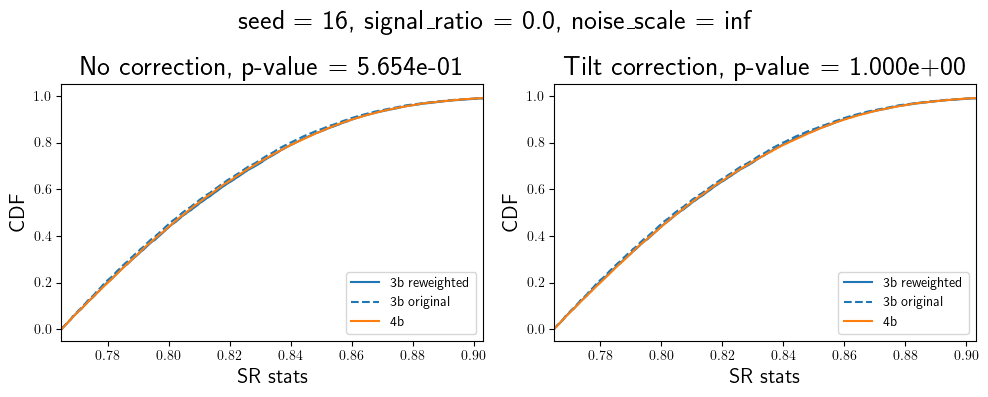

theta_max = 1.9316e+00
theta_min = -1.9316e+00
t = 0.0560896135866642, active_i = 21190, slopes[active_i] = 0.010357499122619629, i_left = 0, i_right = 26945
t = 0.0560896135866642, i_left = 0, i_right = 21190, slopes[i_left] = -0.012433081865310669, slopes[i_right] = 0.010357499122619629, intercepts[i_left] = 0.0006973667768761516, intercepts[i_right] = 0.0059813326224684715
t = -0.23184865713119507, active_i = 10131, slopes[active_i] = -0.005814932286739349, i_left = 0, i_right = 21190
t = -0.23184865713119507, i_left = 10131, i_right = 21190, slopes[i_left] = -0.005814932286739349, slopes[i_right] = 0.010357499122619629, intercepts[i_left] = 0.006404354702681303, intercepts[i_right] = 0.0059813326224684715
t = 0.026156987994909286, active_i = 10131, slopes[active_i] = -0.005814932286739349, i_left = 10131, i_right = 21190
Found minimum at t = 0.026156987994909286, iteration 2
Threshold: 1.4157e-02
Correction mode: exponential
theta = 2.6157e-02
max_diff_tilted = 6.3330e-03
p-value_t

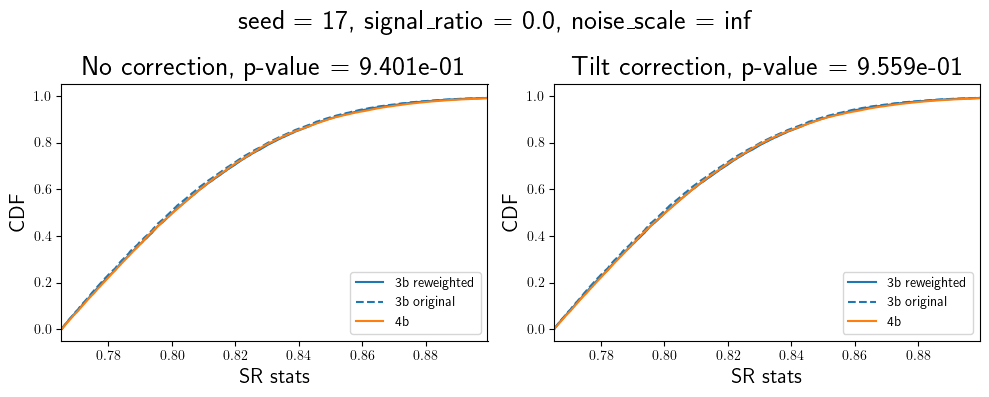

theta_max = 1.8007e+00
theta_min = -1.8007e+00
t = -0.3089790344238281, active_i = 10822, slopes[active_i] = -0.005281440913677216, i_left = 0, i_right = 26881
t = -0.3089790344238281, i_left = 10822, i_right = 26881, slopes[i_left] = -0.005281440913677216, slopes[i_right] = 0.014024198055267334, intercepts[i_left] = 0.0062552946619689465, intercepts[i_right] = 0.004321581684052944
t = 0.10016311705112457, active_i = 21739, slopes[active_i] = 0.01212167739868164, i_left = 10822, i_right = 26881
t = 0.10016311705112457, i_left = 10822, i_right = 21739, slopes[i_left] = -0.005281440913677216, slopes[i_right] = 0.01212167739868164, intercepts[i_left] = 0.0062552946619689465, intercepts[i_right] = 0.009556710720062256
t = -0.18970255553722382, active_i = 10822, slopes[active_i] = -0.005281440913677216, i_left = 10822, i_right = 21739
Found minimum at t = -0.18970255553722382, iteration 2
Threshold: 1.4195e-02
Correction mode: exponential
theta = -1.8970e-01
max_diff_tilted = 7.3476e-03
p-v

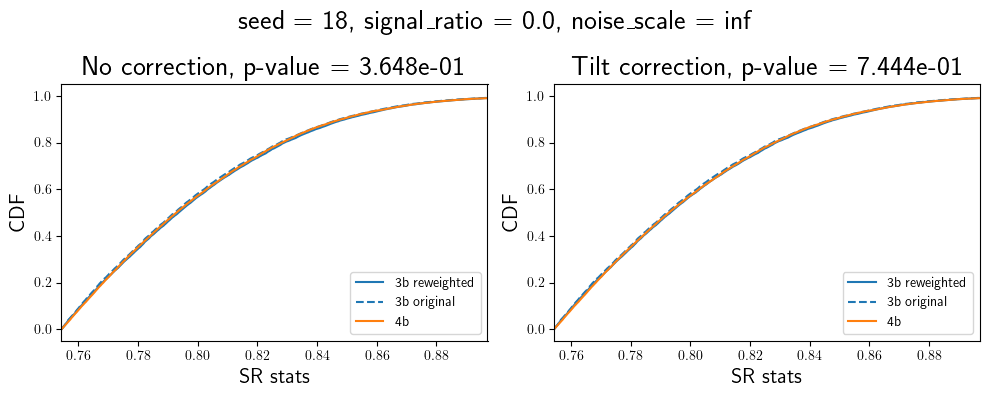

theta_max = 1.6529e+00
theta_min = -1.6529e+00
t = -0.7439240217208862, active_i = 7828, slopes[active_i] = -0.009281009435653687, i_left = 0, i_right = 26679
t = -0.7439240217208862, i_left = 7828, i_right = 26679, slopes[i_left] = -0.009281009435653687, slopes[i_right] = 0.013680100440979004, intercepts[i_left] = 0.002132982015609741, intercepts[i_right] = 0.010196441784501076
t = -0.35117900371551514, active_i = 26186, slopes[active_i] = 0.013663411140441895, i_left = 7828, i_right = 26679
t = -0.35117900371551514, i_left = 7828, i_right = 26186, slopes[i_left] = -0.009281009435653687, slopes[i_right] = 0.013663411140441895, intercepts[i_left] = 0.002132982015609741, intercepts[i_right] = 0.012035704217851162
t = -0.4315961003303528, active_i = 7828, slopes[active_i] = -0.009281009435653687, i_left = 7828, i_right = 26186
Found minimum at t = -0.4315961003303528, iteration 2
Threshold: 1.4252e-02
Correction mode: exponential
theta = -4.3160e-01
max_diff_tilted = 6.2246e-03
p-value_t

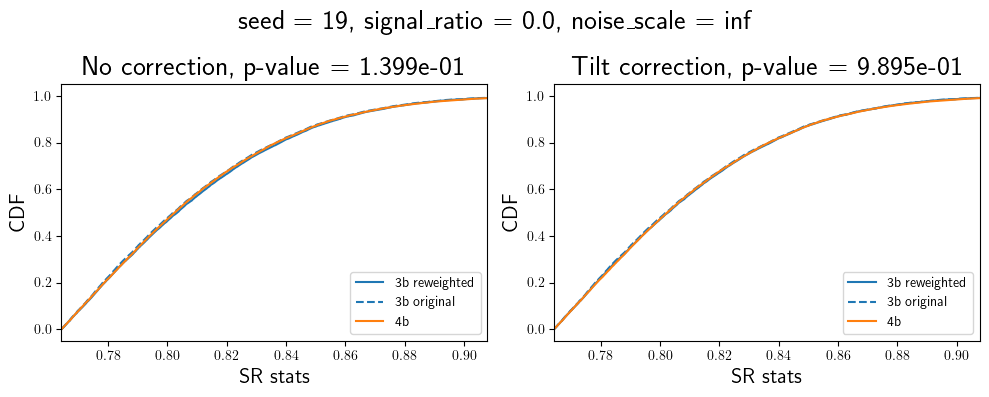

theta_max = 1.6533e+00
theta_min = -1.6533e+00
t = -0.4312911331653595, active_i = 3667, slopes[active_i] = -0.013915419578552246, i_left = 0, i_right = 26673
t = -0.4312911331653595, i_left = 3667, i_right = 26673, slopes[i_left] = -0.013915419578552246, slopes[i_right] = 0.014936715364456177, intercepts[i_left] = 0.0015565190697088838, intercepts[i_right] = 0.006394264288246632
t = -0.1676737368106842, active_i = 17668, slopes[active_i] = 0.008599340915679932, i_left = 3667, i_right = 26673
t = -0.1676737368106842, i_left = 3667, i_right = 17668, slopes[i_left] = -0.013915419578552246, slopes[i_right] = 0.008599340915679932, intercepts[i_left] = 0.0015565190697088838, intercepts[i_right] = 0.009707672521471977
t = -0.36203595995903015, active_i = 17668, slopes[active_i] = 0.008599340915679932, i_left = 3667, i_right = 17668
Found minimum at t = -0.36203595995903015, iteration 2
Threshold: 1.4286e-02
Correction mode: exponential
theta = -3.6204e-01
max_diff_tilted = 6.6693e-03
p-value

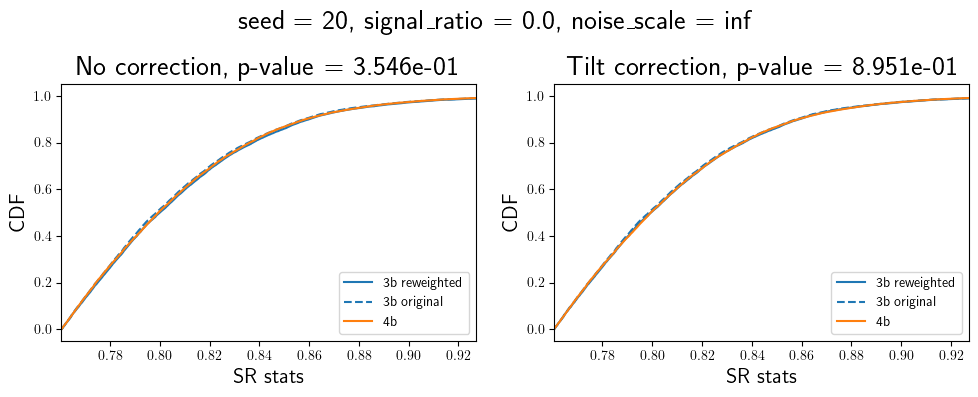

theta_max = 2.0350e+00
theta_min = -2.0350e+00
t = 0.11813527345657349, active_i = 21171, slopes[active_i] = 0.010646134614944458, i_left = 0, i_right = 26895
t = 0.11813527345657349, i_left = 0, i_right = 21171, slopes[i_left] = -0.012760818004608154, slopes[i_right] = 0.010646134614944458, intercepts[i_left] = 0.001527223503217101, intercepts[i_right] = 0.010546106845140457
t = -0.3853078782558441, active_i = 1772, slopes[active_i] = -0.01255941390991211, i_left = 0, i_right = 21171
t = -0.3853078782558441, i_left = 1772, i_right = 21171, slopes[i_left] = -0.01255941390991211, slopes[i_right] = 0.010646134614944458, intercepts[i_left] = 0.005400138441473246, intercepts[i_right] = 0.010546106845140457
t = -0.2217559516429901, active_i = 18723, slopes[active_i] = 0.008382126688957214, i_left = 1772, i_right = 21171
t = -0.2217559516429901, i_left = 1772, i_right = 18723, slopes[i_left] = -0.01255941390991211, slopes[i_right] = 0.008382126688957214, intercepts[i_left] = 0.00540013844147

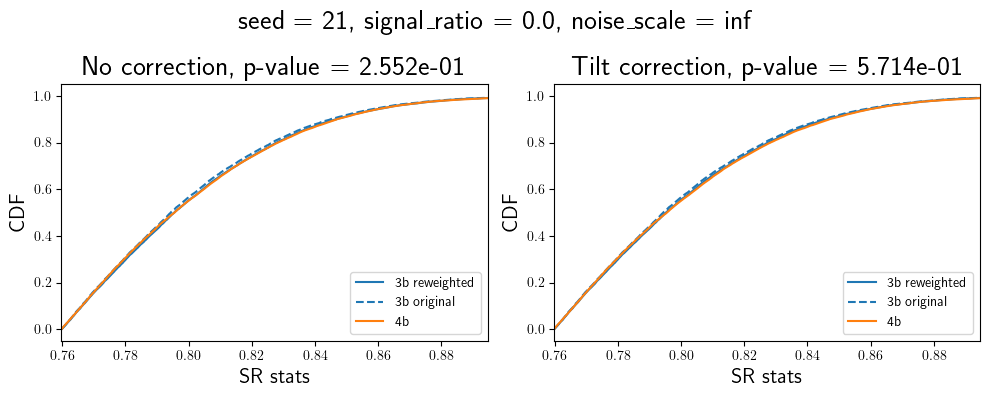

theta_max = 1.6236e+00
theta_min = -1.6236e+00
t = -0.5438095331192017, active_i = 7896, slopes[active_i] = -0.010870411992073059, i_left = 0, i_right = 27173
t = -0.5438095331192017, i_left = 7896, i_right = 27173, slopes[i_left] = -0.010870411992073059, slopes[i_right] = 0.01586267352104187, intercepts[i_left] = 0.0045593916438519955, intercepts[i_right] = 0.008610500954091549
t = -0.1515391618013382, active_i = 26225, slopes[active_i] = 0.01579764485359192, i_left = 7896, i_right = 27173
t = -0.1515391618013382, i_left = 7896, i_right = 26225, slopes[i_left] = -0.010870411992073059, slopes[i_right] = 0.01579764485359192, intercepts[i_left] = 0.0045593916438519955, intercepts[i_right] = 0.013099963776767254
t = -0.32025477290153503, active_i = 7896, slopes[active_i] = -0.010870411992073059, i_left = 7896, i_right = 26225
Found minimum at t = -0.32025477290153503, iteration 2
Threshold: 1.4144e-02
Correction mode: exponential
theta = -3.2025e-01
max_diff_tilted = 8.1272e-03
p-value_ti

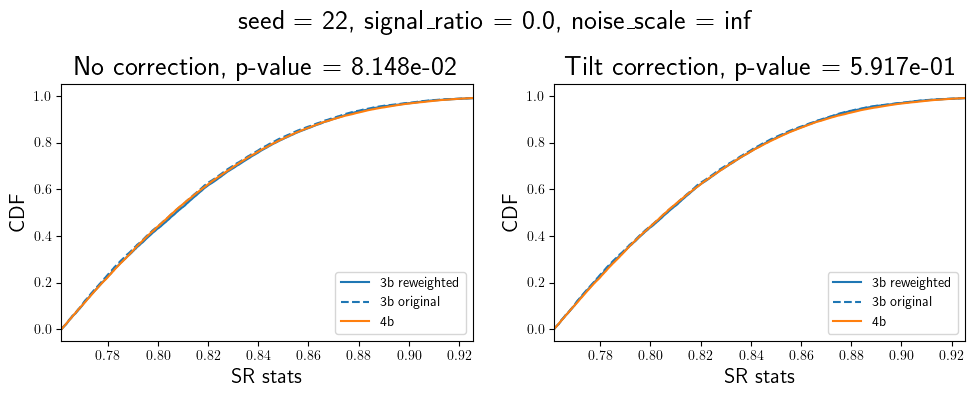

theta_max = 1.5559e+00
theta_min = -1.5559e+00
t = -1.1435985565185547, active_i = 5220, slopes[active_i] = -0.011349380016326904, i_left = 0, i_right = 27271
t = -1.1435985565185547, i_left = 5220, i_right = 27271, slopes[i_left] = -0.011349380016326904, slopes[i_right] = 0.013109356164932251, intercepts[i_left] = -0.006405388470739126, intercepts[i_right] = 0.015036583878099918
t = -0.8766590356826782, active_i = 23606, slopes[active_i] = 0.01224943995475769, i_left = 5220, i_right = 27271
t = -0.8766590356826782, i_left = 5220, i_right = 23606, slopes[i_left] = -0.011349380016326904, slopes[i_right] = 0.01224943995475769, intercepts[i_left] = -0.006405388470739126, intercepts[i_right] = 0.016372229903936386
t = -0.9652016162872314, active_i = 7860, slopes[active_i] = -0.009061872959136963, i_left = 5220, i_right = 23606
t = -0.9652016162872314, i_left = 7860, i_right = 23606, slopes[i_left] = -0.009061872959136963, slopes[i_right] = 0.01224943995475769, intercepts[i_left] = -0.00396

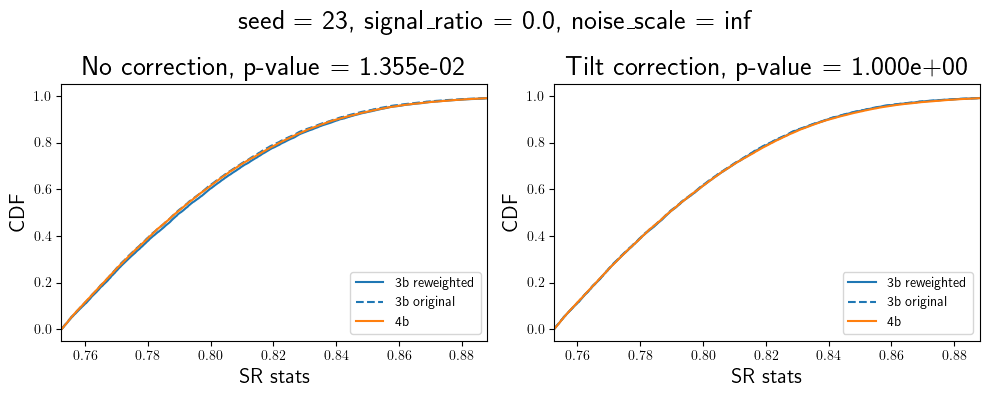

theta_max = 1.1794e+00
theta_min = -1.1794e+00
t = -0.3070642054080963, active_i = 5620, slopes[active_i] = -0.013093054294586182, i_left = 0, i_right = 27257
t = -0.3070642054080963, i_left = 5620, i_right = 27257, slopes[i_left] = -0.013093054294586182, slopes[i_right] = 0.01553642749786377, intercepts[i_left] = 0.001273451722227037, intercepts[i_right] = 0.004770680796355009
t = -0.12215480953454971, active_i = 19912, slopes[active_i] = 0.011333167552947998, i_left = 5620, i_right = 27257
t = -0.12215480953454971, i_left = 5620, i_right = 19912, slopes[i_left] = -0.013093054294586182, slopes[i_right] = 0.011333167552947998, intercepts[i_left] = 0.001273451722227037, intercepts[i_right] = 0.008703917264938354
t = -0.30420035123825073, active_i = 5620, slopes[active_i] = -0.013093054294586182, i_left = 5620, i_right = 19912
Found minimum at t = -0.30420035123825073, iteration 2
Threshold: 1.4156e-02
Correction mode: exponential
theta = -3.0420e-01
max_diff_tilted = 5.3526e-03
p-value_

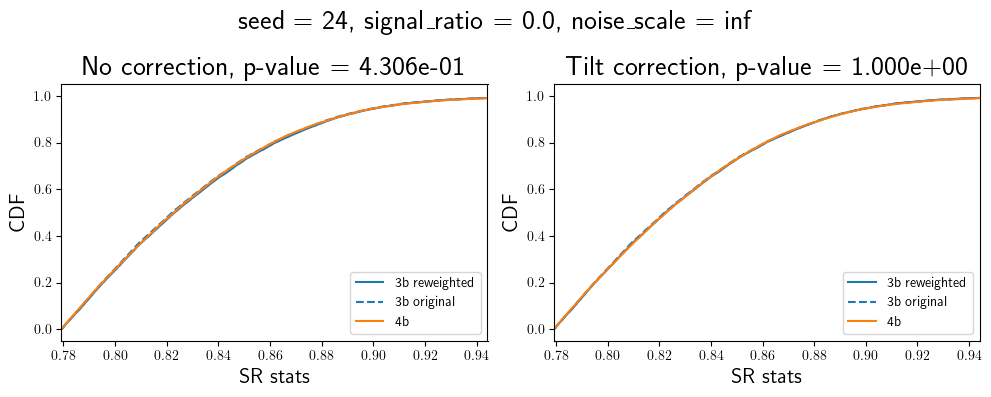

theta_max = 1.2832e+00
theta_min = -1.2832e+00
t = -0.38045182824134827, active_i = 7241, slopes[active_i] = -0.011670410633087158, i_left = 0, i_right = 27175
t = -0.38045182824134827, i_left = 7241, i_right = 27175, slopes[i_left] = -0.011670410633087158, slopes[i_right] = 0.01567944884300232, intercepts[i_left] = 0.005705553572624922, intercepts[i_right] = 0.0059652747586369514
t = -0.009496252983808517, active_i = 22154, slopes[active_i] = 0.013741374015808105, i_left = 7241, i_right = 27175
t = -0.009496252983808517, i_left = 7241, i_right = 22154, slopes[i_left] = -0.011670410633087158, slopes[i_right] = 0.013741374015808105, intercepts[i_left] = 0.005705553572624922, intercepts[i_right] = 0.01311766542494297
t = -0.29168009757995605, active_i = 7241, slopes[active_i] = -0.011670410633087158, i_left = 7241, i_right = 22154
Found minimum at t = -0.29168009757995605, iteration 2
Threshold: 1.4165e-02
Correction mode: exponential
theta = -2.9168e-01
max_diff_tilted = 9.1838e-03
p-va

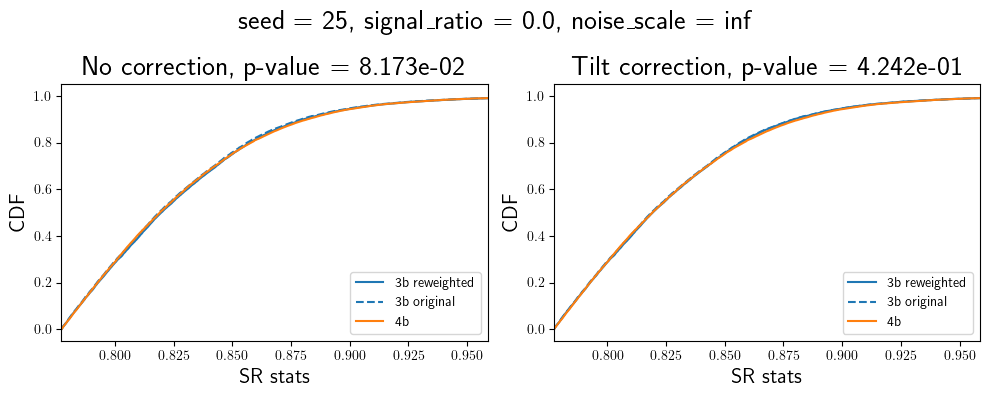

theta_max = 1.8631e+00
theta_min = -1.8631e+00
t = -0.1574939340353012, active_i = 24626, slopes[active_i] = 0.013874053955078125, i_left = 0, i_right = 26995
t = -0.1574939340353012, i_left = 0, i_right = 24626, slopes[i_left] = -0.014301449060440063, slopes[i_right] = 0.013874053955078125, intercepts[i_left] = -0.002252391539514065, intercepts[i_right] = 0.00873583648353815
t = -0.38999226689338684, active_i = 4953, slopes[active_i] = -0.012473046779632568, i_left = 0, i_right = 24626
t = -0.38999226689338684, i_left = 4953, i_right = 24626, slopes[i_left] = -0.012473046779632568, slopes[i_right] = 0.013874053955078125, intercepts[i_left] = 0.0018861221615225077, intercepts[i_right] = 0.00873583648353815
t = -0.25997981429100037, active_i = 15275, slopes[active_i] = 0.0038705095648765564, i_left = 4953, i_right = 24626
t = -0.25997981429100037, i_left = 4953, i_right = 15275, slopes[i_left] = -0.012473046779632568, slopes[i_right] = 0.0038705095648765564, intercepts[i_left] = 0.00188

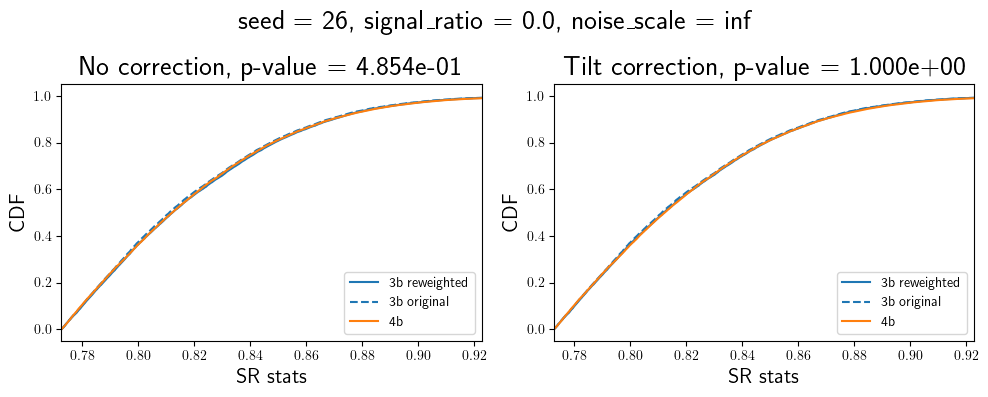

theta_max = 1.5797e+00
theta_min = -1.5797e+00
t = -0.13448300957679749, active_i = 9493, slopes[active_i] = -0.008070528507232666, i_left = 0, i_right = 27119
t = -0.13448300957679749, i_left = 9493, i_right = 27119, slopes[i_left] = -0.008070528507232666, slopes[i_right] = 0.015030592679977417, intercepts[i_left] = 0.004604882560670376, intercepts[i_right] = 0.0020213592797517776
t = 0.11183540523052216, active_i = 23071, slopes[active_i] = 0.013804912567138672, i_left = 9493, i_right = 27119
t = 0.11183540523052216, i_left = 9493, i_right = 23071, slopes[i_left] = -0.008070528507232666, slopes[i_right] = 0.013804912567138672, intercepts[i_left] = 0.004604882560670376, intercepts[i_right] = 0.005968649405986071
t = -0.06234237179160118, active_i = 9493, slopes[active_i] = -0.008070528507232666, i_left = 9493, i_right = 23071
Found minimum at t = -0.06234237179160118, iteration 2
Threshold: 1.4169e-02
Correction mode: exponential
theta = -6.2342e-02
max_diff_tilted = 5.1860e-03
p-valu

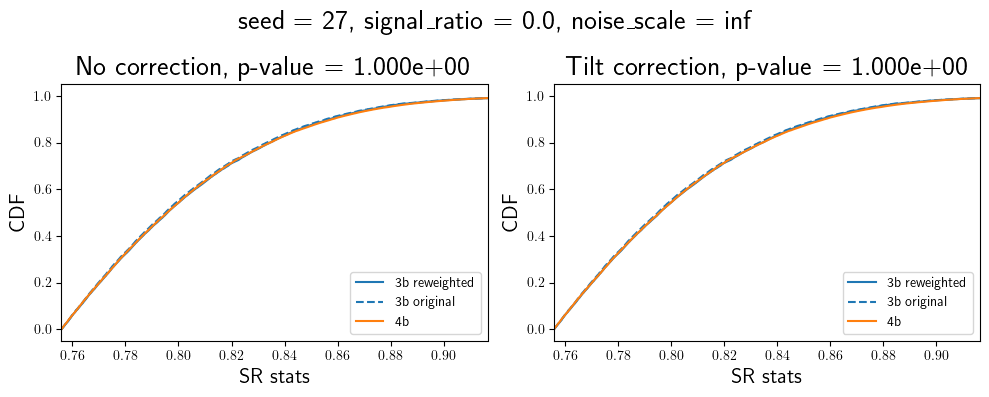

theta_max = 1.7436e+00
theta_min = -1.7436e+00
t = 0.07270466536283493, active_i = 6026, slopes[active_i] = -0.012105822563171387, i_left = 0, i_right = 27105
t = 0.07270466536283493, i_left = 6026, i_right = 27105, slopes[i_left] = -0.012105822563171387, slopes[i_right] = 0.014843076467514038, intercepts[i_left] = 0.01184781827032566, intercepts[i_right] = -0.0011378758354112506
t = 0.4818636178970337, active_i = 26816, slopes[active_i] = 0.014837205410003662, i_left = 6026, i_right = 27105
t = 0.4818636178970337, i_left = 6026, i_right = 26816, slopes[i_left] = -0.012105822563171387, slopes[i_right] = 0.014837205410003662, intercepts[i_left] = 0.01184781827032566, intercepts[i_right] = 0.00012947499635629356
t = 0.4349304437637329, active_i = 7907, slopes[active_i] = -0.010095342993736267, i_left = 6026, i_right = 26816
t = 0.4349304437637329, i_left = 7907, i_right = 26816, slopes[i_left] = -0.010095342993736267, slopes[i_right] = 0.014837205410003662, intercepts[i_left] = 0.0111269

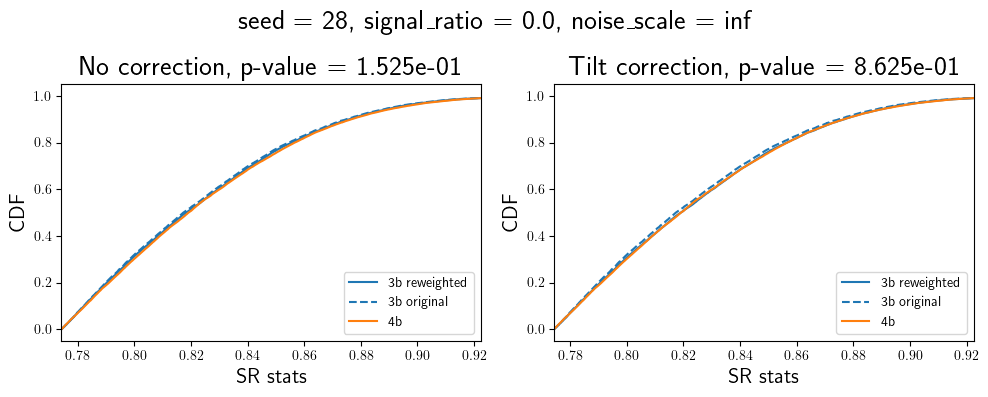

theta_max = 1.4114e+00
theta_min = -1.4114e+00
t = 0.15801559388637543, active_i = 8920, slopes[active_i] = -0.009706944227218628, i_left = 0, i_right = 27191
t = 0.15801559388637543, i_left = 8920, i_right = 27191, slopes[i_left] = -0.009706944227218628, slopes[i_right] = 0.016340136528015137, intercepts[i_left] = 0.009032743982970715, intercepts[i_right] = -0.0025814156979322433
t = 0.44589102268218994, active_i = 23446, slopes[active_i] = 0.015185832977294922, i_left = 8920, i_right = 27191
t = 0.44589102268218994, i_left = 8920, i_right = 23446, slopes[i_left] = -0.009706944227218628, slopes[i_right] = 0.015185832977294922, intercepts[i_left] = 0.009032743982970715, intercepts[i_right] = 0.0006576762534677982
t = 0.336445689201355, active_i = 8920, slopes[active_i] = -0.009706944227218628, i_left = 8920, i_right = 23446
Found minimum at t = 0.336445689201355, iteration 2
Threshold: 1.4163e-02
Correction mode: exponential
theta = 3.3645e-01
max_diff_tilted = 5.8720e-03
p-value_tilte

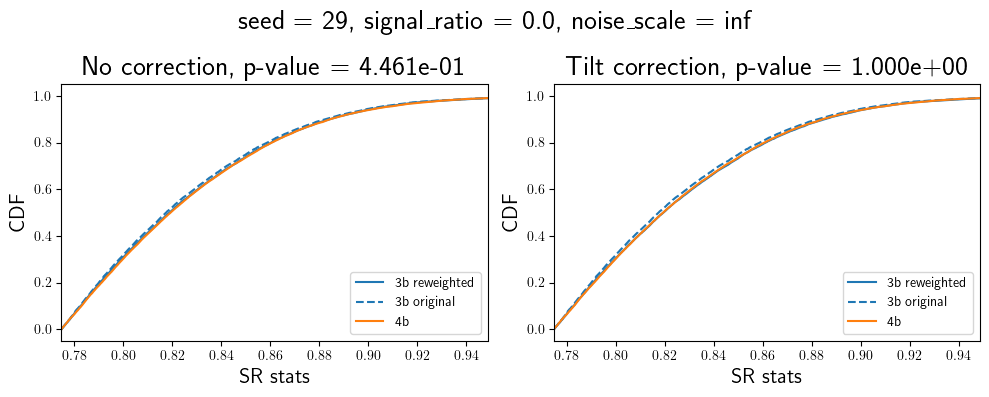

theta_max = 1.0934e+00
theta_min = -1.0934e+00
t = -0.1082756444811821, active_i = 11333, slopes[active_i] = -0.004884630441665649, i_left = 0, i_right = 27275
t = -0.1082756444811821, i_left = 11333, i_right = 27275, slopes[i_left] = -0.004884630441665649, slopes[i_right] = 0.014187425374984741, intercepts[i_left] = 0.004104029852896929, intercepts[i_right] = 0.0015405036974698305
t = 0.13441267609596252, active_i = 21893, slopes[active_i] = 0.0121917724609375, i_left = 11333, i_right = 27275
t = 0.13441267609596252, i_left = 11333, i_right = 21893, slopes[i_left] = -0.004884630441665649, slopes[i_right] = 0.0121917724609375, intercepts[i_left] = 0.004104029852896929, intercepts[i_right] = 0.005543147679418325
t = -0.08427523076534271, active_i = 11333, slopes[active_i] = -0.004884630441665649, i_left = 11333, i_right = 21893
Found minimum at t = -0.08427523076534271, iteration 2
Threshold: 1.4127e-02
Correction mode: exponential
theta = -8.4275e-02
max_diff_tilted = 4.5808e-03
p-valu

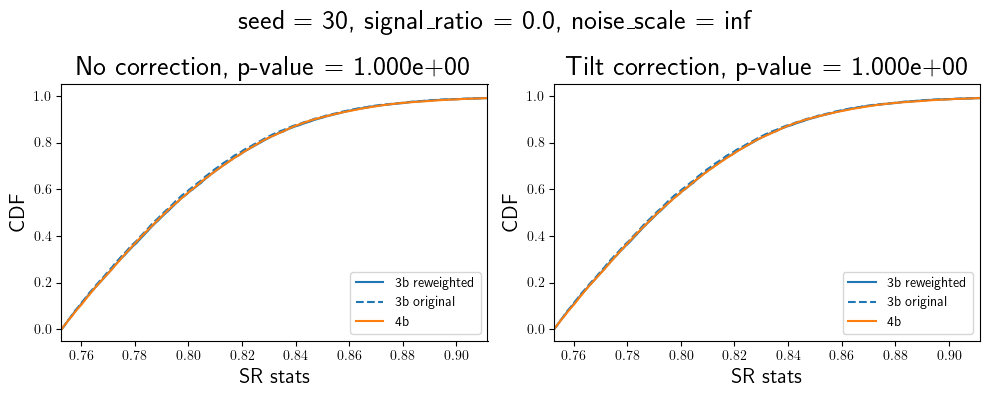

theta_max = 1.2154e+00
theta_min = -1.2154e+00
t = -0.8915020227432251, active_i = 3529, slopes[active_i] = -0.013035595417022705, i_left = 0, i_right = 27145
t = -0.8915020227432251, i_left = 3529, i_right = 27145, slopes[i_left] = -0.013035595417022705, slopes[i_right] = 0.01389285922050476, intercepts[i_left] = -0.0017556337406858802, intercepts[i_right] = 0.01238551177084446
t = -0.5251376628875732, active_i = 22837, slopes[active_i] = 0.01261630654335022, i_left = 3529, i_right = 27145
t = -0.5251376628875732, i_left = 3529, i_right = 22837, slopes[i_left] = -0.013035595417022705, slopes[i_right] = 0.01261630654335022, intercepts[i_left] = -0.0017556337406858802, intercepts[i_right] = 0.015797195956110954
t = -0.6842701435089111, active_i = 3529, slopes[active_i] = -0.013035595417022705, i_left = 3529, i_right = 22837
Found minimum at t = -0.6842701435089111, iteration 2
Threshold: 1.4144e-02
Correction mode: exponential
theta = -6.8427e-01
max_diff_tilted = 7.2486e-03
p-value_til

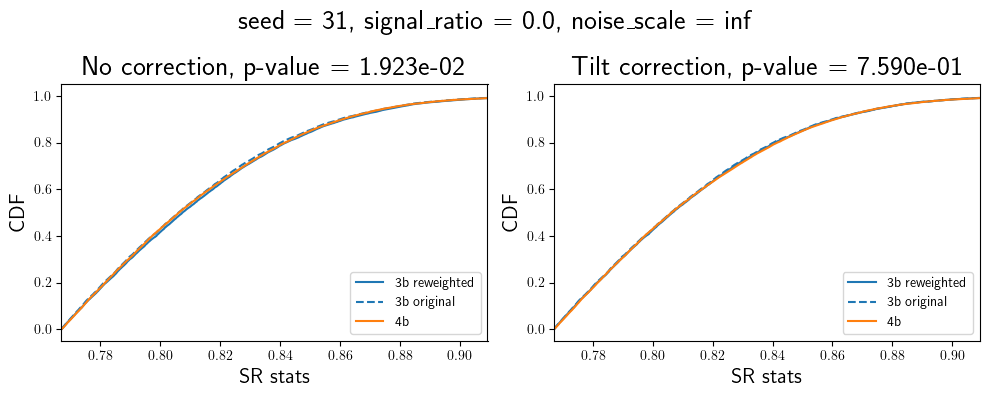

theta_max = 1.6757e+00
theta_min = -1.6757e+00
t = -0.7303697466850281, active_i = 8334, slopes[active_i] = -0.008484184741973877, i_left = 0, i_right = 27513
t = -0.7303697466850281, i_left = 8334, i_right = 27513, slopes[i_left] = -0.008484184741973877, slopes[i_right] = 0.012969821691513062, intercepts[i_left] = 0.0064977179281413555, intercepts[i_right] = 0.009502303786575794
t = -0.14004777371883392, active_i = 26874, slopes[active_i] = 0.012943416833877563, i_left = 8334, i_right = 27513
t = -0.14004777371883392, i_left = 8334, i_right = 26874, slopes[i_left] = -0.008484184741973877, slopes[i_right] = 0.012943416833877563, intercepts[i_left] = 0.0064977179281413555, intercepts[i_right] = 0.009614611975848675
t = -0.14546163380146027, active_i = 8334, slopes[active_i] = -0.008484184741973877, i_left = 8334, i_right = 26874
Found minimum at t = -0.14546163380146027, iteration 2
Threshold: 1.4084e-02
Correction mode: exponential
theta = -1.4546e-01
max_diff_tilted = 7.7959e-03
p-val

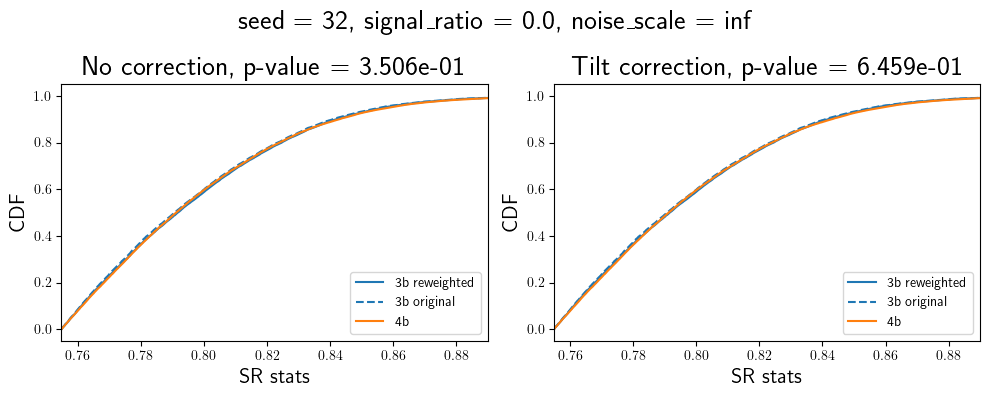

theta_max = 9.0272e-01
theta_min = -9.0272e-01
t = 0.006256339140236378, active_i = 2830, slopes[active_i] = -0.0151042640209198, i_left = 0, i_right = 26985
t = 0.006256339140236378, i_left = 2830, i_right = 26985, slopes[i_left] = -0.0151042640209198, slopes[i_right] = 0.015750616788864136, intercepts[i_left] = 0.006746198516339064, intercepts[i_right] = -9.85411970759742e-05
t = 0.22183653712272644, active_i = 21009, slopes[active_i] = 0.012871861457824707, i_left = 2830, i_right = 26985
t = 0.22183653712272644, i_left = 2830, i_right = 21009, slopes[i_left] = -0.0151042640209198, slopes[i_right] = 0.012871861457824707, intercepts[i_left] = 0.006746198516339064, intercepts[i_right] = 0.005648445338010788
t = 0.039238929748535156, active_i = 2830, slopes[active_i] = -0.0151042640209198, i_left = 2830, i_right = 21009
Found minimum at t = 0.039238929748535156, iteration 2
Threshold: 1.4211e-02
Correction mode: exponential
theta = 3.9239e-02
max_diff_tilted = 6.2333e-03
p-value_tilted 

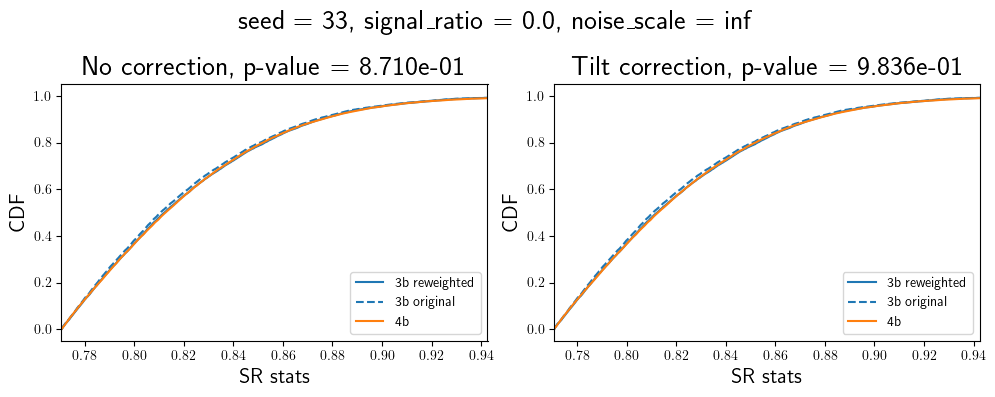

theta_max = 1.5624e+00
theta_min = -1.5624e+00
t = 0.144644096493721, active_i = 20643, slopes[active_i] = 0.011606544256210327, i_left = 0, i_right = 27167
t = 0.144644096493721, i_left = 0, i_right = 20643, slopes[i_left] = -0.0147610604763031, slopes[i_right] = 0.011606544256210327, intercepts[i_left] = 0.00219911546446383, intercepts[i_right] = 0.006254733540117741
t = -0.15381065011024475, active_i = 622, slopes[active_i] = -0.014731496572494507, i_left = 0, i_right = 20643
t = -0.15381065011024475, i_left = 622, i_right = 20643, slopes[i_left] = -0.014731496572494507, slopes[i_right] = 0.011606544256210327, intercepts[i_left] = 0.003995283506810665, intercepts[i_right] = 0.006254733540117741
t = -0.08578656613826752, active_i = 622, slopes[active_i] = -0.014731496572494507, i_left = 622, i_right = 20643
Found minimum at t = -0.08578656613826752, iteration 2
Threshold: 1.4182e-02
Correction mode: exponential
theta = -8.5787e-02
max_diff_tilted = 5.3341e-03
p-value_tilted = 1.0000e

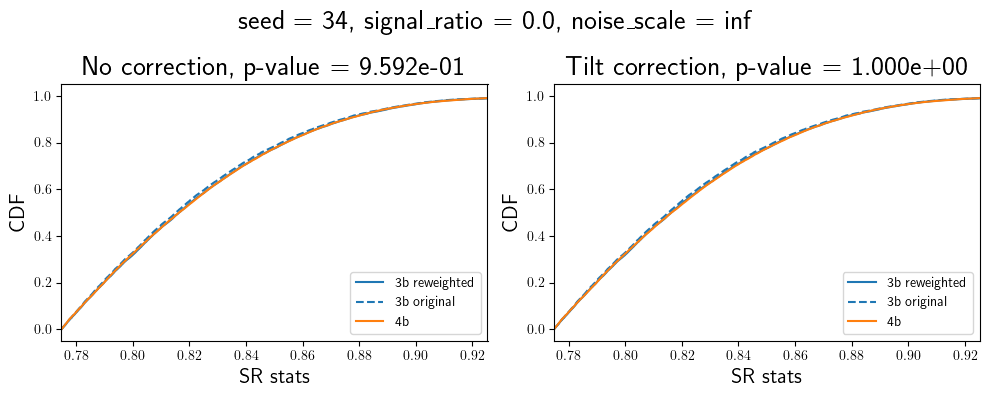

theta_max = 2.0035e+00
theta_min = -2.0035e+00
t = -0.6107162237167358, active_i = 10477, slopes[active_i] = -0.005706310272216797, i_left = 0, i_right = 27181
t = -0.6107162237167358, i_left = 10477, i_right = 27181, slopes[i_left] = -0.005706310272216797, slopes[i_right] = 0.0131683349609375, intercepts[i_left] = 0.006519864778965712, intercepts[i_right] = 0.008130734786391258
t = -0.08534570783376694, active_i = 25639, slopes[active_i] = 0.013017028570175171, i_left = 10477, i_right = 27181
t = -0.08534570783376694, i_left = 10477, i_right = 25639, slopes[i_left] = -0.005706310272216797, slopes[i_right] = 0.013017028570175171, intercepts[i_left] = 0.006519864778965712, intercepts[i_right] = 0.013785387389361858
t = -0.3880463242530823, active_i = 10477, slopes[active_i] = -0.005706310272216797, i_left = 10477, i_right = 25639
Found minimum at t = -0.3880463242530823, iteration 2
Threshold: 1.4136e-02
Correction mode: exponential
theta = -3.8805e-01
max_diff_tilted = 8.8271e-03
p-val

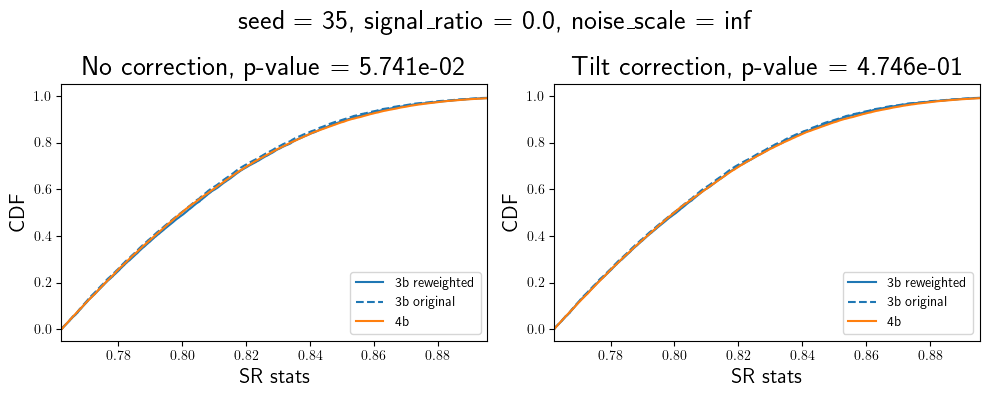

theta_max = 1.7982e+00
theta_min = -1.7982e+00
t = 0.49506819248199463, active_i = 9212, slopes[active_i] = -0.008065953850746155, i_left = 0, i_right = 27005
t = 0.49506819248199463, i_left = 9212, i_right = 27005, slopes[i_left] = -0.008065953850746155, slopes[i_right] = 0.014402657747268677, intercepts[i_left] = 0.011822217144072056, intercepts[i_right] = -0.0071302978321909904
t = 0.8435107469558716, active_i = 24538, slopes[active_i] = 0.013970941305160522, i_left = 9212, i_right = 27005
t = 0.8435107469558716, i_left = 9212, i_right = 24538, slopes[i_left] = -0.008065953850746155, slopes[i_right] = 0.013970941305160522, intercepts[i_left] = 0.011822217144072056, intercepts[i_right] = -0.0003300366806797683
t = 0.5514503717422485, active_i = 24538, slopes[active_i] = 0.013970941305160522, i_left = 9212, i_right = 24538
Found minimum at t = 0.5514503717422485, iteration 2
Threshold: 1.4192e-02
Correction mode: exponential
theta = 5.5145e-01
max_diff_tilted = 7.4660e-03
p-value_tilt

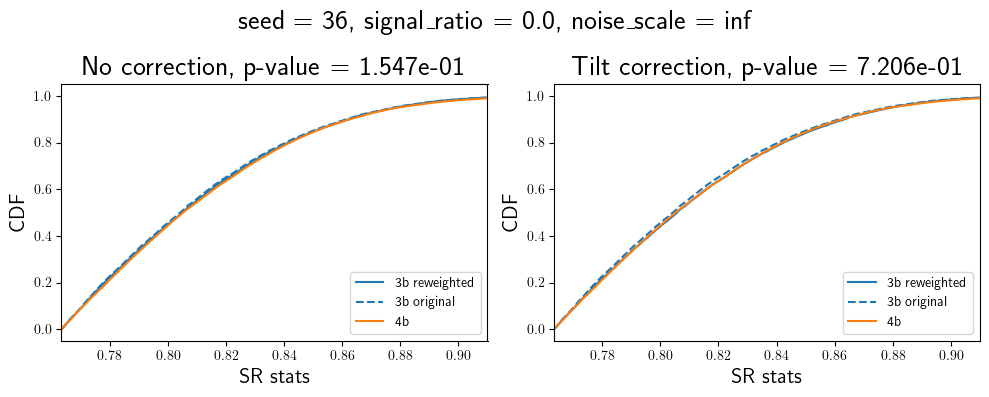

theta_max = 1.7443e+00
theta_min = -1.7443e+00
t = -0.6227784156799316, active_i = 3628, slopes[active_i] = -0.013325154781341553, i_left = 0, i_right = 27389
t = -0.6227784156799316, i_left = 3628, i_right = 27389, slopes[i_left] = -0.013325154781341553, slopes[i_right] = 0.014226078987121582, intercepts[i_left] = -0.0020804826635867357, intercepts[i_right] = 0.008859694935381413
t = -0.3970848321914673, active_i = 18006, slopes[active_i] = 0.007990360260009766, i_left = 3628, i_right = 27389
t = -0.3970848321914673, i_left = 3628, i_right = 18006, slopes[i_left] = -0.013325154781341553, slopes[i_right] = 0.007990360260009766, intercepts[i_left] = -0.0020804826635867357, intercepts[i_right] = 0.009526190347969532
t = -0.5445175766944885, active_i = 7719, slopes[active_i] = -0.010052740573883057, i_left = 3628, i_right = 18006
t = -0.5445175766944885, i_left = 7719, i_right = 18006, slopes[i_left] = -0.010052740573883057, slopes[i_right] = 0.007990360260009766, intercepts[i_left] = -0.

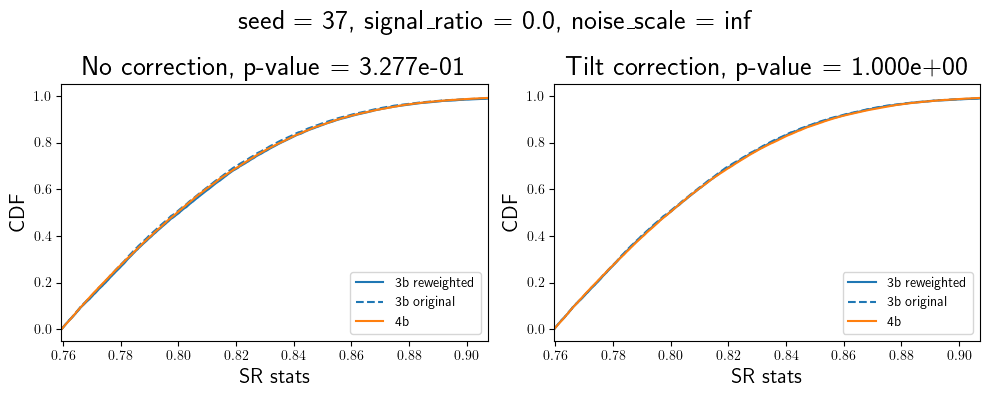

theta_max = 1.4388e+00
theta_min = -1.4388e+00
t = -0.1657433956861496, active_i = 10302, slopes[active_i] = -0.007177114486694336, i_left = 0, i_right = 27291
t = -0.1657433956861496, i_left = 10302, i_right = 27291, slopes[i_left] = -0.007177114486694336, slopes[i_right] = 0.015535622835159302, intercepts[i_left] = 0.0065126195549964905, intercepts[i_right] = 0.0026625245809555054
t = 0.1695125848054886, active_i = 25872, slopes[active_i] = 0.015384882688522339, i_left = 10302, i_right = 27291
t = 0.1695125848054886, i_left = 10302, i_right = 25872, slopes[i_left] = -0.007177114486694336, slopes[i_right] = 0.015384882688522339, intercepts[i_left] = 0.0065126195549964905, intercepts[i_right] = 0.006556088570505381
t = -0.001926647499203682, active_i = 10302, slopes[active_i] = -0.007177114486694336, i_left = 10302, i_right = 25872
Found minimum at t = -0.001926647499203682, iteration 2
Threshold: 1.4157e-02
Correction mode: exponential
theta = -1.9266e-03
max_diff_tilted = 6.5899e-03


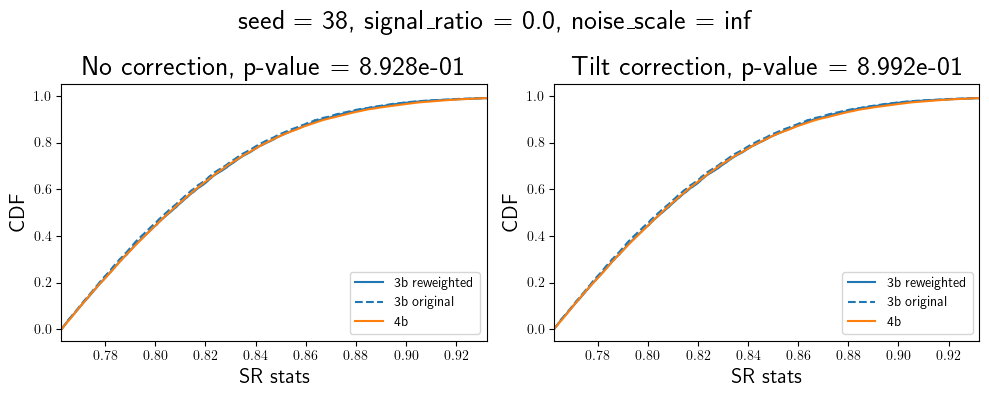

theta_max = 1.5944e+00
theta_min = -1.5944e+00
t = 0.4290712773799896, active_i = 2676, slopes[active_i] = -0.013786524534225464, i_left = 0, i_right = 27083
t = 0.4290712773799896, i_left = 2676, i_right = 27083, slopes[i_left] = -0.013786524534225464, slopes[i_right] = 0.014306366443634033, intercepts[i_left] = 0.011774246580898762, intercepts[i_right] = -0.0061384509317576885
t = 0.6376238465309143, active_i = 25075, slopes[active_i] = 0.014014124870300293, i_left = 2676, i_right = 27083
t = 0.6376238465309143, i_left = 2676, i_right = 25075, slopes[i_left] = -0.013786524534225464, slopes[i_right] = 0.014014124870300293, intercepts[i_left] = 0.011774246580898762, intercepts[i_right] = -0.0015386072918772697
t = 0.4788684546947479, active_i = 2676, slopes[active_i] = -0.013786524534225464, i_left = 2676, i_right = 25075
Found minimum at t = 0.4788684546947479, iteration 2
Threshold: 1.4186e-02
Correction mode: exponential
theta = 4.7887e-01
max_diff_tilted = 5.2799e-03
p-value_tilted

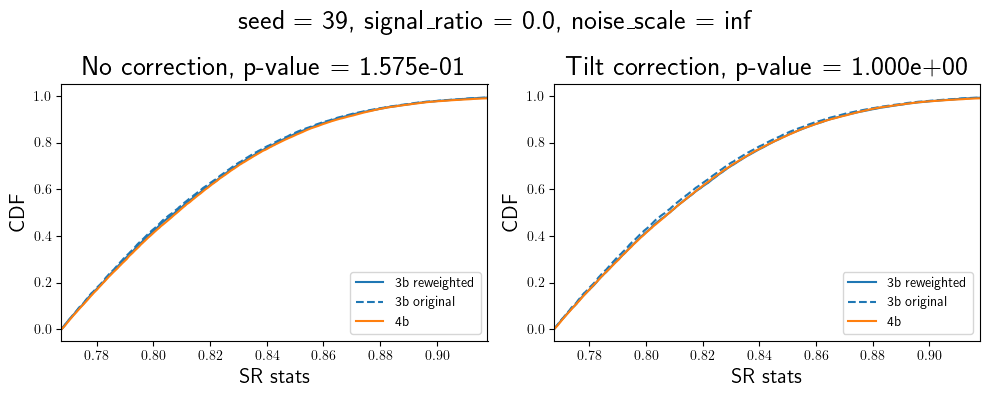

theta_max = 1.5065e+00
theta_min = -1.5065e+00
t = -0.1591230183839798, active_i = 10061, slopes[active_i] = -0.007934913039207458, i_left = 0, i_right = 27323
t = -0.1591230183839798, i_left = 10061, i_right = 27323, slopes[i_left] = -0.007934913039207458, slopes[i_right] = 0.016425877809524536, intercepts[i_left] = 0.0053140525706112385, intercepts[i_right] = 0.0026137351524084806
t = 0.1108468696475029, active_i = 22619, slopes[active_i] = 0.014615416526794434, i_left = 10061, i_right = 27323
t = 0.1108468696475029, i_left = 10061, i_right = 22619, slopes[i_left] = -0.007934913039207458, slopes[i_right] = 0.014615416526794434, intercepts[i_left] = 0.0053140525706112385, intercepts[i_right] = 0.006414353381842375
t = -0.048793114721775055, active_i = 10061, slopes[active_i] = -0.007934913039207458, i_left = 10061, i_right = 22619
Found minimum at t = -0.048793114721775055, iteration 2
Threshold: 1.4120e-02
Correction mode: exponential
theta = -4.8793e-02
max_diff_tilted = 5.7712e-03


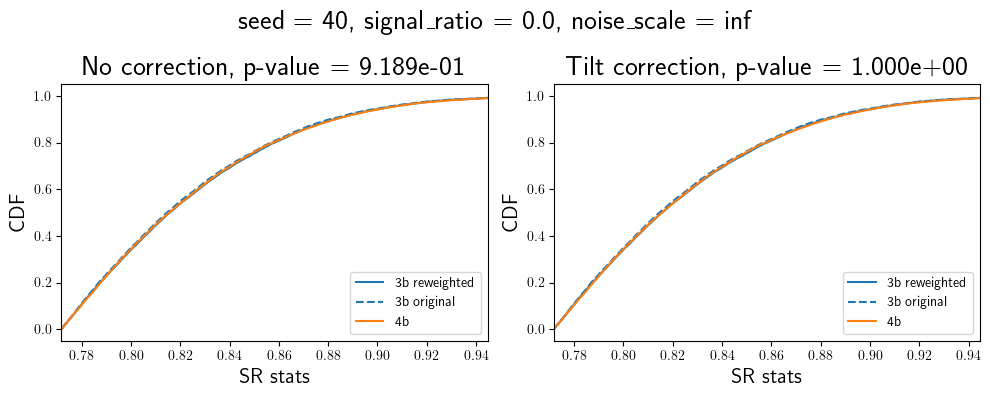

theta_max = 5.4431e-01
theta_min = -5.4431e-01
t = -0.6727105975151062, active_i = 3169, slopes[active_i] = -0.013426661491394043, i_left = 0, i_right = 27317
t = -0.6727105975151062, i_left = 3169, i_right = 27317, slopes[i_left] = -0.013426661491394043, slopes[i_right] = 0.014097988605499268, intercepts[i_left] = 0.0004842159105464816, intercepts[i_right] = 0.00948841031640768
t = -0.3271320164203644, active_i = 26448, slopes[active_i] = 0.014050036668777466, i_left = 3169, i_right = 27317
t = -0.3271320164203644, i_left = 3169, i_right = 26448, slopes[i_left] = -0.013426661491394043, slopes[i_right] = 0.014050036668777466, intercepts[i_left] = 0.0004842159105464816, intercepts[i_right] = 0.013817285187542439
t = -0.4852500557899475, active_i = 3596, slopes[active_i] = -0.013228178024291992, i_left = 3169, i_right = 26448
t = -0.4852500557899475, i_left = 3596, i_right = 26448, slopes[i_left] = -0.013228178024291992, slopes[i_right] = 0.014050036668777466, intercepts[i_left] = 0.0006

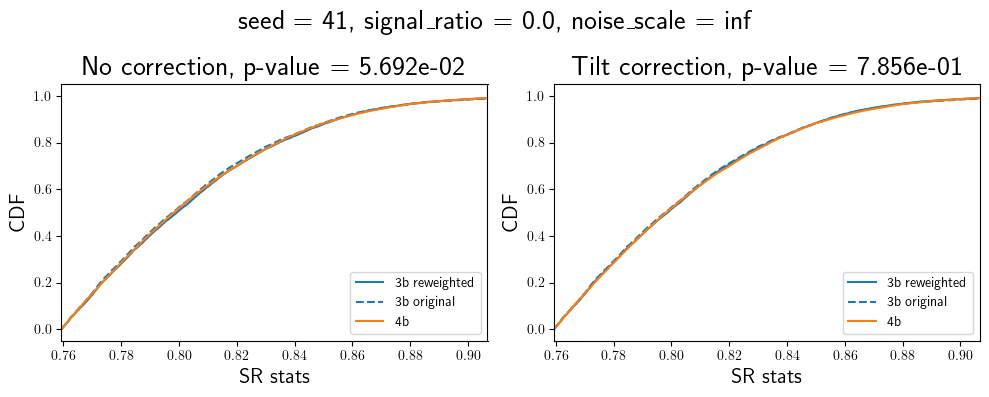

theta_max = 1.6430e+00
theta_min = -1.6430e+00
t = 0.15668773651123047, active_i = 16227, slopes[active_i] = 0.005224309861660004, i_left = 0, i_right = 26909
t = 0.15668773651123047, i_left = 0, i_right = 16227, slopes[i_left] = -0.013127386569976807, slopes[i_right] = 0.005224309861660004, intercepts[i_left] = 0.0020968327298760414, intercepts[i_right] = 0.00743804732337594
t = -0.29104745388031006, active_i = 8640, slopes[active_i] = -0.008045732975006104, i_left = 0, i_right = 16227
t = -0.29104745388031006, i_left = 8640, i_right = 16227, slopes[i_left] = -0.008045732975006104, slopes[i_right] = 0.005224309861660004, intercepts[i_left] = 0.008990366943180561, intercepts[i_right] = 0.00743804732337594
t = 0.11697924882173538, active_i = 8922, slopes[active_i] = -0.007699191570281982, i_left = 8640, i_right = 16227
t = 0.11697924882173538, i_left = 8922, i_right = 16227, slopes[i_left] = -0.007699191570281982, slopes[i_right] = 0.005224309861660004, intercepts[i_left] = 0.0089682340

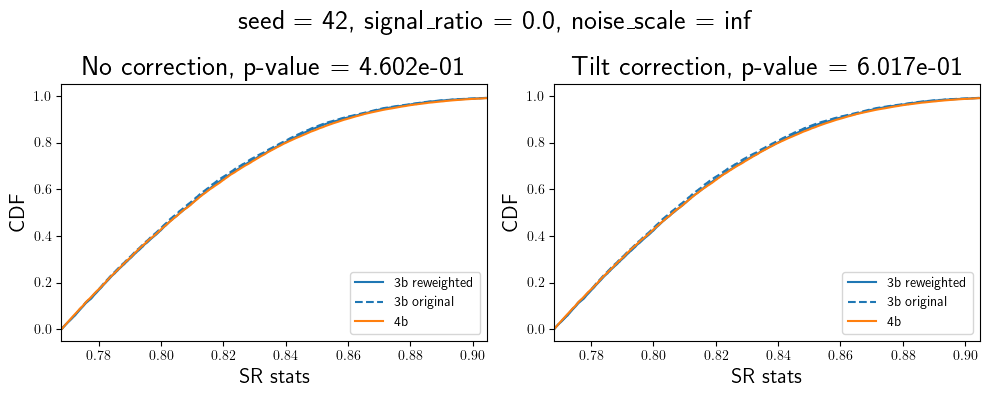

theta_max = 1.4040e+00
theta_min = -1.4040e+00
t = 0.16165511310100555, active_i = 2881, slopes[active_i] = -0.014689594507217407, i_left = 0, i_right = 26569
t = 0.16165511310100555, i_left = 2881, i_right = 26569, slopes[i_left] = -0.014689594507217407, slopes[i_right] = 0.015389412641525269, intercepts[i_left] = 0.01306140422821045, intercepts[i_right] = -0.002504875650629401
t = 0.51751309633255, active_i = 22375, slopes[active_i] = 0.013923406600952148, i_left = 2881, i_right = 26569
t = 0.51751309633255, i_left = 2881, i_right = 22375, slopes[i_left] = -0.014689594507217407, slopes[i_right] = 0.013923406600952148, intercepts[i_left] = 0.01306140422821045, intercepts[i_right] = 0.002643291372805834
t = 0.36410418152809143, active_i = 22375, slopes[active_i] = 0.013923406600952148, i_left = 2881, i_right = 22375
Found minimum at t = 0.36410418152809143, iteration 2
Threshold: 1.4281e-02
Correction mode: exponential
theta = 3.6410e-01
max_diff_tilted = 7.8240e-03
p-value_tilted = 6.

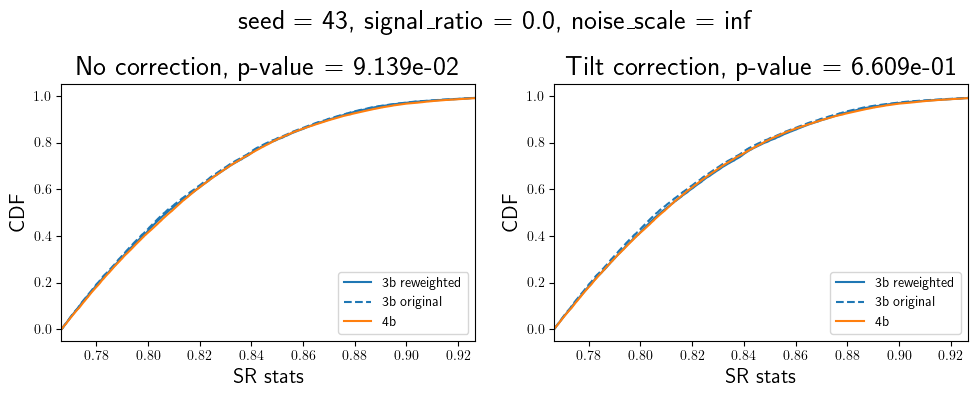

theta_max = 1.5372e+00
theta_min = -1.5372e+00
t = 0.1296355426311493, active_i = 21342, slopes[active_i] = 0.01209840178489685, i_left = 0, i_right = 27125
t = 0.1296355426311493, i_left = 0, i_right = 21342, slopes[i_left] = -0.0145510733127594, slopes[i_right] = 0.01209840178489685, intercepts[i_left] = 0.0018679607892408967, intercepts[i_right] = 0.008244385942816734
t = -0.2392701953649521, active_i = 8631, slopes[active_i] = -0.009034931659698486, i_left = 0, i_right = 21342
t = -0.2392701953649521, i_left = 8631, i_right = 21342, slopes[i_left] = -0.009034931659698486, slopes[i_right] = 0.01209840178489685, intercepts[i_left] = 0.00874405913054943, intercepts[i_right] = 0.008244385942816734
t = 0.023643841966986656, active_i = 8631, slopes[active_i] = -0.009034931659698486, i_left = 8631, i_right = 21342
Found minimum at t = 0.023643841966986656, iteration 2
Threshold: 1.4159e-02
Correction mode: exponential
theta = 2.3644e-02
max_diff_tilted = 8.6002e-03
p-value_tilted = 5.1287

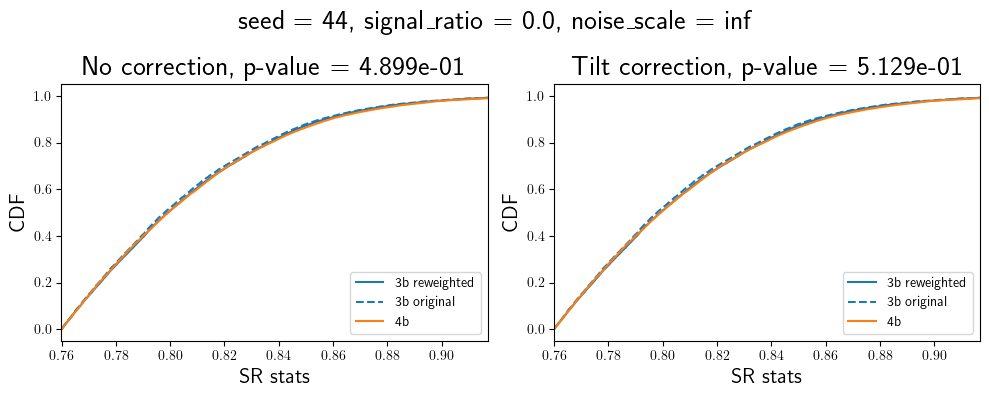

theta_max = 1.6648e+00
theta_min = -1.6648e+00
t = -0.5595979690551758, active_i = 8454, slopes[active_i] = -0.010269135236740112, i_left = 0, i_right = 27211
t = -0.5595979690551758, i_left = 8454, i_right = 27211, slopes[i_left] = -0.010269135236740112, slopes[i_right] = 0.0161609947681427, intercepts[i_left] = 0.001956014893949032, intercepts[i_right] = 0.008970017544925213
t = -0.26537904143333435, active_i = 26397, slopes[active_i] = 0.01610851287841797, i_left = 8454, i_right = 27211
t = -0.26537904143333435, i_left = 8454, i_right = 26397, slopes[i_left] = -0.010269135236740112, slopes[i_right] = 0.01610851287841797, intercepts[i_left] = 0.001956014893949032, intercepts[i_right] = 0.012836722657084465
t = -0.41249728202819824, active_i = 8454, slopes[active_i] = -0.010269135236740112, i_left = 8454, i_right = 26397
Found minimum at t = -0.41249728202819824, iteration 2
Threshold: 1.4170e-02
Correction mode: exponential
theta = -4.1250e-01
max_diff_tilted = 6.2910e-03
p-value_til

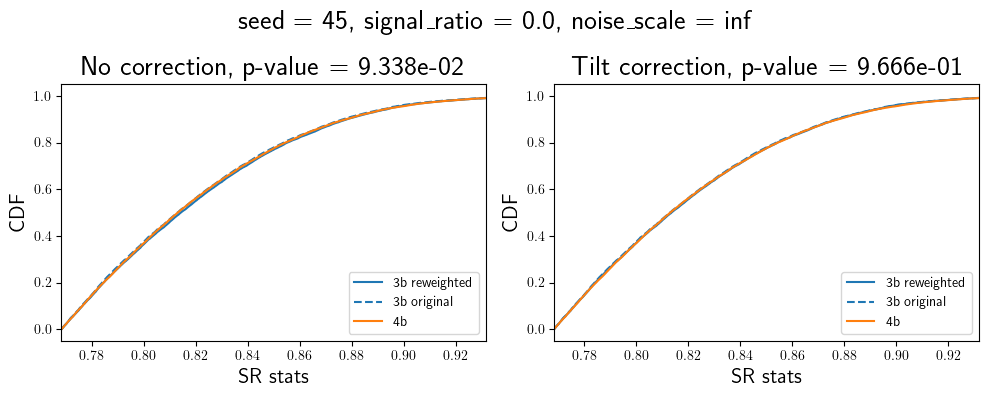

theta_max = 1.7393e+00
theta_min = -1.7393e+00
t = -0.567474901676178, active_i = 7085, slopes[active_i] = -0.01189468801021576, i_left = 0, i_right = 27531
t = -0.567474901676178, i_left = 7085, i_right = 27531, slopes[i_left] = -0.01189468801021576, slopes[i_right] = 0.015806764364242554, intercepts[i_left] = 0.004600399173796177, intercepts[i_right] = 0.008846865966916084
t = -0.15329401195049286, active_i = 26483, slopes[active_i] = 0.015724360942840576, i_left = 7085, i_right = 27531
t = -0.15329401195049286, i_left = 7085, i_right = 26483, slopes[i_left] = -0.01189468801021576, slopes[i_right] = 0.015724360942840576, intercepts[i_left] = 0.004600399173796177, intercepts[i_right] = 0.012434173375368118
t = -0.2836366295814514, active_i = 7085, slopes[active_i] = -0.01189468801021576, i_left = 7085, i_right = 26483
Found minimum at t = -0.2836366295814514, iteration 2
Threshold: 1.4082e-02
Correction mode: exponential
theta = -2.8364e-01
max_diff_tilted = 8.0626e-03
p-value_tilted 

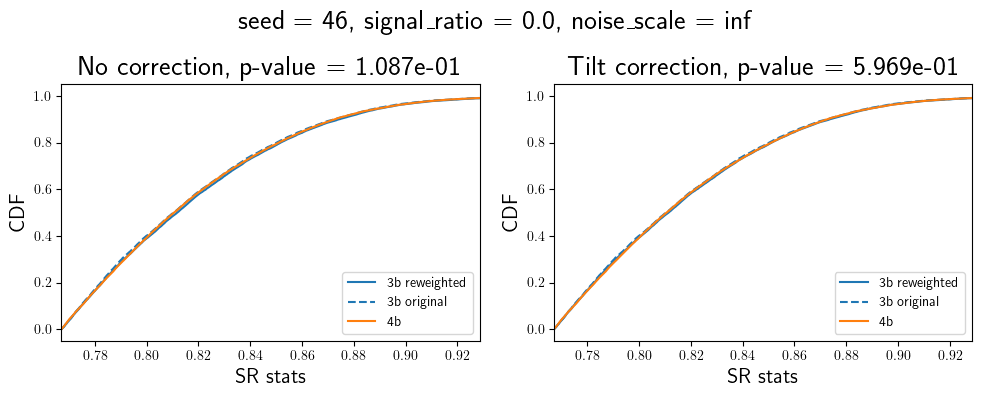

theta_max = 1.6848e+00
theta_min = -1.6848e+00
t = -0.0524587482213974, active_i = 19932, slopes[active_i] = 0.011373758316040039, i_left = 0, i_right = 27067
t = -0.0524587482213974, i_left = 0, i_right = 19932, slopes[i_left] = -0.015314638614654541, slopes[i_right] = 0.011373758316040039, intercepts[i_left] = -0.0008033867925405502, intercepts[i_right] = 0.00800471194088459
t = -0.3300347626209259, active_i = 11733, slopes[active_i] = -0.004197031259536743, i_left = 0, i_right = 19932
t = -0.3300347626209259, i_left = 11733, i_right = 19932, slopes[i_left] = -0.004197031259536743, slopes[i_right] = 0.011373758316040039, intercepts[i_left] = 0.004295132588595152, intercepts[i_right] = 0.00800471194088459
t = -0.23823964595794678, active_i = 11733, slopes[active_i] = -0.004197031259536743, i_left = 11733, i_right = 19932
Found minimum at t = -0.23823964595794678, iteration 2
Threshold: 1.4183e-02
Correction mode: exponential
theta = -2.3824e-01
max_diff_tilted = 5.3630e-03
p-value_til

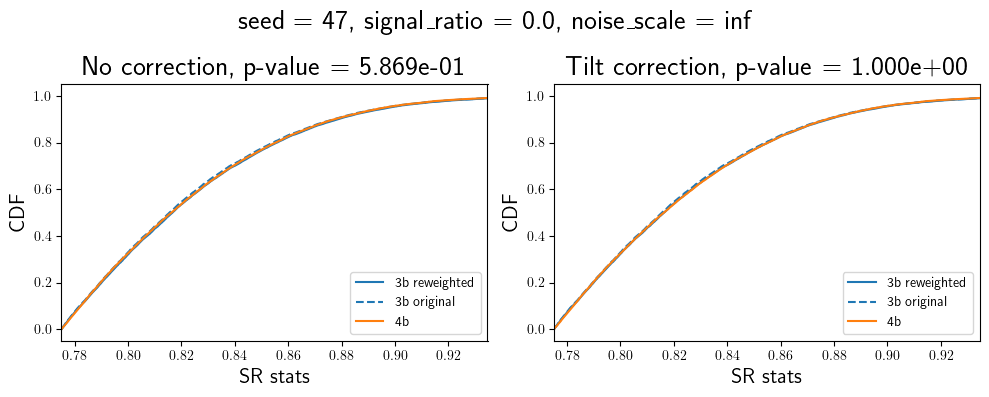

theta_max = 1.9034e+00
theta_min = -1.9034e+00
t = 0.7366805076599121, active_i = 16390, slopes[active_i] = 0.005422838032245636, i_left = 0, i_right = 27225
t = 0.7366805076599121, i_left = 0, i_right = 16390, slopes[i_left] = -0.013753175735473633, slopes[i_right] = 0.005422838032245636, intercepts[i_left] = 0.010136215016245842, intercepts[i_right] = 0.0035567069426178932
t = 0.3431113660335541, active_i = 122, slopes[active_i] = -0.013752251863479614, i_left = 0, i_right = 16390
t = 0.3431113660335541, i_left = 122, i_right = 16390, slopes[i_left] = -0.013752251863479614, slopes[i_right] = 0.005422838032245636, intercepts[i_left] = 0.010559854097664356, intercepts[i_right] = 0.0035567069426178932
t = 0.3652210831642151, active_i = 15285, slopes[active_i] = 0.003506101667881012, i_left = 122, i_right = 16390
t = 0.3652210831642151, i_left = 122, i_right = 15285, slopes[i_left] = -0.013752251863479614, slopes[i_right] = 0.003506101667881012, intercepts[i_left] = 0.010559854097664356,

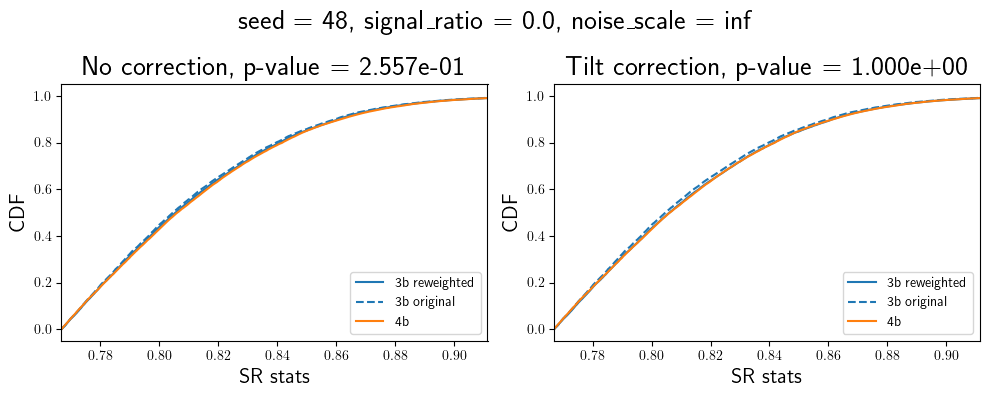

theta_max = 1.7964e+00
theta_min = -1.7964e+00
t = -0.432283490896225, active_i = 5403, slopes[active_i] = -0.012487202882766724, i_left = 0, i_right = 27361
t = -0.432283490896225, i_left = 5403, i_right = 27361, slopes[i_left] = -0.012487202882766724, slopes[i_right] = 0.014609873294830322, intercepts[i_left] = 0.007234395015984774, intercepts[i_right] = 0.006274094805121422
t = 0.03543925657868385, active_i = 26256, slopes[active_i] = 0.014520764350891113, i_left = 5403, i_right = 27361
t = 0.03543925657868385, i_left = 5403, i_right = 26256, slopes[i_left] = -0.012487202882766724, slopes[i_right] = 0.014520764350891113, intercepts[i_left] = 0.007234395015984774, intercepts[i_right] = 0.00736780883744359
t = -0.004939795006066561, active_i = 5403, slopes[active_i] = -0.012487202882766724, i_left = 5403, i_right = 26256
Found minimum at t = -0.004939795006066561, iteration 2
Threshold: 1.4133e-02
Correction mode: exponential
theta = -4.9398e-03
max_diff_tilted = 7.3757e-03
p-value_ti

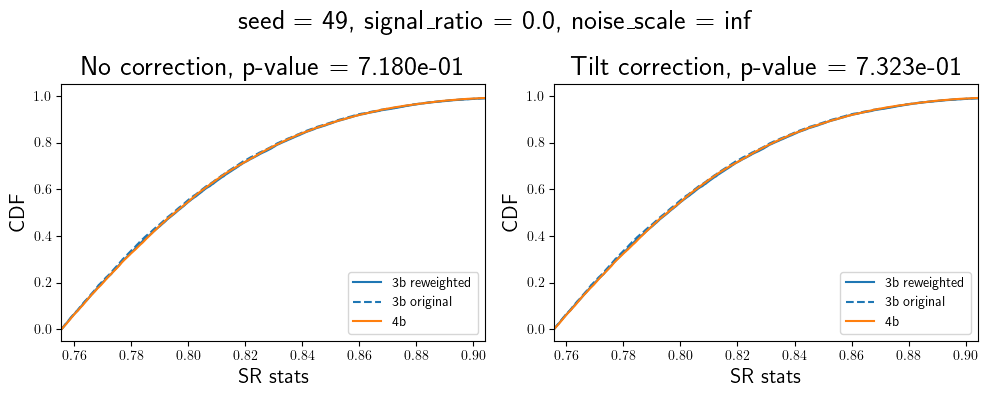

In [3]:
from plots import plot_cdf
from ks_test import max_cdf_diff, max_cdf_diff_tilted, tilt_correction_via_first_order_approximation
from ancillary_features import get_m4j

def c_alpha(alpha: float):
    return np.sqrt(np.log(2 / alpha) / 2)

signal_ratio = 0.0
signal_filename = "HH4b_picoAOD.h5"
SR_size = 0.05
sig_level = 0.05
noise_scale_ = np.inf
correction_mode = "exponential"
max_correction_ratio = 1.5

hashes, hparams = TrainingInfo.find({"experiment_name": "CR_fvt_training_ensemble_max", 
                                "dataset": lambda x: x["signal_ratio"] == signal_ratio,  
                                "signal_region": lambda x: x["4b_in_SR"] == SR_size}, 
                                    return_hparams=True)
metadata = TrainingInfo.load_metadata()
seeds = [metadata[hash_]["dataset"]["seed"] for hash_ in hashes]
hashes = [hashes[i] for i in np.argsort(seeds)]

max_diff_list = {"base": [], "CR": []}
tmp_list = {"base": [], "CR": []}
p_value_list = {"base": [], "CR": []}

for hash_ in hashes:
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    ensemble_mode = CR_fvt_tinfo.hparams["signal_region"]["ensemble_mode"]
    stats_type = CR_fvt_tinfo.hparams["signal_region"]["stats_type"]
    seed = CR_fvt_tinfo.hparams["dataset"]["seed"]
    signal_ratio = CR_fvt_tinfo.hparams["dataset"]["signal_ratio"]
    
    SR_stats_train, SR_stats_tst = compute_sr_stats(
        SR_stats_hashes,
        signal_filename,
        ensemble_mode,
        stats_type,
    )
    
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
        noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
    else:
        noise_scale = np.inf
        
    if noise_scale != noise_scale_:
        continue
    msamples = MotherSamples.load(smeared_tinfo.ms_hash)
    events_train = events_from_scdinfo(
        msamples.scdinfo[smeared_tinfo.ms_idx], FEATURES, signal_filename
    )
    events_tst = events_from_scdinfo(
        msamples.scdinfo[~smeared_tinfo.ms_idx], FEATURES, signal_filename
    )
    SR_cut, CR_cut = get_SR_CR_cut(
            SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"]
        )
    SR_idx = SR_stats_tst >= SR_cut
    
    SR_stats_tst_SR = SR_stats_tst[SR_idx]
    events_tst_SR = events_tst[SR_idx]
    
    fvt_scores_tst_SR = CR_fvt_tinfo.aux_info["fvt_scores_tst_SR"]
    reweights_tst_SR = fvt_scores_tst_SR / (1 - fvt_scores_tst_SR)
    rw_tst_SR = np.where(events_tst_SR.is_4b, events_tst_SR.weights, reweights_tst_SR * events_tst_SR.weights)
    is_4b_tst_SR = events_tst_SR.is_4b
    
    x_stats_SR = SR_stats_tst_SR
    
    max_diff = max_cdf_diff(x_stats_SR[is_4b_tst_SR], x_stats_SR[~is_4b_tst_SR], 
                            rw_tst_SR[is_4b_tst_SR], rw_tst_SR[~is_4b_tst_SR])
    
    
    n_SR_4b = np.sum(is_4b_tst_SR)
    n_SR_3b = np.sum(~is_4b_tst_SR)
    tmp = np.sqrt((n_SR_4b + n_SR_3b) / (n_SR_4b * n_SR_3b))
    
    theta_max = np.log(max_correction_ratio) / (np.max(x_stats_SR[~is_4b_tst_SR]) - np.min(x_stats_SR[~is_4b_tst_SR]))
    theta_min = -theta_max
    print(f"theta_max = {theta_max:.4e}")
    print(f"theta_min = {theta_min:.4e}")
    theta = tilt_correction_via_first_order_approximation(x_stats_SR[is_4b_tst_SR], x_stats_SR[~is_4b_tst_SR], 
                            rw_tst_SR[is_4b_tst_SR], rw_tst_SR[~is_4b_tst_SR], verbose=True)
    theta = np.clip(theta, theta_min, theta_max)
    corrections = np.exp(theta * x_stats_SR) if correction_mode == "exponential" else theta * x_stats_SR + 1
    print(f"Threshold: {c_alpha(sig_level) * tmp:.4e}")
    print(f"Correction mode: {correction_mode}")
    
    print(f"theta = {theta:.4e}")
    max_diff_tilted = max_cdf_diff_tilted(x_stats_SR[is_4b_tst_SR], x_stats_SR[~is_4b_tst_SR], 
                            rw_tst_SR[is_4b_tst_SR], rw_tst_SR[~is_4b_tst_SR], theta, mode=correction_mode)
    p_value_tilted = min(1.0, 2 * np.exp(-2 * (max_diff_tilted / tmp)**2))
    print(f"max_diff_tilted = {max_diff_tilted:.4e}")
    print(f"p-value_tilted = {p_value_tilted:.4e}")
    
    p_value = min(1.0, 2 * np.exp(-2 * (max_diff / tmp)**2))
    print("max CDF diff with CR fvt (1 ensemble): ", max_diff)
    print("p-value: ", p_value) 
    
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
    fig.suptitle(f"seed = {seed}, signal_ratio = {signal_ratio}, noise_scale = {noise_scale}")
    ax[0].set_title(f"No correction, p-value = {p_value:.3e}")
    plot_cdf(ax[0], x_stats_SR[~is_4b_tst_SR], rw_tst_SR[~is_4b_tst_SR], label="3b reweighted", 
             color=plt.cm.tab10(0))
    plot_cdf(ax[0], x_stats_SR[~is_4b_tst_SR], events_tst_SR.weights[~is_4b_tst_SR], label="3b original", 
             linestyle="--", color=plt.cm.tab10(0))
    plot_cdf(ax[0], x_stats_SR[is_4b_tst_SR], rw_tst_SR[is_4b_tst_SR], label="4b", 
             color=plt.cm.tab10(1))
    
    ax[1].set_title(f"Tilt correction, p-value = {p_value_tilted:.3e}")
    plot_cdf(ax[1], x_stats_SR[~is_4b_tst_SR], rw_tst_SR[~is_4b_tst_SR] * corrections[~is_4b_tst_SR], label="3b reweighted", 
             color=plt.cm.tab10(0))
    plot_cdf(ax[1], x_stats_SR[~is_4b_tst_SR], events_tst_SR.weights[~is_4b_tst_SR], label="3b original", 
             linestyle="--", color=plt.cm.tab10(0))
    plot_cdf(ax[1], x_stats_SR[is_4b_tst_SR], rw_tst_SR[is_4b_tst_SR], label="4b", 
             color=plt.cm.tab10(1))
    
    for a in ax:
        a.legend(loc="lower right")
        a.set_xlabel("SR stats")
        a.set_ylabel("CDF")
        xmin = np.min(x_stats_SR)
        xmax = np.quantile(x_stats_SR, 0.99)
        a.set_xlim(xmin, xmax)
    
    plt.tight_layout()
    plt.show()
    
    # max_diff_list["base"].append(max_diff_base)
    # max_diff_list["CR"].append(max_diff)
    # tmp_list["base"].append(tmp_base)
    # tmp_list["CR"].append(tmp)
    # p_value_list["base"].append(p_value_base)
    # p_value_list["CR"].append(p_value)

In [4]:
from tqdm import tqdm


def c_alpha(alpha: float):
    return np.sqrt(np.log(2 / alpha) / 2)

sig_level = 0.05

hashes, hparams = TrainingInfo.find({"experiment_name": "CR_fvt_training_ensemble_max"}, return_hparams=True)
metadata = TrainingInfo.load_metadata()
seeds = [metadata[hash_]["dataset"]["seed"] for hash_ in hashes]
hashes = [hashes[i] for i in np.argsort(seeds)]

results = []

for hash_ in tqdm(hashes):
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    seed = CR_fvt_tinfo.hparams["dataset"]["seed"]
    signal_ratio = CR_fvt_tinfo.hparams["dataset"]["signal_ratio"]
    SR_size = CR_fvt_tinfo.hparams["signal_region"]["4b_in_SR"]
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
        noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
    else:
        noise_scale = np.inf
        
    results.append({
        "seed": seed,
        "signal_ratio": signal_ratio,
        "SR_size": SR_size,
        "noise_scale": noise_scale,
        "max_cdf_diff": CR_fvt_tinfo.aux_info["max_cdf_diff"],
        "N_4b_SR": CR_fvt_tinfo.aux_info["N_4b_SR"],
        "N_3b_SR": CR_fvt_tinfo.aux_info["N_3b_SR"]
    })

100%|██████████| 5000/5000 [00:54<00:00, 92.58it/s] 


In [33]:
sig_level = 0.05
results_df = pd.DataFrame(results)
tmp = np.sqrt((results_df["N_4b_SR"] + results_df["N_3b_SR"]) / (results_df["N_4b_SR"] * results_df["N_3b_SR"]))
results_df["normalized_max_cdf_diff"] = results_df["max_cdf_diff"] / tmp
p_values = 2 * np.exp(-2 * (results_df["normalized_max_cdf_diff"])**2)
results_df["p_value"] = p_values
results_df["rejected"] = results_df["p_value"] < sig_level

# gbpy = results_df.groupby(["signal_ratio", "SR_size", "noise_scale"])

# for signal_ratio in [0.0, 0.0075, 0.01, 0.02]:
#     fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
#     fig.suptitle(f"signal_ratio = {signal_ratio}")
#     for SR_size, ax in zip([0.05, 0.1, 0.15, 0.2], axs.flatten()):
#         # print(f"SR size = {SR_size}")
#         values = results_df.loc[(results_df["signal_ratio"] == signal_ratio) & (results_df["SR_size"] == SR_size), 
#                                 "normalized_max_cdf_diff"]
#         bins = np.linspace(np.min(values), np.max(values), 20)
#         for noise_scale in [0.5, 1.0, 2.0, 3.0, np.inf]:
#             ax.hist(gbpy.get_group((signal_ratio, SR_size, noise_scale))["normalized_max_cdf_diff"], bins=bins, 
#                     histtype="step", label=f"noise_scale = {noise_scale}")
#             # print(f"Rejection rate for noise_scale={noise_scale}: {gbpy.get_group((signal_ratio, SR_size, noise_scale))['rejected'].mean()}")
#             # print(f"Mean max_cdf_diff for noise_scale={noise_scale}: {gbpy.get_group((signal_ratio, SR_size, noise_scale))['max_cdf_diff'].mean():.5f}")
#         ax.legend()
#         ax.set_xlabel("max CDF diff")
#         ax.set_ylabel("count")
#         ax.set_title(f"SR_size = {SR_size}")
#         # print("-" * 100)
#     plt.tight_layout()
#     plt.show()


In [32]:
from itertools import product

SR_size = 0.1
signal_ratio = 0.0075

for signal_ratio, SR_size in product([0.0, 0.0075, 0.01, 0.02], [0.05, 0.1, 0.15, 0.2]):
    print(f"signal_ratio = {signal_ratio}, SR_size = {SR_size}")
    display(results_df.groupby(["signal_ratio", "SR_size", "noise_scale"]).mean().loc[(signal_ratio, SR_size, )])
    print("-" * 100)

signal_ratio = 0.0, SR_size = 0.05


,seed,max_cdf_diff,N_4b_SR,N_3b_SR,normalized_max_cdf_diff,p_value,rejected
noise_scale,,,,,,,
0.5,24.5,0.009467,27201.82,24215.24,1.066741,0.352705,0.20
1.0,24.5,0.010208,27384.80,19935.48,1.095359,0.387017,0.20
2.0,24.5,0.009720,27730.44,15058.94,0.960641,0.486494,0.14
3.0,24.5,0.009063,28068.34,13807.14,0.871988,0.593686,0.10
inf,24.5,0.009873,28418.78,13546.04,0.945573,0.448388,0.06


----------------------------------------------------------------------------------------------------
signal_ratio = 0.0, SR_size = 0.1


,seed,max_cdf_diff,N_4b_SR,N_3b_SR,normalized_max_cdf_diff,p_value,rejected
noise_scale,,,,,,,
0.5,24.5,0.007763,54398.18,46368.06,1.223329,0.305017,0.34
1.0,24.5,0.007943,54792.56,38725.86,1.192859,0.289554,0.30
2.0,24.5,0.006791,55338.48,30045.10,0.947719,0.448970,0.08
3.0,24.5,0.008184,55850.06,28152.38,1.119673,0.350237,0.28
inf,24.5,0.008628,56435.26,27842.70,1.178131,0.313251,0.32


----------------------------------------------------------------------------------------------------
signal_ratio = 0.0, SR_size = 0.15


...

----------------------------------------------------------------------------------------------------
signal_ratio = 0.02, SR_size = 0.15


,seed,max_cdf_diff,N_4b_SR,N_3b_SR,normalized_max_cdf_diff,p_value,rejected
noise_scale,,,,,,,
0.5,24.5,0.062902,80568.88,60613.62,11.681453,2.143010e-02,0.98
1.0,24.5,0.078722,80767.60,52812.42,14.064532,1.606186e-106,1.00
2.0,24.5,0.083095,81902.08,43448.54,13.997743,1.204085e-130,1.00
3.0,24.5,0.083598,82630.30,40840.42,13.820644,5.615725e-142,1.00
inf,24.5,0.082867,83325.78,40268.68,13.653779,9.206800e-140,1.00


----------------------------------------------------------------------------------------------------
signal_ratio = 0.02, SR_size = 0.2


,seed,max_cdf_diff,N_4b_SR,N_3b_SR,normalized_max_cdf_diff,p_value,rejected
noise_scale,,,,,,,
0.5,24.5,0.052112,107755.46,82641.46,11.261369,1.150191e-09,1.0
1.0,24.5,0.062341,108052.50,72141.82,12.964507,3.639264e-82,1.0
2.0,24.5,0.064625,109376.22,59717.70,12.699452,1.873189e-106,1.0
3.0,24.5,0.064406,110225.18,56465.24,12.445449,2.197229e-111,1.0
inf,24.5,0.063675,111033.98,55862.92,12.275221,6.827953e-120,1.0


----------------------------------------------------------------------------------------------------


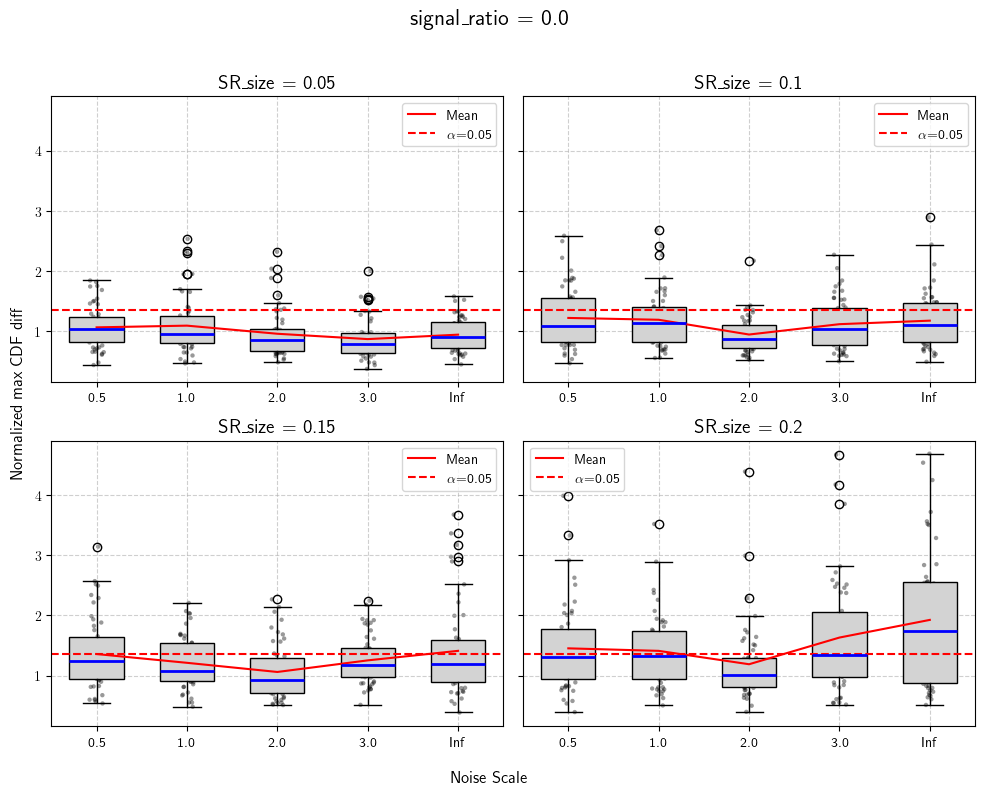

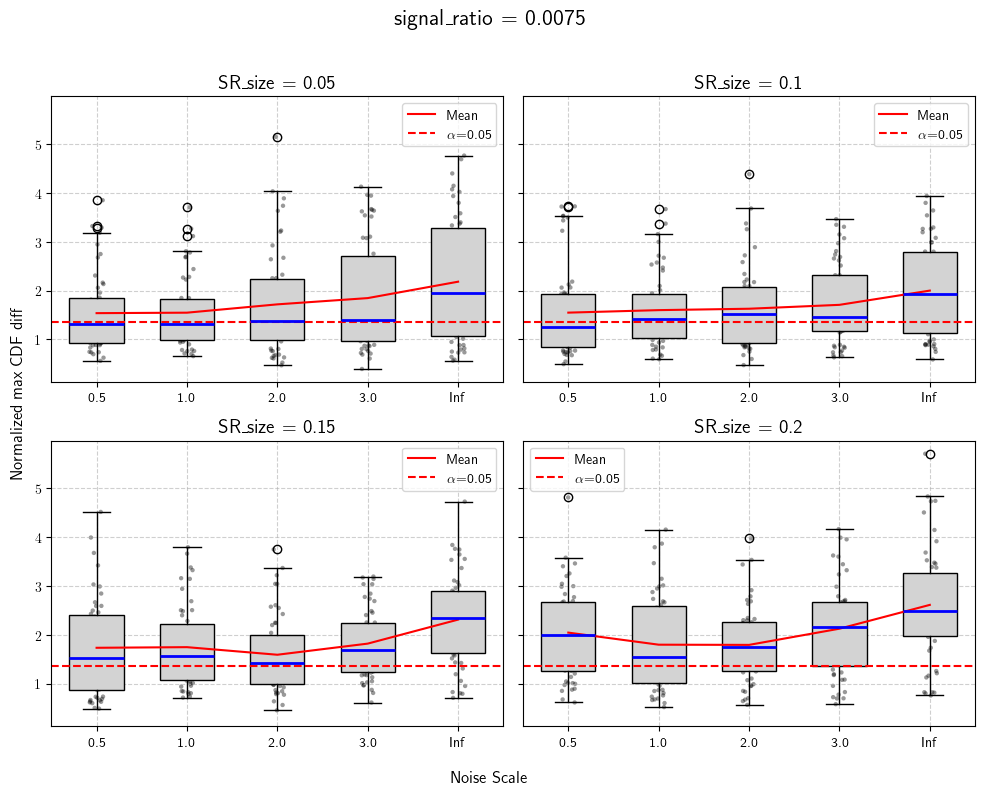

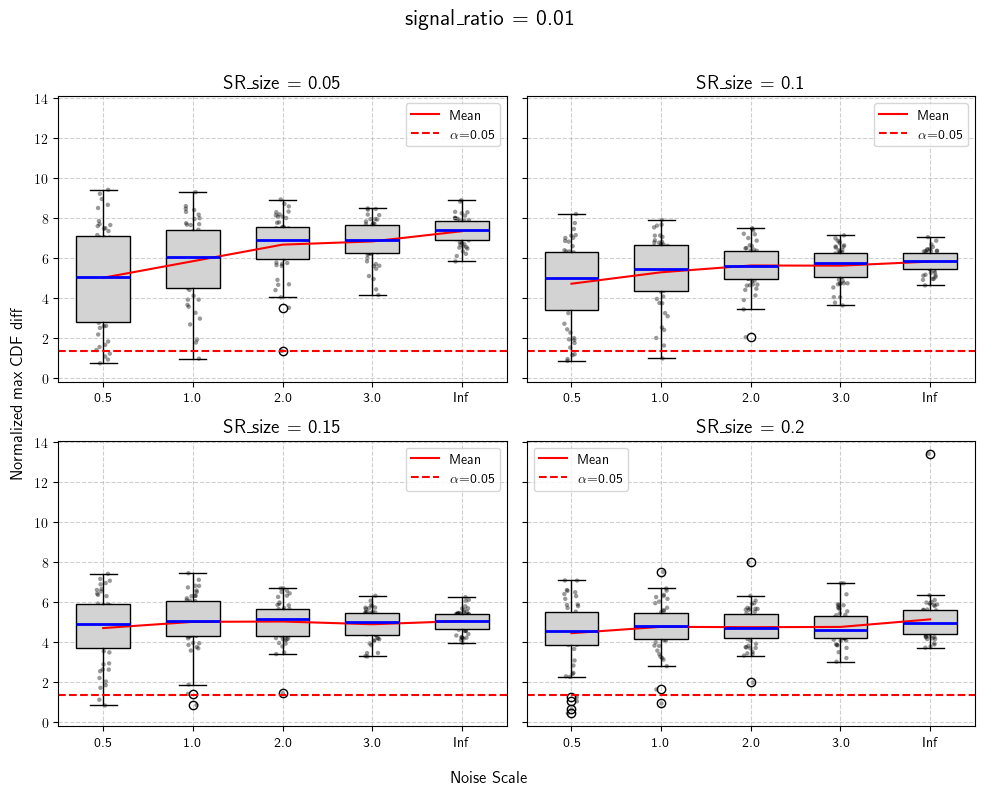

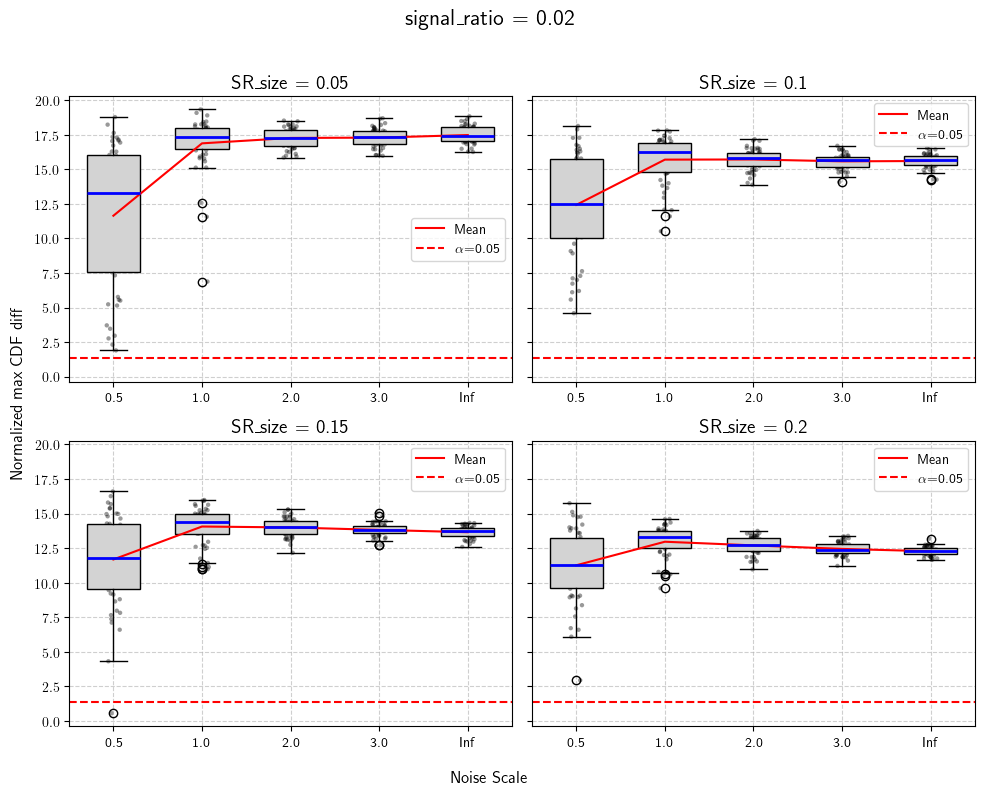

In [34]:
import numpy as np
import matplotlib.pyplot as plt

sig_level = 0.05

for signal_ratio in [0.0, 0.0075, 0.01, 0.02]:
    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), sharey=True)
    fig.suptitle(f"signal_ratio = {signal_ratio}", fontsize=16)
    fig.supxlabel("Noise Scale", fontsize=12)
    fig.supylabel("Normalized max CDF diff", fontsize=12)
    
    noise_scales = [0.5, 1.0, 2.0, 3.0, np.inf]
    x_positions = np.arange(len(noise_scales))
    x_labels = [str(ns) if np.isfinite(ns) else "Inf" for ns in noise_scales]
    
    for i, SR_size in enumerate([0.05, 0.1, 0.15, 0.2]):
        ax = axs.flatten()[i]
        
        # collect the data for each noise scale
        data = []
        for ns in noise_scales:
            group = results_df.loc[
                (results_df["signal_ratio"] == signal_ratio) &
                (results_df["SR_size"] == SR_size) &
                (results_df["noise_scale"] == ns),
                "normalized_max_cdf_diff"
            ]
            data.append(group.values)
        
        # draw boxplot
        bp = ax.boxplot(
            data,
            positions=x_positions,
            widths=0.6,
            notch=False,
            patch_artist=True,
            showfliers=True
        )
        
        # optional: style the boxes
        for box in bp['boxes']:
            box.set(facecolor='lightgray', edgecolor='black')
        for whisker in bp['whiskers']:
            whisker.set(color='black')
        for cap in bp['caps']:
            cap.set(color='black')
        for median in bp['medians']:
            median.set(color='blue', linewidth=2)
        # mean
        mean = np.mean(data, axis=1)
        ax.plot(x_positions, mean, color="purple", label="Mean")
        
        # … inside your SR_size loop, after bp = ax.boxplot(...)
        for xi, yvals in zip(x_positions, data):
            # generate jitters around xi (width ≈ 0.08)
            jitters = np.random.uniform(-0.08, 0.08, size=len(yvals))
            ax.scatter(xi + jitters, yvals,
                    alpha=0.4,         # semi-transparent
                    color='black',
                    s=10,              # marker size
                    edgecolors='none')
        
        # critical value line
        ax.axhline(y=c_alpha(sig_level), color="red", linestyle="--", label=rf"$\alpha$={sig_level}")
        
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels)
        ax.set_title(f"SR_size = {SR_size}", fontsize=14)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
